<a href="https://colab.research.google.com/github/ilmcconnell/HRSM/blob/ilm-wisconet/HRSM_MAPPING_ML_pipeline_multiplePoints_lgar_inputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Initial settings (authorize, connect GD, install packages, etc)

In [1]:
# @title get GEE authorization
import ee

# Trigger the authentication flow.
ee.Authenticate()
# Initialize the library.
ee.Initialize(project='run-hrsm')  # enter YOUR Google Earth Engine project name here.

In [2]:
# @title Connect to my Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# @title define drive path to write GEE parallel processing data

from pathlib import Path

gdrive_data_dir = Path('/content/gdrive/MyDrive/HRSM/')
gdrive_data_dir.mkdir(parents=True, exist_ok=True)
gdrive_data_dir.exists()

# @title create LGAR input files dir
lgar_output_dir = gdrive_data_dir / 'LGAR'
lgar_output_dir.mkdir(exist_ok=True, parents=True)
print(f"HRSM output dir: {gdrive_data_dir}\nLGAR output dir: {lgar_output_dir}")

HRSM output dir: /content/gdrive/MyDrive/HRSM
LGAR output dir: /content/gdrive/MyDrive/HRSM/LGAR


In [4]:
# !cp -r '/content/gdrive/My Drive/NIFA_Download/StartFolder/CDL_sites/' .

In [5]:
# @title Install necessary packages
!pip install tqdm
!pip install folium
!pip install geopandas
!pip install netCDF4
!pip install --upgrade xee
!pip install rasterio
!pip install ipywidgets
!pip install permetrics==2.0.0
!pip install mapie==1.1.0
!pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 722.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.1/187.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

In [6]:

# @title Import packages
from mapie.regression import SplitConformalRegressor, ConformalizedQuantileRegressor
import lightgbm as lgb

import folium
from folium import Figure
import geopandas as gpd
import json
import geemap
import numpy as np
from shapely.geometry import mapping
import pandas as pd
import netCDF4 as nc
import xarray
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import math
import time
import os
from datetime import datetime, timedelta
import joblib
import ipywidgets as widgets
from IPython.display import display
from permetrics import RegressionMetric
import osgeo.gdal as gdal
# import richdem as rd
# import pyflwdir
from osgeo import osr, gdalconst
from scipy.stats import rankdata

## Define study site: randomly choose points

This is a demo for ML runing pipeline, showing you how to run the trained ML models online for multiple points.

In this case study, we are going to generate stratified samples based on the irrigation calssification data and climate region data.

Irrigation maps:

Xie, Y., & Lark, T. J. (2021). Mapping annual irrigation from Landsat imagery and environmental variables across the conterminous United States. Remote Sensing of Environment, 260, 112445. https://doi.org/10.1016/j.rse.2021.112445

climate classification maps:

Beck, H. E., Zimmermann, N. E., McVicar, T. R., Vergopolan, N., Berg, A., & Wood, E. F. (2018). Present and future Köppen-Geiger climate classification maps at 1-km resolution. Scientific data, 5(1), 1-12. https://doi.org/10.1038/sdata.2018.214



In [7]:
# #@title Request irrigation data

# LANID2018_20 = ee.Image("users/xyhuwmir/LANID/update/LANID2018-2020")
# LANID2016 = ee.Image("projects/ee-scai62/assets/lanid2016")
# LANID2017 = ee.Image("projects/ee-scai62/assets/lanid2017")
# LANID2018 = LANID2018_20.select('irMap18')
# LANID2019 = LANID2018_20.select('irMap19')
# LANID2020 = LANID2018_20.select('irMap20')
# LANID_irrigation = (
#     LANID2018.eq(1)
#     .And(LANID2019.eq(1))
#     .And(LANID2020.eq(1))
#     .And(LANID2016.eq(1))
#     .And(LANID2017.eq(1))
# )

# LANID_binary = ee.Image.constant(2).where(LANID_irrigation.eq(1), 1)

In [8]:
# #@title Request climate data
# koppen_geiger_COUNS_1991_2020 = ee.Image("projects/ee-scai62/assets/koppen_geiger_COUNS_1991_2020")

# """
# 14: Cfa  Temperate, no dry season, hot summer  [200 255 80]
# 25: Dfa  Cold, no dry season, hot summer       [0 255 255]

# 4:  BWh  Arid, desert, hot                     [255 0 0]
# 5:  BWk  Arid, desert, cold                    [255 150 150]
# 6:  BSh  Arid, steppe, hot                     [245 165 0]
# 7:  BSk  Arid, steppe, cold                    [255 220 100]


# """

# koppen_reclassified = (
#     koppen_geiger_COUNS_1991_2020
#     .where(koppen_geiger_COUNS_1991_2020.eq(14), 1)
#     .where(
#         koppen_geiger_COUNS_1991_2020.eq(4)
#         .Or(koppen_geiger_COUNS_1991_2020.eq(5))
#         .Or(koppen_geiger_COUNS_1991_2020.eq(6))
#         .Or(koppen_geiger_COUNS_1991_2020.eq(7)),
#         2
#     )
#     .where(
#         koppen_geiger_COUNS_1991_2020.neq(14)
#         .And(koppen_geiger_COUNS_1991_2020.neq(4))
#         .And(koppen_geiger_COUNS_1991_2020.neq(5))
#         .And(koppen_geiger_COUNS_1991_2020.neq(6))
#         .And(koppen_geiger_COUNS_1991_2020.neq(7)),
#         0
#     )
# )
# # print(koppen_reclassified.getInfo())

In [9]:
# # @title Combine two classification layers
# final_image = LANID_binary.multiply(100).add(koppen_reclassified)
# band_names = final_image.bandNames()
# print(band_names.getInfo())

# valid_classes = ee.List([101, 102, 201, 202])

# masked_image = final_image.updateMask(
#     final_image.select('constant').remap(valid_classes, ee.List.repeat(1, valid_classes.size()))
# )

In [10]:
# @title The next cell is too slow, you can use this alternative: export csv file to google drive first, then load it here

# region = ee.FeatureCollection('projects/ee-scai62/assets/openET_states')
# scale = masked_image.projection().nominalScale()

# random_points = masked_image.stratifiedSample(
#     numPoints=200,
#     classBand='constant',
#     region=region.geometry(),
#     scale=scale,
#     geometries=True,
#     classValues=[101, 102, 201, 202],
#     classPoints=[50, 50, 50, 50],
#     seed=42
# )

# def add_coords(feature):
#     coords = feature.geometry().coordinates()
#     return feature.set({
#         'longitude': coords.get(0),
#         'latitude': coords.get(1)
#     })

# random_points = random_points.map(add_coords)


# # Export random_points to Google Drive as CSV
# export_task = ee.batch.Export.table.toDrive(
#     collection=random_points,
#     description='random_points_irrigation_climate',
#     # folder='GEE_exports',   # optional: folder name in your Drive
#     fileNamePrefix='random_points_irrigation_climate',
#     fileFormat='CSV'
# )

# # Start the export task
# export_task.start()

In [11]:
# # @title Generate random points within  classes
# import os

# if os.path.exists('random_points_irrigation_climate.csv'):
#   df_random_points = pd.read_csv('random_points_irrigation_climate.csv')
# else:
#   region = ee.FeatureCollection('projects/ee-scai62/assets/openET_states')

#   random_points = final_image.stratifiedSample(
#       numPoints=200,
#       classBand='constant',
#       region=region.geometry(),
#       scale=30,
#       geometries=True,
#       classValues=[101, 102, 201, 202],
#       classPoints=[50, 50, 50, 50],
#       seed=42
#   )

#   def add_coords(feature):
#       coords = feature.geometry().coordinates()
#       return feature.set({
#           'longitude': coords.get(0),
#           'latitude': coords.get(1)
#       })

#   random_points = random_points.map(add_coords)

#   fc_dict = random_points.getInfo()

#   df_random_points = pd.DataFrame([{
#       'latitude': f['properties']['latitude'],
#       'longitude': f['properties']['longitude'],
#       'cropland': f['properties']['cropland']
#   } for f in fc_dict['features']])

#   df_random_points['ID'] = df_random_points.index
#   df_random_points.to_csv('random_points_2016_2024.csv', index=False)

In [12]:
# Wisconet station lat,lons by wisconet station ID
coords = [
	{'latitude': 45.158901, 'longitude': -89.117798, 'ID': 47, 'constant': 1},
	{'latitude': 43.2966, 'longitude': -89.3843, 'ID': 7, 'constant': 1},
	{'latitude': 45.032001, 'longitude': -91.199997, 'ID': 45, 'constant': 1},
	{'latitude': 44.253799, 'longitude': -90.268997, 'ID': 36, 'constant': 1},
	{'latitude': 46.8395, 'longitude': -91.013603, 'ID': 74, 'constant': 1},
	{'latitude': 44.481499, 'longitude': -88.405899, 'ID': 31, 'constant': 1},
	{'latitude': 44.1852, 'longitude': -90.742798, 'ID': 19, 'constant': 1},
	{'latitude': 42.85215, 'longitude': -89.754089, 'ID': 82, 'constant': 1},
	{'latitude': 43.002998, 'longitude': -89.848503, 'ID': 65, 'constant': 1},
	{'latitude': 44.104, 'longitude': -88.051003, 'ID': 30, 'constant': 1},
	{'latitude': 42.570999, 'longitude': -88.044998, 'ID': 23, 'constant': 1},
	{'latitude': 43.838001, 'longitude': -89.030403, 'ID': 50, 'constant': 1},
	{'latitude': 45.285801, 'longitude': -92.321297, 'ID': 38, 'constant': 1},
	{'latitude': 42.898701, 'longitude': -88.737198, 'ID': 21, 'constant': 1},
	{'latitude': 45.522598, 'longitude': -88.923897, 'ID': 57, 'constant': 1},
	{'latitude': 45.16864, 'longitude': -87.997787, 'ID': 81, 'constant': 1},
	{'latitude': 44.026001, 'longitude': -90.255997, 'ID': 39, 'constant': 1},
	{'latitude': 42.649902, 'longitude': -90.289154, 'ID': 69, 'constant': 1},
	{'latitude': 44.327999, 'longitude': -87.966003, 'ID': 29, 'constant': 1},
	{'latitude': 44.627586, 'longitude': -91.939346, 'ID': 53, 'constant': 1},
	{'latitude': 45.0509, 'longitude': -87.259804, 'ID': 9, 'constant': 1},
	{'latitude': 44.609001, 'longitude': -91.0, 'ID': 42, 'constant': 1},
	{'latitude': 45.755638, 'longitude': -88.563454, 'ID': 80, 'constant': 1},
	{'latitude': 45.775398, 'longitude': -90.643097, 'ID': 72, 'constant': 1},
	{'latitude': 45.302132, 'longitude': -89.50415, 'ID': 79, 'constant': 1},
	{'latitude': 43.2981, 'longitude': -87.932098, 'ID': 32, 'constant': 1},
	{'latitude': 43.854332, 'longitude': -89.777641, 'ID': 70, 'constant': 1},
	{'latitude': 45.884548, 'longitude': -92.609062, 'ID': 78, 'constant': 1},
	{'latitude': 44.717999, 'longitude': -90.596603, 'ID': 20, 'constant': 1},
	{'latitude': 44.118801, 'longitude': -89.533302, 'ID': 1, 'constant': 1},
	{'latitude': 45.084621, 'longitude': -91.919167, 'ID': 76, 'constant': 1},
	{'latitude': 45.946201, 'longitude': -91.094704, 'ID': 73, 'constant': 1},
	{'latitude': 44.504025, 'longitude': -89.024918, 'ID': 55, 'constant': 1},
	{'latitude': 43.535099, 'longitude': -88.252701, 'ID': 33, 'constant': 1},
	{'latitude': 44.401798, 'longitude': -87.664597, 'ID': 15, 'constant': 1},
	{'latitude': 46.289001, 'longitude': -90.435997, 'ID': 41, 'constant': 1},
	{'latitude': 43.597, 'longitude': -90.625999, 'ID': 24, 'constant': 1},
	{'latitude': 42.830002, 'longitude': -90.7882, 'ID': 3, 'constant': 1},
	{'latitude': 43.451145, 'longitude': -88.977783, 'ID': 62, 'constant': 1},
	{'latitude': 44.556, 'longitude': -87.654297, 'ID': 8, 'constant': 1},
	{'latitude': 46.076, 'longitude': -89.838303, 'ID': 40, 'constant': 1},
	{'latitude': 46.632702, 'longitude': -91.681198, 'ID': 52, 'constant': 1},
	{'latitude': 44.7603, 'longitude': -90.097801, 'ID': 5, 'constant': 1},
	{'latitude': 44.030289, 'longitude': -90.934776, 'ID': 75, 'constant': 1},
	{'latitude': 42.887489, 'longitude': -90.231529, 'ID': 84, 'constant': 1},
	{'latitude': 44.401226, 'longitude': -91.559906, 'ID': 54, 'constant': 1},
	{'latitude': 43.853901, 'longitude': -89.283798, 'ID': 49, 'constant': 1},
	{'latitude': 44.789398, 'longitude': -87.4561, 'ID': 14, 'constant': 1},
	{'latitude': 42.976002, 'longitude': -88.120003, 'ID': 37, 'constant': 1},
	{'latitude': 44.59, 'longitude': -91.265999, 'ID': 43, 'constant': 1},
	{'latitude': 44.446098, 'longitude': -89.520699, 'ID': 34, 'constant': 1},
	{'latitude': 43.777199, 'longitude': -87.9515, 'ID': 60, 'constant': 1},
	{'latitude': 42.789001, 'longitude': -89.172997, 'ID': 26, 'constant': 1},
	{'latitude': 43.344799, 'longitude': -89.7117, 'ID': 18, 'constant': 1},
	{'latitude': 45.654598, 'longitude': -89.268204, 'ID': 2, 'constant': 1},
	{'latitude': 45.523331, 'longitude': -91.844292, 'ID': 77, 'constant': 1},
	{'latitude': 43.369999, 'longitude': -90.383003, 'ID': 27, 'constant': 1},
	{'latitude': 43.905602, 'longitude': -88.846703, 'ID': 28, 'constant': 1},
	{'latitude': 44.842499, 'longitude': -92.6129, 'ID': 71, 'constant': 1},
	{'latitude': 46.10701, 'longitude': -90.80793, 'ID': 68, 'constant': 1},
	{'latitude': 45.219101, 'longitude': -87.0662, 'ID': 11, 'constant': 1},
	{'latitude': 43.378399, 'longitude': -90.900002, 'ID': 48, 'constant': 1},
	{'latitude': 42.901299, 'longitude': -87.851196, 'ID': 51, 'constant': 1},
	{'latitude': 44.778999, 'longitude': -87.355598, 'ID': 10, 'constant': 1},
	{'latitude': 45.827, 'longitude': -91.861397, 'ID': 4, 'constant': 1},
	{'latitude': 44.880199, 'longitude': -87.329597, 'ID': 13, 'constant': 1},
	{'latitude': 44.999001, 'longitude': -88.342697, 'ID': 56, 'constant': 1},
	{'latitude': 43.84317, 'longitude': -88.370872, 'ID': 64, 'constant': 1},
	{'latitude': 44.004398, 'longitude': -87.8228, 'ID': 59, 'constant': 1},
	{'latitude': 43.025002, 'longitude': -89.536697, 'ID': 17, 'constant': 1},
	{'latitude': 42.527, 'longitude': -88.639999, 'ID': 25, 'constant': 1},
	{'latitude': 44.116699, 'longitude': -90.412102, 'ID': 35, 'constant': 1},
	{'latitude': 45.009998, 'longitude': -87.233498, 'ID': 12, 'constant': 1},
	{'latitude': 45.31929, 'longitude': -90.355469, 'ID': 67, 'constant': 1},
	{'latitude': 45.508121, 'longitude': -91.459503, 'ID': 83, 'constant': 1},
	{'latitude': 44.866001, 'longitude': -89.023552, 'ID': 58, 'constant': 1},
	{'latitude': 45.841, 'longitude': -89.667801, 'ID': 16, 'constant': 1},
	{'latitude': 44.943001, 'longitude': -92.287003, 'ID': 44, 'constant': 1},
	{'latitude': 42.7281, 'longitude': -88.028, 'ID': 46, 'constant': 1}
]
df_random_points = pd.DataFrame(coords)

In [13]:
wisconet_site_id_to_site_arr_idx = {k: v for v, k in enumerate(df_random_points['ID'].tolist())}
{k: wisconet_site_id_to_site_arr_idx[k] for k in list(wisconet_site_id_to_site_arr_idx.keys())[:5]}


{47: 0, 7: 1, 45: 2, 36: 3, 74: 4}

In [14]:
wisconet_id_to_station_code = {
  47: 'ANGO', 7: 'ALTN', 45: 'RTHR', 36: 'BBCK', 74: 'BYFD', 31: 'BLCR', 19: 'WCRS', 82: 'BCVL', 65: 'BGHM', 30: 'BRLN', 23: 'BSTL', 50: 'BKLN',
  38: 'CLLK', 21: 'COSP', 57: 'CNDN', 81: 'CVTZ', 39: 'CTLR', 69: 'DLTN', 29: 'DEPR', 53: 'DRND', 9: 'EGHA', 42: 'FRCD', 80: 'HDMK', 72: 'FLMB',
  79: 'GLSN', 32: 'GFTN', 70: 'GMSH', 78: 'CREX', 20: 'GNWD', 1: 'HNCK', 76: 'HRVR', 73: 'HNTR', 55: 'IOLA', 33: 'KSKM', 15: 'KWNE', 41: 'KNGT',
  24: 'LAFG', 3: 'LNCT', 62: 'LOLK', 8: 'LXBG', 40: 'MNWT', 52: 'MAPL', 5: 'MRFD', 75: 'MNDR', 84: 'MLPT', 54: 'MNTN', 49: 'MTLO', 14: 'NASE',
  37: 'NBLN', 43: 'OSEO', 34: 'FFEC', 60: 'PLYM', 26: 'GLCP', 18: 'DFRC', 2: 'RNLD', 77: 'RLKE', 27: 'RCHD', 28: 'RIPN', 71: 'UWRF', 68: 'SHGD',
  11: 'SIBA', 48: 'STAR', 51: 'SMKE', 10: 'SODO', 4: 'SPNR', 13: 'PARS', 56: 'SRNG', 64: 'TCDA', 59: 'VLDR', 17: 'OJNR', 25: 'DUDA', 35: 'WRNS',
  12: 'WJPT', 67: 'WBRO', 83: 'WKSN', 58: 'WTBG', 16: 'KEMP', 44: 'WDVL', 46: 'UGRV'
}

In [15]:
df_random_points

,latitude,longitude,ID,constant
0,45.158901,-89.117798,47,1
1,43.296600,-89.384300,7,1
2,45.032001,-91.199997,45,1
3,44.253799,-90.268997,36,1
4,46.839500,-91.013603,74,1
...,...,...,...,...
74,45.508121,-91.459503,83,1
75,44.866001,-89.023552,58,1
76,45.841000,-89.667801,16,1
77,44.943001,-92.287003,44,1


In [16]:
# @title Define feature collections
lons_sub = ee.List(df_random_points['longitude'].tolist())
lats_sub = ee.List(df_random_points['latitude'].tolist())
idnum_sub = ee.List(df_random_points['ID'].tolist())
constant_sub = ee.List(df_random_points['constant'].tolist())

# Combine all lists together
combined = lons_sub.zip(lats_sub).zip(idnum_sub).zip(constant_sub)

# Create FeatureCollection with geometry and properties
points = combined.map(lambda x:
    ee.Feature(
        ee.Geometry.Point([
            ee.List(ee.List(ee.List(x).get(0)).get(0)).get(0),  # lon
            ee.List(ee.List(ee.List(x).get(0)).get(0)).get(1)   # lat
        ]),
        {
            'id_num': ee.List(ee.List(x).get(0)).get(1),       # id_num
            'constant': ee.List(x).get(1)                      # constant
        }
    )
)

feature_collection = ee.FeatureCollection(points)

In [17]:
import io
from PIL import Image

# @title Visualize CDL image and random points
# Map = geemap.Map(center=[40, -100], zoom=4)
m = geemap.Map(center=(float(df_random_points.latitude.mean()), float(df_random_points.longitude.mean())), zoom=6)

# Add random_points layer
m.addLayer(feature_collection, {'color': 'red'}, 'Random Points')
# Map.addLayer(region)

# Map.addLayerControl()
# m  # hide js element display so notebook shows on GitHub OK.


## Read ee.images (constant images)

In [18]:
#@title read images to array

# Landcover
LC = ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD').filterDate('2016-01-01', '2018-01-01').select('landcover').first()
lc_proj = LC.projection()

#polaris
bd_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_0_5').first().rename('bd_0_5')
bd_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_5_15').first().rename('bd_5_15')
bd_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_15_30').first().rename('bd_15_30')
bd_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_30_60').first().rename('bd_30_60')
bd_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/bd_mean').filterMetadata('system:index', 'equals', 'bd_60_100').first().rename('bd_60_100')
bd_0_100 = bd_0_5.multiply(0.05).add(bd_5_15.multiply(0.1)).add(bd_15_30.multiply(0.15)).add(bd_30_60.multiply(0.3)).add(bd_60_100.multiply(0.4)).rename('bd_0_100')

clay_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_0_5').first().rename('clay_0_5')
clay_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_5_15').first().rename('clay_5_15')
clay_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_15_30').first().rename('clay_15_30')
clay_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_30_60').first().rename('clay_30_60')
clay_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/clay_mean').filterMetadata('system:index', 'equals', 'clay_60_100').first().rename('clay_60_100')
clay_0_100 = clay_0_5.multiply(0.05).add(clay_5_15.multiply(0.1)).add(clay_15_30.multiply(0.15)).add(clay_30_60.multiply(0.3)).add(clay_60_100.multiply(0.4)).rename('clay_0_100')

ksat_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_0_5').first().rename('ksat_0_5')
ksat_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_5_15').first().rename('ksat_5_15')
ksat_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_15_30').first().rename('ksat_15_30')
ksat_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_30_60').first().rename('ksat_30_60')
ksat_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/ksat_mean').filterMetadata('system:index', 'equals', 'ksat_60_100').first().rename('ksat_60_100')


sand_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_0_5').first().rename('sand_0_5')
sand_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_5_15').first().rename('sand_5_15')
sand_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_15_30').first().rename('sand_15_30')
sand_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_30_60').first().rename('sand_30_60')
sand_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/sand_mean').filterMetadata('system:index', 'equals', 'sand_60_100').first().rename('sand_60_100')
sand_0_100 = sand_0_5.multiply(0.05).add(sand_5_15.multiply(0.1)).add(sand_15_30.multiply(0.15)).add(sand_30_60.multiply(0.3)).add(sand_60_100.multiply(0.4)).rename('sand_0_100')

silt_0_5 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_0_5').first().rename('silt_0_5')
silt_5_15 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_5_15').first().rename('silt_5_15')
silt_15_30 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_15_30').first().rename('silt_15_30')
silt_30_60 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_30_60').first().rename('silt_30_60')
silt_60_100 = ee.ImageCollection('projects/sat-io/open-datasets/polaris/silt_mean').filterMetadata('system:index', 'equals', 'silt_60_100').first().rename('silt_60_100')
silt_0_100 = silt_0_5.multiply(0.05).add(silt_5_15.multiply(0.1)).add(silt_15_30.multiply(0.15)).add(silt_30_60.multiply(0.3)).add(silt_60_100.multiply(0.4)).rename('silt_0_100')

polaris = (
    bd_0_5
    .addBands(bd_0_100)
    .addBands(ksat_0_5).addBands(ksat_0_5)
    .addBands(clay_0_5).addBands(clay_0_100).addBands(clay_5_15).addBands(clay_15_30).addBands(clay_30_60).addBands(clay_60_100)
    .addBands(sand_0_5).addBands(sand_0_100).addBands(sand_5_15).addBands(sand_15_30).addBands(sand_30_60).addBands(sand_60_100)
    .addBands(silt_0_5).addBands(silt_0_100)
)

polaris_ksat = ksat_0_5.addBands(ksat_5_15).addBands(ksat_15_30).addBands(ksat_30_60).addBands(ksat_60_100)


dem_image = ee.Image('projects/ee-scai62/assets/COUNS_dem100m')
TWII_image = ee.Image('projects/ee-scai62/assets/CONUS_dem100m_TWII')
aspect_image = ee.Image('projects/ee-scai62/assets/CONUS_dem100m_aspect')
slopeDegree_image = ee.Image('projects/ee-scai62/assets/CONUS_dem100m_slopeDegree')

dem_image = dem_image.reproject(lc_proj)
TWII_image = TWII_image.reproject(lc_proj)
aspect_image = aspect_image.reproject(lc_proj)
slopeDegree_image = slopeDegree_image.reproject(lc_proj)

dem_image = dem_image.reproject(crs='EPSG:4326', scale=100)
TWII_image = TWII_image.reproject(crs='EPSG:4326', scale=100)
aspect_image = aspect_image.reproject(crs='EPSG:4326', scale=100)
slopeDegree_image = slopeDegree_image.reproject(crs='EPSG:4326', scale=100)

In [19]:
# @title extract values from constant images

dem_values = dem_image.sampleRegions(collection=feature_collection,scale=100)
elevation_arr = np.array(dem_values.aggregate_array('b1').getInfo())[:]
dem_idnum_arr = np.array(dem_values.aggregate_array('id_num').getInfo())[:]
TWII_values = TWII_image.sampleRegions(collection=feature_collection,scale=100)
TWII_arr = np.array(TWII_values.aggregate_array('b1').getInfo())[:]
aspect_values = aspect_image.sampleRegions(collection=feature_collection,scale=100)
aspect_arr = np.array(aspect_values.aggregate_array('b1').getInfo())[:]
slopeDegree_values = slopeDegree_image.sampleRegions(collection=feature_collection,scale=100)
slopeDegree_arr = np.array(slopeDegree_values.aggregate_array('b1').getInfo())[:]


# extract pixel values of LC using feature collection
LC_values = LC.sampleRegions(collection=feature_collection,scale=100)
landcover_arr = np.array(LC_values.aggregate_array('landcover').getInfo())[:]
LC_idnum_arr = np.array(LC_values.aggregate_array('id_num').getInfo())[:]

# extract pixel values of Polaris soil using feature collection
polaris_values = polaris.sampleRegions(collection=feature_collection,scale=100)
ml_sand_0_5 = np.array(polaris_values.aggregate_array('sand_0_5').getInfo())[:]

ml_sand_5_15 = np.array(polaris_values.aggregate_array('sand_5_15').getInfo())[:]
ml_sand_15_30 = np.array(polaris_values.aggregate_array('sand_15_30').getInfo())[:]
ml_sand_30_60 = np.array(polaris_values.aggregate_array('sand_30_60').getInfo())[:]
ml_sand_60_100 = np.array(polaris_values.aggregate_array('sand_60_100').getInfo())[:]

ml_sand_0_100 = np.array(polaris_values.aggregate_array('sand_0_100').getInfo())[:]
ml_clay_0_5 = np.array(polaris_values.aggregate_array('clay_0_5').getInfo())[:]


ml_clay_5_15 = np.array(polaris_values.aggregate_array('clay_5_15').getInfo())[:]
ml_clay_15_30 = np.array(polaris_values.aggregate_array('clay_15_30').getInfo())[:]
ml_clay_30_60 = np.array(polaris_values.aggregate_array('clay_30_60').getInfo())[:]
ml_clay_60_100 = np.array(polaris_values.aggregate_array('clay_60_100').getInfo())[:]

ml_clay_0_100 = np.array(polaris_values.aggregate_array('clay_0_100').getInfo())[:]
ml_bd_0_5 = np.array(polaris_values.aggregate_array('bd_0_5').getInfo())[:]
ml_bd_0_100 = np.array(polaris_values.aggregate_array('bd_0_100').getInfo())[:]
ml_ksat_0_5 = np.array(polaris_values.aggregate_array('ksat_0_5').getInfo())[:]
polaris_idnum_arr = np.array(polaris_values.aggregate_array('id_num').getInfo())[:]


# extract pixel values of Polaris soil using feature collection
polaris_ksat_values = polaris_ksat.sampleRegions(collection=feature_collection,scale=100)
#ksat
ksat_0_5_arr = np.array(polaris_ksat_values.aggregate_array('ksat_0_5').getInfo())[:]
ksat_5_15_arr = np.array(polaris_ksat_values.aggregate_array('ksat_5_15').getInfo())[:]
ksat_15_30_arr = np.array(polaris_ksat_values.aggregate_array('ksat_15_30').getInfo())[:]
ksat_30_60_arr = np.array(polaris_ksat_values.aggregate_array('ksat_30_60').getInfo())[:]
ksat_60_100_arr = np.array(polaris_ksat_values.aggregate_array('ksat_60_100').getInfo())[:]


In [20]:
#@title processing constant values
elevation_arr[elevation_arr<-1000] = np.nan

sinAsp_arr = np.sin(aspect_arr/180*np.pi)
sinAsp_arr[aspect_arr==-1] = 0
cosAsp_arr = np.cos(aspect_arr/180*np.pi)
cosAsp_arr[aspect_arr == -1] = 0

ml_ksat_0_5 = np.power(10, ml_ksat_0_5)  # convert to cm/hr
ksat_0_5_arr = np.power(10, ksat_0_5_arr)
ksat_5_15_arr = np.power(10, ksat_5_15_arr)
ksat_15_30_arr = np.power(10, ksat_15_30_arr)
ksat_30_60_arr = np.power(10, ksat_30_60_arr)
ksat_60_100_arr = np.power(10, ksat_60_100_arr)

d0_5 = 0.05
d5_15 = 0.10
d15_30 = 0.15
d30_60 = 0.30
d60_100 = 0.40
d_total = d0_5 + d5_15 + d15_30 + d30_60 + d60_100
ml_ksat_0_100 = d_total/(d0_5/ksat_0_5_arr +
                                d5_15/ksat_5_15_arr +
                                d15_30/ksat_15_30_arr +
                                d30_60/ksat_30_60_arr +
                                d60_100/ksat_60_100_arr)


In [21]:
print("max ksat at surface: ", ml_ksat_0_5.max())
print("min ksat at surface: ", ml_ksat_0_5.min())
print("max ksat at rootzone: ", ml_ksat_0_100.max())
print("min ksat at rootzone: ", ml_ksat_0_100.min())
print("max slope", slopeDegree_arr.max())
print("min slope", slopeDegree_arr.min())

max ksat at surface:  24.555552633321277
min ksat at surface:  0.9200064638472555
max ksat at rootzone:  25.33668213661158
min ksat at rootzone:  0.182132296092242
max slope 5.706702709197998
min slope 0.09557373076677322


In [22]:
#@title reorganize dataframe

# ml_sand_0_5 = np.array(polaris_values.aggregate_array('sand_0_5').getInfo())[:]

# ml_sand_5_15 = np.array(polaris_values.aggregate_array('sand_5_15').getInfo())[:]
# ml_sand_15_30 = np.array(polaris_values.aggregate_array('sand_15_30').getInfo())[:]
# ml_sand_30_60 = np.array(polaris_values.aggregate_array('sand_30_60').getInfo())[:]
# ml_sand_60_100 = np.array(polaris_values.aggregate_array('sand_60_100').getInfo())[:]

# ml_sand_0_100 = np.array(polaris_values.aggregate_array('sand_0_100').getInfo())[:]
# ml_clay_0_5 = np.array(polaris_values.aggregate_array('clay_0_5').getInfo())[:]


# ml_clay_5_15 = np.array(polaris_values.aggregate_array('clay_5_15').getInfo())[:]
# ml_clay_15_30 = np.array(polaris_values.aggregate_array('clay_15_30').getInfo())[:]
# ml_clay_30_60 = np.array(polaris_values.aggregate_array('clay_30_60').getInfo())[:]
# ml_clay_60_100 = np.array(polaris_values.aggregate_array('clay_60_100').getInfo())[:]

df_constant = pd.DataFrame({
    'ID': dem_idnum_arr,
    'elevation': elevation_arr,
    'sinAspect': sinAsp_arr,
    'cosAspect': cosAsp_arr,
    'slope': slopeDegree_arr,
    'landcover': landcover_arr,
    'sand_0_5[0-100]': ml_sand_0_5,
    'sand_5_15[0-100]': ml_sand_5_15,
    'sand_15_30[0-100]': ml_sand_15_30,
    'sand_30_60[0-100]': ml_sand_30_60,
    'sand_60_100[0-100]': ml_sand_60_100,
    'sand_0_100[0-100]': ml_sand_0_100,
    'clay_0_5[0-100]': ml_clay_0_5,
    'clay_5_15[0-100]': ml_clay_5_15,
    'clay_15_30[0-100]': ml_clay_15_30,
    'clay_30_60[0-100]': ml_clay_30_60,
    'clay_60_100[0-100]': ml_clay_60_100,
    'clay_0_100[0-100]': ml_clay_0_100,
    'ksat_0_5[cm/hr]': ml_ksat_0_5,
    'ksat_0_100[cm/hr]': ml_ksat_0_100,
    'bd_0_5[g/cm3]': ml_bd_0_5,
    'bd_0_100[g/cm3]': ml_bd_0_100})

merged_df = df_constant.merge(df_random_points, on='ID')


refer_id_arr = merged_df['ID'].to_numpy()
refer_lon_arr = merged_df['longitude'].to_numpy()
refer_lat_arr = merged_df['latitude'].to_numpy()

refer_id_idx_dict = {}
for i in range(len(refer_id_arr)):
    refer_id_idx_dict[refer_id_arr[i]] = i


len(refer_id_arr)
merged_df

,ID,elevation,sinAspect,cosAspect,slope,landcover,sand_0_5[0-100],sand_5_15[0-100],sand_15_30[0-100],sand_30_60[0-100],...,clay_30_60[0-100],clay_60_100[0-100],clay_0_100[0-100],ksat_0_5[cm/hr],ksat_0_100[cm/hr],bd_0_5[g/cm3],bd_0_100[g/cm3],latitude,longitude,constant
0,47,462.243469,-0.108537,-0.994092,0.334581,82,27.880409,27.842455,26.688103,28.749611,...,12.223457,11.681578,11.021242,1.905943,1.588020,1.435038,1.527205,45.158901,-89.117798,1
1,7,305.863586,0.634554,0.772879,0.581425,82,10.323525,9.729280,8.197285,6.878502,...,25.899673,25.376251,24.354092,2.533685,2.432207,1.280629,1.348935,43.296600,-89.384300,1
2,45,305.938507,-0.950172,0.311725,1.009012,81,18.488504,18.801865,18.743103,26.186327,...,14.835877,15.007371,13.784551,2.523956,1.299821,1.397751,1.576556,45.032001,-91.199997,1
3,36,295.531891,0.262039,0.965057,0.231921,82,50.344337,51.945992,52.973362,53.516983,...,20.721436,7.690073,16.623494,22.410416,9.444142,0.996209,1.226416,44.253799,-90.268997,1
4,74,316.996948,-0.102523,-0.994731,3.633019,81,30.217831,28.823399,23.828213,20.741543,...,44.775684,50.301743,40.625560,2.354330,0.185541,1.384654,1.437839,46.839500,-91.013603,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,83,459.490906,0.112354,-0.993668,3.528002,22,24.883106,25.086517,21.839348,34.341599,...,10.965169,10.404618,10.457774,3.176977,1.063253,1.335014,1.608369,45.508121,-91.459503,1
75,58,344.608643,-0.437673,0.899134,0.885890,82,74.548615,80.081619,86.019241,88.601341,...,3.034780,3.029453,3.160625,17.843483,21.781964,1.172451,1.443771,44.866001,-89.023552,1
76,16,487.196045,-0.996543,0.083073,0.829026,42,79.219482,79.192719,80.433167,87.340706,...,2.229533,1.330490,2.191342,11.623861,18.718399,1.231831,1.495018,45.841000,-89.667801,1
77,44,345.327728,-0.757471,-0.652868,2.018511,21,27.020752,27.303308,27.170017,30.273170,...,16.682127,14.517375,14.598082,2.615264,1.631585,1.319633,1.523108,44.943001,-92.287003,1


In [23]:
merged_df.columns

Index(['ID', 'elevation', 'sinAspect', 'cosAspect', 'slope', 'landcover',
       'sand_0_5[0-100]', 'sand_5_15[0-100]', 'sand_15_30[0-100]',
       'sand_30_60[0-100]', 'sand_60_100[0-100]', 'sand_0_100[0-100]',
       'clay_0_5[0-100]', 'clay_5_15[0-100]', 'clay_15_30[0-100]',
       'clay_30_60[0-100]', 'clay_60_100[0-100]', 'clay_0_100[0-100]',
       'ksat_0_5[cm/hr]', 'ksat_0_100[cm/hr]', 'bd_0_5[g/cm3]',
       'bd_0_100[g/cm3]', 'latitude', 'longitude', 'constant'],
      dtype='object')

In [24]:
#@title create LGAR soil properties from per site information

def extract_soil_properties(pm_sand_arr, pm_silt_arr, pm_clay_arr):
    # Hydrus properties
    theta_r_dict = {
        "sand": 0.045,
        "loamy_sand": 0.057,
        "sandy_loam": 0.065,
        "loam": 0.078,
        "silt": 0.034,
        "silt_loam": 0.067,
        "sandy_clay_loam": 0.100,
        "clay_loam": 0.095,
        "silty_clay_loam": 0.089,
        "sandy_clay": 0.100,
        "silty_clay": 0.070,
        "clay": 0.068
    }

    theta_e_dict = {
        "sand": 0.43,
        "loamy_sand": 0.41,
        "sandy_loam": 0.41,
        "loam": 0.43,
        "silt": 0.46,
        "silt_loam": 0.45,
        "sandy_clay_loam": 0.39,
        "clay_loam": 0.41,
        "silty_clay_loam": 0.43,
        "sandy_clay": 0.38,
        "silty_clay": 0.36,
        "clay": 0.38
    }

    alpha_dict = {  # cm^-1
        "sand": 0.145,
        "loamy_sand": 0.124,
        "sandy_loam": 0.075,
        "loam": 0.036,
        "silt": 0.016,
        "silt_loam": 0.020,
        "sandy_clay_loam": 0.059,
        "clay_loam": 0.019,
        "silty_clay_loam": 0.010,
        "sandy_clay": 0.027,
        "silty_clay": 0.005,
        "clay": 0.008
    }

    n_dict = {
        "sand": 2.68,
        "loamy_sand": 2.28,
        "sandy_loam": 1.89,
        "loam": 1.56,
        "silt": 1.37,
        "silt_loam": 1.41,
        "sandy_clay_loam": 1.48,
        "clay_loam": 1.31,
        "silty_clay_loam": 1.23,
        "sandy_clay": 1.23,
        "silty_clay": 1.09,
        "clay": 1.09
    }

    Ks_dict = {  # (cm/h)
        "sand": 29.7,
        "loamy_sand": 14.5917,
        "sandy_loam": 4.42083,
        "loam": 1.04,
        "silt": 0.25,
        "silt_loam": 0.45,
        "sandy_clay_loam": 1.31,
        "clay_loam": 0.26,
        "silty_clay_loam": 0.07,
        "sandy_clay": 0.12,
        "silty_clay": 0.02,
        "clay": 0.2
    }

    mask_sand = np.logical_and(pm_sand_arr > 85, (pm_silt_arr + 1.5 * pm_clay_arr) < 15)
    mask_loamy_sand = np.logical_and.reduce([
        pm_sand_arr >= 70,
        pm_sand_arr < 91,
        (pm_silt_arr + 1.5 * pm_clay_arr) >= 15,
        (pm_silt_arr + 2 * pm_clay_arr) < 30
    ])
    mask_sandy_loam = np.logical_or(
        np.logical_and.reduce([
            pm_clay_arr >= 7,
            pm_clay_arr < 20,
            pm_sand_arr > 52,
            (pm_silt_arr + 2 * pm_clay_arr) >= 30
        ]),
        np.logical_and.reduce([
            pm_clay_arr < 7,
            pm_silt_arr < 50,
            pm_sand_arr > 43
        ])
    )
    mask_loam = np.logical_and.reduce([
        pm_clay_arr >= 7,
        pm_clay_arr < 27,
        pm_silt_arr >= 28,
        pm_silt_arr < 50,
        pm_sand_arr <= 52
    ])
    mask_silt_loam = np.logical_or(
        np.logical_and(pm_silt_arr >= 50, np.logical_and(pm_clay_arr >= 12, pm_clay_arr < 27)),
        np.logical_and(pm_clay_arr < 12, np.logical_and(pm_silt_arr >= 50, pm_silt_arr < 80))
    )
    mask_silt = np.logical_and(pm_silt_arr >= 80, pm_clay_arr < 12)
    mask_sandy_clay_loam = np.logical_and.reduce([
        pm_clay_arr >= 20,
        pm_clay_arr < 35,
        pm_silt_arr < 28,
        pm_sand_arr > 45
    ])
    mask_clay_loam = np.logical_and.reduce([
        pm_clay_arr >= 27,
        pm_clay_arr < 40,
        pm_sand_arr > 20,
        pm_sand_arr < 46
    ])
    mask_silty_clay_loam = np.logical_and.reduce([
        pm_clay_arr >= 27,
        pm_clay_arr < 40,
        pm_sand_arr <= 20
    ])
    mask_sandy_clay = np.logical_and(pm_clay_arr >= 35, pm_sand_arr >= 45)
    mask_silty_clay = np.logical_and(pm_clay_arr >= 40, pm_silt_arr >= 40)
    mask_clay = np.logical_and.reduce([
        pm_clay_arr >= 40,
        pm_sand_arr <= 45,
        pm_silt_arr < 40
    ])

    soilMap  = {
        "sand": 1,
        "loamy_sand": 2,
        "sandy_loam": 3,
        "loam": 4,
        "silt": 5,
        "silt_loam": 6,
        "sandy_clay_loam": 7,
        "clay_loam": 8,
        "silty_clay_loam": 9,
        "sandy_clay": 10,
        "silty_clay": 11,
        "clay": 12
    }

    theta_r_arr = np.full(pm_sand_arr.shape, np.nan)
    theta_e_arr = np.full(pm_sand_arr.shape, np.nan)
    alpha_arr = np.full(pm_sand_arr.shape, np.nan)
    n_arr = np.full(pm_sand_arr.shape, np.nan)
    Ks_arr = np.full(pm_sand_arr.shape, np.nan)
    soilid_arr = np.full(pm_sand_arr.shape, np.nan)

    soilid_arr[mask_sand] = soilMap['sand']
    soilid_arr[mask_loamy_sand] = soilMap['loamy_sand']
    soilid_arr[mask_sandy_loam] = soilMap['sandy_loam']
    soilid_arr[mask_loam] = soilMap['loam']
    soilid_arr[mask_silt] = soilMap['silt']
    soilid_arr[mask_sandy_clay_loam] = soilMap['sandy_clay_loam']
    soilid_arr[mask_silt_loam] = soilMap['silt_loam']
    soilid_arr[mask_clay_loam] = soilMap['clay_loam']
    soilid_arr[mask_silty_clay_loam] = soilMap['silty_clay_loam']
    soilid_arr[mask_sandy_clay] = soilMap['sandy_clay']
    soilid_arr[mask_silty_clay] = soilMap['silty_clay']
    soilid_arr[mask_clay] = soilMap['clay']

    theta_r_arr[mask_sand] = theta_r_dict['sand']
    theta_r_arr[mask_loamy_sand] = theta_r_dict['loamy_sand']
    theta_r_arr[mask_sandy_loam] = theta_r_dict['sandy_loam']
    theta_r_arr[mask_loam] = theta_r_dict['loam']
    theta_r_arr[mask_silt] = theta_r_dict['silt']
    theta_r_arr[mask_sandy_clay_loam] = theta_r_dict['sandy_clay_loam']
    theta_r_arr[mask_silt_loam] = theta_r_dict['silt_loam']
    theta_r_arr[mask_clay_loam] = theta_r_dict['clay_loam']
    theta_r_arr[mask_silty_clay_loam] = theta_r_dict['silty_clay_loam']
    theta_r_arr[mask_sandy_clay] = theta_r_dict['sandy_clay']
    theta_r_arr[mask_silty_clay] = theta_r_dict['silty_clay']
    theta_r_arr[mask_clay] = theta_r_dict['clay']

    theta_e_arr[mask_sand] = theta_e_dict['sand']
    theta_e_arr[mask_loamy_sand] = theta_e_dict['loamy_sand']
    theta_e_arr[mask_sandy_loam] = theta_e_dict['sandy_loam']
    theta_e_arr[mask_loam] = theta_e_dict['loam']
    theta_e_arr[mask_silt] = theta_e_dict['silt']
    theta_e_arr[mask_sandy_clay_loam] = theta_e_dict['sandy_clay_loam']
    theta_e_arr[mask_silt_loam] = theta_e_dict['silt_loam']
    theta_e_arr[mask_clay_loam] = theta_e_dict['clay_loam']
    theta_e_arr[mask_silty_clay_loam] = theta_e_dict['silty_clay_loam']
    theta_e_arr[mask_sandy_clay] = theta_e_dict['sandy_clay']
    theta_e_arr[mask_silty_clay] = theta_e_dict['silty_clay']
    theta_e_arr[mask_clay] = theta_e_dict['clay']

    alpha_arr[mask_sand] = alpha_dict['sand']
    alpha_arr[mask_loamy_sand] = alpha_dict['loamy_sand']
    alpha_arr[mask_sandy_loam] = alpha_dict['sandy_loam']
    alpha_arr[mask_loam] = alpha_dict['loam']
    alpha_arr[mask_silt] = alpha_dict['silt']
    alpha_arr[mask_sandy_clay_loam] = alpha_dict['sandy_clay_loam']
    alpha_arr[mask_silt_loam] = alpha_dict['silt_loam']
    alpha_arr[mask_clay_loam] = alpha_dict['clay_loam']
    alpha_arr[mask_silty_clay_loam] = alpha_dict['silty_clay_loam']
    alpha_arr[mask_sandy_clay] = alpha_dict['sandy_clay']
    alpha_arr[mask_silty_clay] = alpha_dict['silty_clay']
    alpha_arr[mask_clay] = alpha_dict['clay']

    n_arr[mask_sand] = n_dict['sand']
    n_arr[mask_loamy_sand] = n_dict['loamy_sand']
    n_arr[mask_sandy_loam] = n_dict['sandy_loam']
    n_arr[mask_loam] = n_dict['loam']
    n_arr[mask_silt] = n_dict['silt']
    n_arr[mask_sandy_clay_loam] = n_dict['sandy_clay_loam']
    n_arr[mask_silt_loam] = n_dict['silt_loam']
    n_arr[mask_clay_loam] = n_dict['clay_loam']
    n_arr[mask_silty_clay_loam] = n_dict['silty_clay_loam']
    n_arr[mask_sandy_clay] = n_dict['sandy_clay']
    n_arr[mask_silty_clay] = n_dict['silty_clay']
    n_arr[mask_clay] = n_dict['clay']

    Ks_arr[mask_sand] = Ks_dict['sand']
    Ks_arr[mask_loamy_sand] = Ks_dict['loamy_sand']
    Ks_arr[mask_sandy_loam] = Ks_dict['sandy_loam']
    Ks_arr[mask_loam] = Ks_dict['loam']
    Ks_arr[mask_silt] = Ks_dict['silt']
    Ks_arr[mask_sandy_clay_loam] = Ks_dict['sandy_clay_loam']
    Ks_arr[mask_silt_loam] = Ks_dict['silt_loam']
    Ks_arr[mask_clay_loam] = Ks_dict['clay_loam']
    Ks_arr[mask_silty_clay_loam] = Ks_dict['silty_clay_loam']
    Ks_arr[mask_sandy_clay] = Ks_dict['sandy_clay']
    Ks_arr[mask_silty_clay] = Ks_dict['silty_clay']
    Ks_arr[mask_clay] = Ks_dict['clay']


    return soilid_arr, theta_r_arr, theta_e_arr, alpha_arr, n_arr, Ks_arr

# df_constant = pd.read_csv('../your_sites_info.csv')
['ID', 'elevation', 'sinAspect', 'cosAspect', 'slope', 'landcover',
       'sand_0_5[0-100]', 'sand_0_100[0-100]', 'clay_0_5[0-100]',
       'clay_0_100[0-100]', 'ksat_0_5[cm/hr]', 'ksat_0_100[cm/hr]',
       'bd_0_5[g/cm3]', 'bd_0_100[g/cm3]', 'latitude', 'longitude',
       'constant']
df_constant = merged_df
df_refer_id_arr = df_constant['ID'].to_numpy()
df_refer_sand_0_5_arr = df_constant['sand_0_5[0-100]'].to_numpy()
df_refer_sand_5_15_arr = df_constant['sand_5_15[0-100]'].to_numpy()
df_refer_sand_15_30_arr = df_constant['sand_15_30[0-100]'].to_numpy()
df_refer_sand_30_60_arr = df_constant['sand_30_60[0-100]'].to_numpy()
df_refer_sand_60_100_arr = df_constant['sand_60_100[0-100]'].to_numpy()
df_refer_clay_0_5_arr = df_constant['clay_0_5[0-100]'].to_numpy()
df_refer_clay_5_15_arr = df_constant['clay_5_15[0-100]'].to_numpy()
df_refer_clay_15_30_arr = df_constant['clay_15_30[0-100]'].to_numpy()
df_refer_clay_30_60_arr = df_constant['clay_30_60[0-100]'].to_numpy()
df_refer_clay_60_100_arr = df_constant['clay_60_100[0-100]'].to_numpy()

df_refer_silt_0_5_arr = 100 - df_refer_sand_0_5_arr - df_refer_clay_0_5_arr
df_refer_silt_5_15_arr = 100 - df_refer_sand_5_15_arr - df_refer_clay_5_15_arr
df_refer_silt_15_30_arr = 100 - df_refer_sand_15_30_arr - df_refer_clay_15_30_arr
df_refer_silt_30_60_arr = 100 - df_refer_sand_30_60_arr - df_refer_clay_30_60_arr
df_refer_silt_60_100_arr = 100 - df_refer_sand_60_100_arr - df_refer_clay_60_100_arr

soilid_0_5_arr, theta_r_0_5_arr, theta_e_0_5_arr, alpha_0_5_arr, n_0_5_arr, Ks_0_5_arr = extract_soil_properties(
    df_refer_sand_0_5_arr, df_refer_silt_0_5_arr, df_refer_clay_0_5_arr)
soilid_5_15_arr, theta_r_5_15_arr, theta_e_5_15_arr, alpha_5_15_arr, n_5_15_arr, Ks_5_15_arr = extract_soil_properties(
    df_refer_sand_5_15_arr, df_refer_silt_5_15_arr, df_refer_clay_5_15_arr)
soilid_15_30_arr, theta_r_15_30_arr, theta_e_15_30_arr, alpha_15_30_arr, n_15_30_arr, Ks_15_30_arr = extract_soil_properties(
    df_refer_sand_15_30_arr, df_refer_silt_15_30_arr, df_refer_clay_15_30_arr)
soilid_30_60_arr, theta_r_30_60_arr, theta_e_30_60_arr, alpha_30_60_arr, n_30_60_arr, Ks_30_60_arr = extract_soil_properties(
    df_refer_sand_30_60_arr, df_refer_silt_30_60_arr, df_refer_clay_30_60_arr)
soilid_60_100_arr, theta_r_60_100_arr, theta_e_60_100_arr, alpha_60_100_arr, n_60_100_arr, Ks_60_100_arr = extract_soil_properties(
    df_refer_sand_60_100_arr, df_refer_silt_60_100_arr, df_refer_clay_60_100_arr)

soilid_arr = np.array((soilid_0_5_arr, soilid_5_15_arr, soilid_15_30_arr,soilid_30_60_arr,soilid_60_100_arr))
theta_r_arr = np.array((theta_r_0_5_arr, theta_r_5_15_arr, theta_r_15_30_arr, theta_r_30_60_arr, theta_r_60_100_arr))
theta_e_arr = np.array((theta_e_0_5_arr, theta_e_5_15_arr, theta_e_15_30_arr, theta_e_30_60_arr, theta_e_60_100_arr))
alpha_arr = np.array((alpha_0_5_arr, alpha_5_15_arr, alpha_15_30_arr, alpha_30_60_arr, alpha_60_100_arr))
n_arr = np.array((n_0_5_arr, n_5_15_arr, n_15_30_arr, n_30_60_arr, n_60_100_arr))
Ks_arr = np.array((Ks_0_5_arr, Ks_5_15_arr, Ks_15_30_arr, Ks_30_60_arr, Ks_60_100_arr))
print(theta_r_arr.shape)
print(f'{np.count_nonzero(np.isnan(soilid_arr))},{np.count_nonzero(np.isnan(theta_r_arr))}, {np.count_nonzero(np.isnan(theta_e_arr))}, '
      f'{np.count_nonzero(np.isnan(alpha_arr))}, {np.count_nonzero(np.isnan(n_arr))}, '
      f'{np.count_nonzero(np.isnan(Ks_arr))}')

print(soilid_arr.shape)
soilid_arr_filename = lgar_output_dir / "soilid_arr.npy"
np.save(soilid_arr_filename, soilid_arr)
print(f"soilid_arr saved to {soilid_arr_filename}")

(5, 79)
0,0, 0, 0, 0, 0
(5, 79)
soilid_arr saved to /content/gdrive/MyDrive/HRSM/LGAR/soilid_arr.npy


## Define study area and period

In [25]:
# prompt: get the boundary of feature_collection
roi = feature_collection.geometry().bounds()

# start_date = '2016-01-01'  # original
# end_date = '2025-01-01'  # original
start_date = '2021-07-16' # mine
end_date = '2026-02-10'  # mine
# start_date = '2026-02-09' # test
# end_date = '2026-02-10'  # test



start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date

num_hours = int((end_datetime - start_datetime).total_seconds()/3600)
print(num_hours)

40080


## Get ee imagecollections

In [26]:
# @title Era5-land
start_date_era5 = (datetime.strptime(start_date, '%Y-%m-%d')- timedelta(hours=120+24)).strftime('%Y-%m-%d')

era5hour_short = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")\
                    .filterBounds(roi).filterDate(start_date_era5, end_date)\
                    .map(lambda img: img.addBands(
                        img.select('u_component_of_wind_10m').hypot(img.select('v_component_of_wind_10m')).rename('wind_10m')
                        )).select([
                            'temperature_2m',    # 2m air temperature, K
                            'dewpoint_temperature_2m',  # 2m dew point temperature, K
                            'wind_10m',  # wind speed, m/s
                            'surface_pressure',  # atmospheric surface pressure, Pa
                            ])


era5hour_mid = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterBounds(roi).filterDate(start_date_era5, end_date).select([
    'surface_solar_radiation_downwards_hourly',  # solar radiation, J
    'surface_thermal_radiation_downwards_hourly',  # thermal radiation, J
    ])


era5hour_long = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterBounds(roi).filterDate(start_date_era5, end_date).select([
    'total_evaporation_hourly',  # total evaporation, m
    'total_precipitation_hourly',   # precipitation, m
    ])


In [27]:
# @title HLSL30

###note: no scale factor for HLSL30 product.

def bitwiseExtract(img, fromBit, toBit):
  maskSize = ee.Number(1).add(toBit).subtract(fromBit)
  mask = ee.Number(1).leftShift(maskSize).subtract(1)
  return img.rightShift(fromBit).bitwiseAnd(mask)

# remove low quality data
def maskHLSL30(image):
  qcDay = image.select('Fmask')
  cloud = bitwiseExtract(qcDay, 1, 1).eq(0)
  cloudshadow = bitwiseExtract(qcDay, 3, 3).eq(0)
  snowice = bitwiseExtract(qcDay, 4, 4).eq(0)
  water = bitwiseExtract(qcDay, 5, 5).eq(0)
  aerosol = bitwiseExtract(qcDay, 6, 7).lte(2)
  mask = cloud.And(cloudshadow).And(snowice).And(water).And(aerosol)

  return    image.updateMask(mask).copyProperties(image, ['system:time_start'])


HLSL30 = ee.ImageCollection("NASA/HLS/HLSL30/v002").filterBounds(roi)\
    .filterDate(start_date, end_date).map(maskHLSL30) \
		.select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B9', 'B10', 'B11'])



# HLSL30_timestamps = HLSL30.aggregate_array('system:time_start')
# HLSL30_datetime_list = HLSL30_timestamps.map(
#     lambda t: ee.Date(t).format('YYYY-MM-dd HH')
# )
# HLSL30_datetime_list_py = HLSL30_datetime_list.getInfo()
# print(HLSL30_datetime_list_py[:10])  # preview first 10
# print("Total unique timestamps:", len(set(HLSL30_datetime_list_py)))

In [28]:
# @title Sentinel-2
# Sentinel-2 images

# old version
# def maskSentinel2(img):
#   cloudOpaqueBitMask = (1 << 10);
#   cloudCirrusMask = (1 << 11);
#   # Get the pixel QA band.
#   qa = img.select('QA60')
#   # Both flags should be set to zero, indicating clear conditions.
#   mask = qa.bitwiseAnd(cloudOpaqueBitMask).eq(0) \
#                 .And(qa.bitwiseAnd(cloudCirrusMask).eq(0))
#   return img.updateMask(mask).copyProperties(img, ['system:time_start'])                  #.multiply(0.0001).toFloat().copyProperties(img, ['mydate'])  # after applying updateMask(). all properties will be lost


def maskSentinel2(img):
  # Get the pixel QA band.
  scl = img.select('SCL')
  mask = scl.neq(8).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
  return img.updateMask(mask).copyProperties(img, ['system:time_start'])

# def add_date(img):
#   date_start = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd-HH')
#   return img.set('mydate', date_start)


Sentinel2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")\
            .filterDate(start_date, end_date).filterBounds(roi)\
            .map(maskSentinel2)\
            .select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12'])


# Sentinel2 = Sentinel2.map(add_date)

# Sentinel2_timestamps = Sentinel2.aggregate_array('system:time_start')
# Sentinel2_datetime_list = Sentinel2_timestamps.map(
#     lambda t: ee.Date(t).format('YYYY-MM-dd HH')
# )
# Sentinel2_datetime_list_py = Sentinel2_datetime_list.getInfo()
# print(Sentinel2_datetime_list_py[:10])  # preview first 10
# print("Total unique timestamps:", len(set(Sentinel2_datetime_list_py)))

In [29]:
# @title Sentinel-1

def preprocess_vv(image):
    vv_masked = image.updateMask(image.gt(-20).And(image.lt(-5)))
    vv_filtered = vv_masked.convolve(ee.Kernel.gaussian(3))
    return vv_filtered #.rename('VV').copyProperties(image, ['system:time_start'])

# Define preprocessing for VH
def preprocess_vh(image):
    vh_masked = image.updateMask(image.gt(-30).And(image.lt(-10)))
    vh_filtered = vh_masked.convolve(ee.Kernel.gaussian(3))
    return vh_filtered #.rename('VH').copyProperties(image, ['system:time_start'])


def merge_bands(image):
    vv = image.select('VV')
    vh = image.select('VH')
    angle = image.select('angle')

    vv_prep = preprocess_vv(vv)      # Apply mask + smoothing to VV
    vh_prep = preprocess_vh(vh)      # Apply mask + smoothing to VH

    merged = vv_prep.addBands(vh_prep).addBands(angle.rename('angle'))

    return merged.copyProperties(image, ['system:time_start'])

def to_float(image):
    all_bands = image.bandNames()
    return image.select(all_bands).float().copyProperties(image, ['system:time_start'])

Sentinel1 = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterDate(start_date, end_date)
    .filterBounds(roi)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    # .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .sort('SLC_Processing_start')
    .map(merge_bands).map(to_float)
)


# Sentinel1_timestamps = Sentinel1.aggregate_array('system:time_start')
# Sentinel1_datetime_list = Sentinel1_timestamps.map(
#     lambda t: ee.Date(t).format('YYYY-MM-dd HH')
# )
# Sentinel1_datetime_list_py = Sentinel1_datetime_list.getInfo()
# print(Sentinel1_datetime_list_py[:10])  # preview first 10
# print("Total unique timestamps:", len(set(Sentinel1_datetime_list_py)))

## Prepare Xy

## Extract data from image collection

The following code is to extract pixel values from imagecollections. Due to the request limiation of google earth engine (e.g., each time no more than 5000 observations), the feature collection is divdided into samll groups, and the study period is divided into small periods, and the parallel processing strategy is applied.

In [30]:
#@title Create year, doy, hour list: doy is an input for ML models, year, doy and hour provide time info for results
# start_datetime = datetime(2016, 1, 1, 0, 0, 0)
print(f"{start_datetime=}")
datetime_list = [start_datetime + timedelta(hours=i) for i in range(num_hours)]
doy_list = np.array([dt.timetuple().tm_yday for dt in datetime_list])
year_list = np.array([dt.year for dt in datetime_list])
hour_list = np.array([dt.hour for dt in datetime_list])
print(len(doy_list))

start_datetime=datetime.datetime(2021, 7, 16, 0, 0)
40080


In [31]:
# @title Define weights for ERA5 data
def make_weights(n):
    weights = 1.0 / np.arange(n, 0, -1)      # reversed sequence [n ... 1]
    weights = weights / weights.sum()        # normalize
    return weights, ee.List(weights.tolist())

# Short-term (24h)
short_term_weights, ee_short_term_weights = make_weights(24)
# print("Short-term weights:", short_term_weights)

# Mid-term (72h)
mid_term_weights, ee_mid_term_weights = make_weights(72)
# print("Mid-term weights:", mid_term_weights)

# Long-term (120h)
long_term_weights, ee_long_term_weights = make_weights(120)
# print("Long-term weights:", long_term_weights)

In [32]:
start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date

num_hours = int((end_datetime - start_datetime).total_seconds()/3600)
print(num_hours)

era5hour_arr = np.zeros((8, num_hours, len(refer_id_arr)))
sentinel1_arr = np.zeros((3, num_hours, len(refer_id_arr)))
HLSL30_arr = np.zeros((9, num_hours, len(refer_id_arr)))
Sentinel2_arr = np.zeros((10, num_hours, len(refer_id_arr)))

era5hour_arr[:] = np.nan
sentinel1_arr[:] = np.nan
HLSL30_arr[:] = np.nan
Sentinel2_arr[:] = np.nan

40080


In [33]:
start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date
current_datetime = start_datetime
tfirsts = []
tlasts = []
deltaa = 15 # hours
while current_datetime < end_datetime:
  tfirsts.append(current_datetime)
  tlasts.append( current_datetime + timedelta(hours=deltaa))
  current_datetime += timedelta(hours=deltaa)

print(len(tfirsts))

2672


In [34]:
len(tfirsts)

2672

In [35]:
#@title Load any pre-saved ERA5 data, check for nans, get missing tfirsts
from tqdm.auto import tqdm

era5hour_data_npy_file_name = 'era5hour_arr_irriClimate.npy'
era5_npy_path = gdrive_data_dir / era5hour_data_npy_file_name
if era5_npy_path.exists():
    print(f'loading {era5_npy_path.name}')
    era5hour_arr = np.load(era5_npy_path)

    # 1. Find indices of NaNs
    nan_indices = np.where(np.isnan(era5hour_arr))

    if nan_indices[0].size > 0:
        print(f"Found {nan_indices[0].size:,} NaN elements.")

        # 2. Extract unique time indices (axis 1)
        unique_nan_time_indices = np.unique(nan_indices[1])

        # 3. Calculate which 15-hour window (tfirst) each index belongs to
        # window_idx = floor(hours_since_start / deltaa)
        nan_window_indices = sorted(list(set(unique_nan_time_indices // deltaa)))

        # 4. Map back to actual tfirst datetimes
        # tfirsts = [tfirsts[i] for i in nan_window_indices if i < len(tfirsts)]
        tfirst_idxs = [i for i in nan_window_indices if i < len(tfirsts)]
        print(f"Need to re-run {len(tfirst_idxs)} time windows.")
        example_tfirsts_to_rerun = [tfirsts[tfirst_idx] for tfirst_idx in tfirst_idxs[:10]]
        print(f"Example tfirsts to re-run: {example_tfirsts_to_rerun}")
    else:
        print("No NaNs detected.")

else:
    print("File not found. Initializing fresh.")




loading era5hour_arr_irriClimate.npy
No NaNs detected.


In [36]:
# @title parallel processing  for ERA5-Land
import concurrent.futures
import traceback

def process_day(idx, feature_collection_crop):
  print(f'is running the {idx}th group')
  tfirst = tfirsts[idx]
  tlast = tlasts[idx]

  # ERA5 short
  era5hour_short_sub = era5hour_short.filterDate(tfirst, tlast)

  era5hour_sampled_points = era5hour_short_sub.map(lambda image: image.sampleRegions(
    collection=feature_collection_crop,
    scale=100  # Adjust scale as needed
  )).flatten()
  time.sleep(2) # Adjust the delay as needed
  points_list = era5hour_sampled_points.getInfo()['features']
  system_times = [point['id'] for point in points_list]
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print(len(df))
  df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
  df['time_idx'] = [int((datetime.strptime(systm[0:8] + systm[9:11], '%Y%m%d%H') - start_datetime).total_seconds()/3600) for systm in system_times]
  grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
  indices = grouped_df.index.tolist()
  for idx in indices:
    era5hour_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'temperature_2m']   # 2m air temperature, K
    era5hour_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'dewpoint_temperature_2m']   # 2m dew point temperature, K
    era5hour_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'wind_10m']   # wind speed, m/s
    era5hour_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'surface_pressure']  # atmospheric surface pressure, Pa


  # ERA5 middle
  era5hour_mid_sub = era5hour_mid.filterDate(tfirst, tlast)
  era5hour_sampled_points = era5hour_mid_sub.map(lambda image: image.sampleRegions(
    collection=feature_collection_crop,
    scale=100  # Adjust scale as needed
  )).flatten()
  time.sleep(2) # Adjust the delay as needed
  points_list = era5hour_sampled_points.getInfo()['features']
  system_times = [point['id'] for point in points_list]
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
  df['time_idx'] = [int((datetime.strptime(systm[0:8] + systm[9:11], '%Y%m%d%H') - start_datetime).total_seconds()/3600) for systm in system_times]
  grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
  indices = grouped_df.index.tolist()
  for idx in indices:
    era5hour_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'surface_solar_radiation_downwards_hourly']   # solar radiation, J
    era5hour_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'surface_thermal_radiation_downwards_hourly']   # thermal radiation, J


  # ERA5 long
  era5hour_long_sub = era5hour_long.filterDate(tfirst, tlast)
  era5hour_sampled_points = era5hour_long_sub.map(lambda image: image.sampleRegions(
    collection=feature_collection_crop,
    scale=100  # Adjust scale as needed
  )).flatten()
  time.sleep(2) # Adjust the delay as needed
  points_list = era5hour_sampled_points.getInfo()['features']
  system_times = [point['id'] for point in points_list]
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
  df['time_idx'] = [int((datetime.strptime(systm[0:8] + systm[9:11], '%Y%m%d%H') - start_datetime).total_seconds()/3600) for systm in system_times]
  grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
  indices = grouped_df.index.tolist()
  for idx in indices:
    era5hour_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'total_evaporation_hourly']   # total evaporation, m
    era5hour_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'total_precipitation_hourly']   # precipitation, m


  return idx


try:
  if not np.isnan(era5hour_arr).any():
    print(f'no nans in era5 data, skipping download')
    pass

  else:
    if not tfirst_idxs:
      print(f"Downloading entire data range")
      tfirst_idxs = range(len(tfirsts))
    else:
      print(f"Downloading {len(tfirst_idxs)} time windows to cover NaNs")

    # set max_workers=2 to be safe after hitting rate limits with 5
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
          results = list(
              executor.map(
                  lambda idx: process_day(idx, feature_collection),
                  tfirst_idxs
              )
          )
    print('done')

except Exception as main_error:
  print(f"🚨 Unexpected main error: {main_error}")
  traceback.print_exc()

finally:
  np.save(gdrive_data_dir / era5hour_data_npy_file_name, era5hour_arr)

  # time.sleep(10)
  # from google.colab import files
  # files.download('era5hour_arr_irriClimate.npy')


no nans in era5 data, skipping download


In [37]:
axis1 = np.where(np.isnan(era5hour_arr))[0]
axis2 = np.where(np.isnan(era5hour_arr))[1]
axis3 = np.where(np.isnan(era5hour_arr))[2]

axis1_unique = np.unique(axis1)
axis2_unique = np.unique(axis2)
axis3_unique = np.unique(axis3)

axis3_unique
# array([255, 353, 354, 355, 356, 374, 375, 384])

array([], dtype=int64)

In [38]:
#@title era5 data quality check
import math

# np.isnan(era5hour_arr).sum() == np.count_nonzero(np.isnan(era5hour_arr))  # True
# era5_nan_count = np.count_nonzero(np.isnan(era5hour_arr))
era5_nan_count = np.isnan(era5hour_arr).sum()
print(f'{era5_nan_count=:,}')
print(f"{era5hour_arr.shape=}")
era5_feat_ct, timepoint_ct, location_ct = era5hour_arr.shape
print(f"dims: era5 features: {era5_feat_ct}, times (h): {timepoint_ct}, locations: {location_ct}")

era5_total_elements = math.prod(era5hour_arr.shape)
print(f'{era5_total_elements=:,}')
print(f"nan %: {era5_nan_count/era5_total_elements * 100:.4f}")

nan_indices = np.argwhere(np.isnan(era5hour_arr))
#print('third dimension: ', set(nan_indices[:, 2]))v
print('locations with NaNs: ', set(nan_indices[:, 2]))

era5_nan_count=0
era5hour_arr.shape=(8, 40080, 79)
dims: era5 features: 8, times (h): 40080, locations: 79
era5_total_elements=25,330,560
nan %: 0.0000
locations with NaNs:  set()


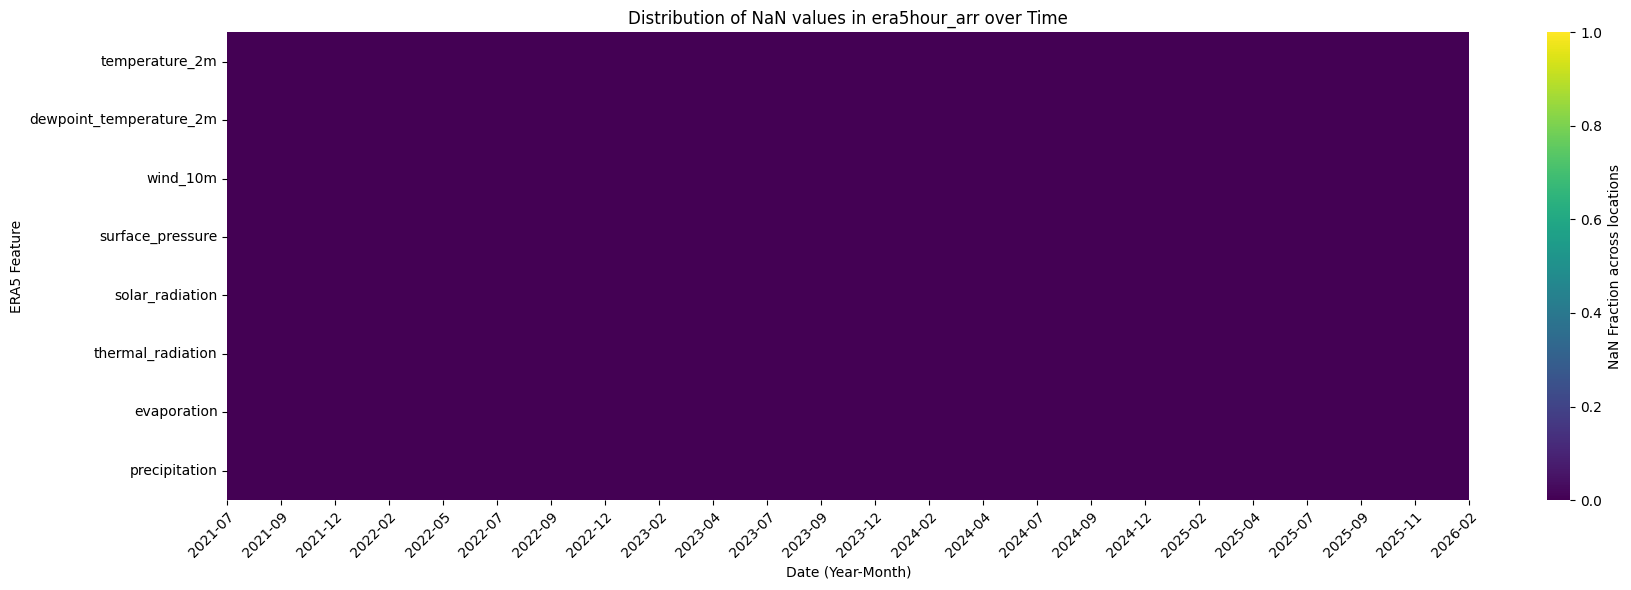

In [39]:
#@title plot ERA5 Nan Fraction (mean across sites) for each ERA5 var and timepoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize NaN distribution over time across features (averaged over all locations)
# era5hour_arr shape: (features=8, time=40080, locations=79)
era5_nan_map = np.isnan(era5hour_arr).mean(axis=2)  # Shape (8, 40080)

feature_names = [
    'temperature_2m', 'dewpoint_temperature_2m', 'wind_10m', 'surface_pressure',
    'solar_radiation', 'thermal_radiation', 'evaporation', 'precipitation'
]

plt.figure(figsize=(18, 6))
ax = sns.heatmap(
    era5_nan_map, vmin=0, vmax=1, cmap='viridis',
    cbar_kws={'label': 'NaN Fraction across locations'},
)

# Calculate tick positions for dates
num_ticks = 24
tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right', rotation_mode='anchor')
plt.title('Distribution of NaN values in era5hour_arr over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('ERA5 Feature')
plt.yticks(ticks=np.arange(8)+0.5, labels=feature_names, rotation=0)
plt.tight_layout()
plt.show()

In [40]:
era5hour_arr.shape

(8, 40080, 79)

In [41]:
#@title save ERA5 hourly data as netCDF
import xarray as xr

era5_netcdf_filename = (gdrive_data_dir / era5hour_data_npy_file_name).with_suffix(".nc")

if not era5_netcdf_filename.exists():
  print(f'saving {era5_netcdf_filename}')
  era5_ds = xr.Dataset(
      data_vars={
        'temperature_2m': (['time', 'location'], era5hour_arr[0]),
        'dewpoint_temperature_2m': (['time', 'location'], era5hour_arr[1]),
        'wind_10m': (['time', 'location'], era5hour_arr[2]),
        'surface_pressure': (['time', 'location'], era5hour_arr[3]),
        'solar_radiation': (['time', 'location'], era5hour_arr[4]),
        'thermal_radiation': (['time', 'location'], era5hour_arr[5]),
        'evaporation': (['time', 'location'], era5hour_arr[6]),
        'precipitation': (['time', 'location'], era5hour_arr[7]),
      },
      coords={
        'time': datetime_list,
        'location': refer_id_arr,
      },
  )
  era5_ds.to_netcdf(era5_netcdf_filename)
  era5_ds.close()

else:
  print(f"era5 netCDF exists: {era5_netcdf_filename}")

print(f'loading {era5_netcdf_filename}')
era5_ds = xr.open_dataset(era5_netcdf_filename)


era5 netCDF exists: /content/gdrive/MyDrive/HRSM/era5hour_arr_irriClimate.nc
loading /content/gdrive/MyDrive/HRSM/era5hour_arr_irriClimate.nc


In [42]:
era5_ds

<xarray.Dataset> Size: 203MB
Dimensions:                  (time: 40080, location: 79)
Coordinates:
  * time                     (time) datetime64[ns] 321kB 2021-07-16 ... 2026-...
  * location                 (location) int64 632B 47 7 45 36 74 ... 58 16 44 46
Data variables:
    temperature_2m           (time, location) float64 25MB ...
    dewpoint_temperature_2m  (time, location) float64 25MB ...
    wind_10m                 (time, location) float64 25MB ...
    surface_pressure         (time, location) float64 25MB ...
    solar_radiation          (time, location) float64 25MB ...
    thermal_radiation        (time, location) float64 25MB ...
    evaporation              (time, location) float64 25MB ...
    precipitation            (time, location) float64 25MB ...

In [43]:
#@title calculate and save PET and Total Precip forcing LGAR data (.npy)

import pandas as pd

alpha = 1.3
rho_w = 1000

def e_s(T):
    return(611*np.exp((17.27*T)/(273.3+T)))

def delta(T):
    return((4098*e_s(T))/((273.3+T)**2))

def l_v(T):
    return(2500 - 2.36*T)

def gamma(T):
    return(66.8)
    #return(1.005*101325*pressure/(0.622*l_v(T)))
    #note that gamma is often given as the constant 66.8 pascals/decree C. the other version, commented out, takes temperature and pressure (input pressure in atm, and temp as deg C) as inputs.

def E_r(R_n, T):
    return(R_n/(l_v(T)*1000*rho_w))

def E_PT(R_n, T):
    return(E_r(R_n, T)*alpha*delta(T)/(delta(T)+gamma(T)))

def get_nan_row_indices(arr, col_idx):
    """
    Given a 2D NumPy array and a column index,
    return the row indices where the selected column has NaN values.

    Parameters:
    - arr: 2D numpy array
    - col_idx: integer, index of the column to check

    Returns:
    - 1D numpy array of row indices where values are NaN
    """
    col_data = arr[:, col_idx]
    nan_rows = np.where(np.isnan(col_data))[0]
    return nan_rows



def fill_pet_gaps(arr):
    """
    Fill NaN gaps in PET data for each site (column) with linear interpolation,
    skipping sites that have the entire time series missing.

    Parameters:
        arr (2D np.ndarray): PET array (time, sites)

    Returns:
        np.ndarray: Filled PET array
    """
    arr_filled = arr.copy()
    n_sites = arr.shape[1]

    for site in range(n_sites):
        col = arr[:, site]

        # Skip sites that are completely NaN
        if np.all(np.isnan(col)):
            print(f"Skipping site {site} (fully missing)")
            continue

        # Interpolate missing values in both directions
        s = pd.Series(col)
        arr_filled[:, site] = s.interpolate(method='linear', limit_direction='both').values

    return arr_filled

pet_arr_filename = lgar_output_dir / "PET_arr.npy"
prec_arr_filename = lgar_output_dir / "Prec_arr.npy"

if not pet_arr_filename.exists() and not prec_arr_filename.exists():
  # ear5_id_arr = np.array(era5_ds['ID'][:])
  ear5_t2m_arr = np.array(era5_ds['temperature_2m'][:]).T
  ear5_ssr_arr = np.array(era5_ds['solar_radiation'][:]).T
  ear5_tp_arr = np.array(era5_ds['precipitation'][:]).T
  era5_ds.close()

  ear5_tp_arr = ear5_tp_arr * 1000  # hourly precipitation, m to mm
  ear5_tp_arr[ear5_tp_arr < 1e-2] = 0
  print(f"{ear5_tp_arr.shape=}")

  nan_columns = np.any(np.isnan(ear5_tp_arr), axis=0)
  nan_col_indices = np.where(nan_columns)[0]
  print("ear5_tp_arr Columns containing NaN:", nan_col_indices)
  print("ear5_tp_arr, number of nan values:", np.count_nonzero(np.isnan(ear5_tp_arr)))

  ear5_ssr_arr = ear5_ssr_arr/3600  # J to W/m2
  ear5_t2m_arr = ear5_t2m_arr - 273.15 # K to deg C

  ear5_PET_arr = 3.6e6*E_PT(ear5_ssr_arr, ear5_t2m_arr)
  ear5_PET_arr[ear5_PET_arr < 1e-6] = 0
  print(ear5_PET_arr.shape)

  ear5_PET_arr = fill_pet_gaps(ear5_PET_arr)

  nan_columns = np.any(np.isnan(ear5_PET_arr), axis=0)
  nan_col_indices = np.where(nan_columns)[0]
  print("ear5_PET_arr Columns containing NaN:", nan_col_indices)
  print("ear5_PET_arr, number of nan values:", np.count_nonzero(np.isnan(ear5_PET_arr)))

  np.save(pet_arr_filename, ear5_PET_arr)  # (79, 40080)
  np.save(prec_arr_filename, ear5_tp_arr)  # (79, 40080)

else:
  print(f"One or both of PET and Prec forcing data npys exist:\n{pet_arr_filename} exists:{pet_arr_filename.exists()}\n{prec_arr_filename} exists:{prec_arr_filename.exists()}")
  # ear5_PET_arr = np.load(pet_arr_filename)
  # ear5_tp_arr = np.load(prec_arr_filename)




One or both of PET and Prec forcing data npys exist:
/content/gdrive/MyDrive/HRSM/LGAR/PET_arr.npy exists:True
/content/gdrive/MyDrive/HRSM/LGAR/Prec_arr.npy exists:True


In [44]:
#@title Write ID file to disk for LGAR

id_arr_filename = lgar_output_dir / "referIDArr.npy"
if not id_arr_filename.exists():
  referIDArr = era5_ds.location.data
  np.save(id_arr_filename, referIDArr)

else:
  print(f"referIDArr.npy exists: {id_arr_filename}")



referIDArr.npy exists: /content/gdrive/MyDrive/HRSM/LGAR/referIDArr.npy


In [45]:
#@title set up to download Sentinel 1/2/HLSL30 data
start_datetime = datetime.strptime(start_date, '%Y-%m-%d')
end_datetime = datetime.strptime(end_date, '%Y-%m-%d')  # end_date
current_datetime = start_datetime
tfirsts = []
tlasts = []
deltaa = 15 # hours
while current_datetime < end_datetime:
  tfirsts.append(current_datetime)
  tlasts.append( current_datetime + timedelta(hours=deltaa))
  current_datetime += timedelta(hours=deltaa)

print(len(tfirsts))

2672


In [46]:
#@title Load any pre-saved Sentinel 1/2/HLSL30 data, check for nans, get missing tfirsts
from tqdm.auto import tqdm

Sentinel2_arr_filename = 'Sentinel2_arr_irriClimate.npy'
HLSL30_arr_filename = 'HLSL30_arr_irriClimate.npy'
sentinel1_arr_filename = 'sentinel1_arr_irriClimate.npy'
Sentinel2_npy_path = gdrive_data_dir / Sentinel2_arr_filename
downloaded_from_gdrive = None
if (gdrive_data_dir / Sentinel2_arr_filename).exists():
    downloaded_from_gdrive = True
    print(f'loading pre-existing {Sentinel2_arr_filename}, {HLSL30_arr_filename}, {sentinel1_arr_filename}')
    Sentinel2_arr = np.load(gdrive_data_dir / Sentinel2_arr_filename)
    HLSL30_arr = np.load(gdrive_data_dir / HLSL30_arr_filename)
    sentinel1_arr = np.load(gdrive_data_dir / sentinel1_arr_filename)

    print("Loaded datellite data from Google Drive.")

    # 1. Find indices of NaNs
    tfirst_idxs = []
    for name, arr in [
        ("Sentinel-2", Sentinel2_arr),
        ("HLSL30", HLSL30_arr),
        ("Sentinel-1", sentinel1_arr)
    ]:
      nan_indices = np.where(np.isnan(arr))
      nan_elements = nan_indices[0].size
      print(f"{name} data has {nan_elements} NaN elements")
      # if nan_indices[0].size > 0:
      #     print(f"Found {nan_indices[0].size:,} NaN elements.")

      #     # 2. Extract unique time indices (axis 1)
      #     unique_nan_time_indices = np.unique(nan_indices[1])

      #     # 3. Calculate which 15-hour window (tfirst) each index belongs to
      #     # window_idx = floor(hours_since_start / deltaa)
      #     nan_window_indices = sorted(list(set(unique_nan_time_indices // deltaa)))

      #     # 4. Map back to actual tfirst datetimes
      #     # tfirsts = [tfirsts[i] for i in nan_window_indices if i < len(tfirsts)]
      #     tfirst_idxs.extend([i for i in nan_window_indices if i < len(tfirsts)])
      #     print(f"Need to re-run {len(tfirst_idxs)} time windows.")
      # else:
      #     print("No NaNs detected.")

else:
    downloaded_from_gdrive = False
    print("File not found. Initializing fresh.")
    tfirst_idxs = sorted(list(set(tfirst_idxs)))

[tfirsts[tfirst_idx] for tfirst_idx in tfirst_idxs[:10]] # Show first few

loading pre-existing Sentinel2_arr_irriClimate.npy, HLSL30_arr_irriClimate.npy, sentinel1_arr_irriClimate.npy
Loaded datellite data from Google Drive.
Sentinel-2 data has 31523240 NaN elements
HLSL30 data has 28447326 NaN elements
Sentinel-1 data has 9469524 NaN elements


[]

In [47]:
# @title parallel processing  for HLSL30
import concurrent.futures


def process_day(idx, feature_collection_crop):
  print(f'is running the {idx}th group')
  tfirst = tfirsts[idx]
  tlast = tlasts[idx]

  HLSL30_sub = HLSL30.filterDate(tfirst, tlast)
  Sentinel2_sub = Sentinel2.filterDate(tfirst, tlast)
  sentinel1_sub = Sentinel1.filterDate(tfirst, tlast)

  def sample_with_time(image):
        samples = image.sampleRegions(
            collection=feature_collection_crop,
            scale=100
        )
        return samples.map(lambda f: f.set('system:time_start', image.get('system:time_start')))

  # sentinel2
  Sentinel2_sampled_points = Sentinel2_sub.map(sample_with_time).flatten()
  points_list = Sentinel2_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('sentinel2: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      Sentinel2_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'B2']
      Sentinel2_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'B3']
      Sentinel2_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'B4']
      Sentinel2_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'B5']
      Sentinel2_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'B6']
      Sentinel2_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'B7']
      Sentinel2_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'B8']
      Sentinel2_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'B8A']
      Sentinel2_arr[8, idx[0], idx[1]] = grouped_df.loc[idx, 'B11']
      Sentinel2_arr[9, idx[0], idx[1]] = grouped_df.loc[idx, 'B12']

  # hlsl30
  HLSL30_sampled_points = HLSL30_sub.map(sample_with_time).flatten()
  points_list = HLSL30_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('hlsl30: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      HLSL30_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'B2']
      HLSL30_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'B3']
      HLSL30_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'B4']
      HLSL30_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'B5']
      HLSL30_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'B6']
      HLSL30_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'B7']
      HLSL30_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'B9']
      HLSL30_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'B10']
      HLSL30_arr[8, idx[0], idx[1]] = grouped_df.loc[idx, 'B11']

  # sentinel1
  sentinel1_sampled_points = sentinel1_sub.map(sample_with_time).flatten()
  points_list = sentinel1_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('sentinel1: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      sentinel1_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'VV']
      sentinel1_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'VH']
      sentinel1_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'angle']


  return idx



try:
  if downloaded_from_gdrive:
    print(f"Satellite data downloaded from gdrive, skipping pull from GEE")

  # if not (
  #     np.isnan(Sentinel2_arr).any()
  #     or np.isnan(HLSL30_arr).any()
  #     or np.isnan(sentinel1_arr).any()
  # ):
  #   print(f'no nans in Sentinel2/HLSL30/sentinel1 data, skipping download')
  #   pass


  # if os.path.exists('Sentinel2_arr_irriClimate.npy'):
  #   Sentinel2_arr = np.load('Sentinel2_arr_irriClimate.npy')
  #   HLSL30_arr = np.load('HLSL30_arr_irriClimate.npy')
  #   sentinel1_arr = np.load('sentinel1_arr_irriClimate.npy')
  else:
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
          # results = list(executor.map(lambda idx: process_day(idx, feature_collection), range(5050, len(tfirsts)))) # len(tfirsts)
          results = list(
              executor.map(
                  lambda idx: process_day(idx, feature_collection)
                  , range(len(tfirsts))
              )
          )
    print('done')

except Exception as main_error:
  print(f"🚨 Unexpected main error: {main_error}")
  traceback.print_exc()

finally:
  if not downloaded_from_gdrive:
    np.save(gdrive_data_dir / Sentinel2_arr_filename, Sentinel2_arr)
    np.save(gdrive_data_dir / HLSL30_arr_filename, HLSL30_arr)
    np.save(gdrive_data_dir / sentinel1_arr_filename, sentinel1_arr)
    print(f"Wrote {Sentinel2_arr_filename}, {HLSL30_arr_filename}, {sentinel1_arr_filename} to google drive.")
  else:
    print("Satellite data pull from GEE skipped.")
  # np.save('Sentinel2_arr_irriClimate.npy', Sentinel2_arr)
  # np.save('HLSL30_arr_irriClimate.npy', HLSL30_arr)
  # np.save('sentinel1_arr_irriClimate.npy', sentinel1_arr)

  # time.sleep(10)
  # from google.colab import files
  # files.download('Sentinel2_arr_irriClimate.npy')
  # files.download('HLSL30_arr_irriClimate.npy')
  # files.download('sentinel1_arr_irriClimate.npy')

Satellite data downloaded from gdrive, skipping pull from GEE
Satellite data pull from GEE skipped.


In [48]:
# Diagnostic cell: Check collection counts and mask severity
print(f"Checking availability for range: {start_date} to {end_date}")

def check_collection(collection, name):
    count = collection.size().getInfo()
    print(f"{name} collection size: {count} images")
    if count > 0:
        first_date = ee.Date(collection.first().get('system:time_start')).format('YYYY-MM-dd').getInfo()
        print(f"  - First available date in filtered collection: {first_date}")

check_collection(Sentinel1, 'Sentinel-1')
check_collection(Sentinel2, 'Sentinel-2')
check_collection(HLSL30, 'HLSL30')

# Check current non-nan counts in the arrays
print("\nCurrent data accumulation status:")
print(f"Sentinel-1 non-nans: {np.count_nonzero(~np.isnan(sentinel1_arr))}")
print(f"Sentinel-2 non-nans: {np.count_nonzero(~np.isnan(Sentinel2_arr))}")
print(f"HLSL30 non-nans:    {np.count_nonzero(~np.isnan(HLSL30_arr))}")

Checking availability for range: 2021-07-16 to 2026-02-10
Sentinel-1 collection size: 1514 images
  - First available date in filtered collection: 2021-07-18
Sentinel-2 collection size: 20920 images
  - First available date in filtered collection: 2021-07-17
HLSL30 collection size: 10940 images
  - First available date in filtered collection: 2021-07-22

Current data accumulation status:
Sentinel-1 non-nans: 29436
Sentinel-2 non-nans: 139960
HLSL30 non-nans:    49554


In [49]:

for name, arr in zip(['Sentinel-1', 'Sentinel-2', 'HLSL30'], [sentinel1_arr, Sentinel2_arr, HLSL30_arr]):
  total_elements = math.prod(arr.shape)
  non_nans = np.count_nonzero(~np.isnan(arr[:, :, :]))
  print(f"shape of {name} arr: {arr.shape}, total elements: {math.prod(arr.shape)}")
  print(f'{name} NON-nan numbers: {non_nans}')
  print(f"NON-nan %: {non_nans / total_elements * 100:.4f}")

# print(f"shape of HLSL30_arr: {HLSL30_arr.shape}, total elements: {math.prod(HLSL30_arr.shape)}")
# print('shape of sentinel1_arr: ',sentinel1_arr.shape)
# print('shape of Sentinel2_arr: ',Sentinel2_arr.shape)
# print('HLSL30 NON-nan numbers: ',np.count_nonzero(~np.isnan(HLSL30_arr[:, :, :]))) #77000
# print('Sent-1 NON-nan numbers: ',np.count_nonzero(~np.isnan(sentinel1_arr[:, :, :])))
# print('Sent-2 NON-nan numbers: ',np.count_nonzero(~np.isnan(Sentinel2_arr[:, :, :])))

shape of Sentinel-1 arr: (3, 40080, 79), total elements: 9498960
Sentinel-1 NON-nan numbers: 29436
NON-nan %: 0.3099
shape of Sentinel-2 arr: (10, 40080, 79), total elements: 31663200
Sentinel-2 NON-nan numbers: 139960
NON-nan %: 0.4420
shape of HLSL30 arr: (9, 40080, 79), total elements: 28496880
HLSL30 NON-nan numbers: 49554
NON-nan %: 0.1739


In [50]:
import pandas as pd

def audit_mask_impact(collection, roi, start_date, end_date, name):
    # Get raw collection count without masks
    raw_col = ee.ImageCollection(collection.filterBounds(roi).filterDate(start_date, end_date))
    raw_count = raw_col.size().getInfo()

    # Use the existing filtered/masked collections from your notebook
    if name == 'Sentinel-2': masked_col = Sentinel2
    elif name == 'HLSL30': masked_col = HLSL30
    elif name == 'Sentinel-1': masked_col = Sentinel1

    masked_count = masked_col.size().getInfo()

    print(f"--- {name} Audit ---")
    print(f"Raw images available: {raw_count}")
    print(f"Images remaining after quality masking: {masked_count}")
    if raw_count > 0:
        print(f"Survival rate: {masked_count/raw_count*100:.2f}%")
    print("\n")

audit_mask_impact(ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED"), roi, start_date, end_date, 'Sentinel-2')
audit_mask_impact(ee.ImageCollection("NASA/HLS/HLSL30/v002"), roi, start_date, end_date, 'HLSL30')
audit_mask_impact(ee.ImageCollection('COPERNICUS/S1_GRD'), roi, start_date, end_date, 'Sentinel-1')

--- Sentinel-2 Audit ---
Raw images available: 20920
Images remaining after quality masking: 20920
Survival rate: 100.00%


--- HLSL30 Audit ---
Raw images available: 10940
Images remaining after quality masking: 10940
Survival rate: 100.00%


--- Sentinel-1 Audit ---
Raw images available: 1978
Images remaining after quality masking: 1514
Survival rate: 76.54%




In [51]:
import pandas as pd

def detailed_s1_audit(points_fc, start, end):
    # Get the raw collection intersecting the points
    s1_col = ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(points_fc.geometry()) \
        .filterDate(start, end)

    # Count raw availability
    total_count = s1_col.size().getInfo()

    # Breakdown by Orbit Pass
    asc = s1_col.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).size().getInfo()
    desc = s1_col.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).size().getInfo()

    # Breakdown by polarization availability
    vv_vh = s1_col.filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
                  .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')).size().getInfo()

    print(f"--- Sentinel-1 Detailed Availability Audit ---")
    print(f"Total S1 images in ROI/Period: {total_count}")
    print(f"Ascending passes: {asc}")
    print(f"Descending passes: {desc}")
    print(f"Images with both VV and VH: {vv_vh}")

    # Check for specific orbit overlap density
    orbits = s1_col.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
    print(f"Number of unique relative orbits covering points: {len(orbits)}")

    # Sample temporal spacing for the first point
    first_point = ee.Feature(points_fc.first()).geometry()
    point_times = s1_col.filterBounds(first_point).aggregate_array('system:time_start').getInfo()
    if point_times:
        dates = sorted([datetime.fromtimestamp(t/1000) for t in point_times])
        diffs = pd.Series(dates).diff().dropna()
        print(f"\nSample Revisit Interval (Point 0):")
        print(f"  - Mean interval: {diffs.mean()}")
        print(f"  - Median interval: {diffs.median()}")
        print(f"  - Max gap: {diffs.max()}")

detailed_s1_audit(feature_collection, start_date, end_date)

--- Sentinel-1 Detailed Availability Audit ---
Total S1 images in ROI/Period: 1598
Ascending passes: 1296
Descending passes: 302
Images with both VV and VH: 1311
Number of unique relative orbits covering points: 6

Sample Revisit Interval (Point 0):
  - Mean interval: 36 days 19:11:59.533333333
  - Median interval: 11 days 23:59:59
  - Max gap: 1211 days 23:59:33


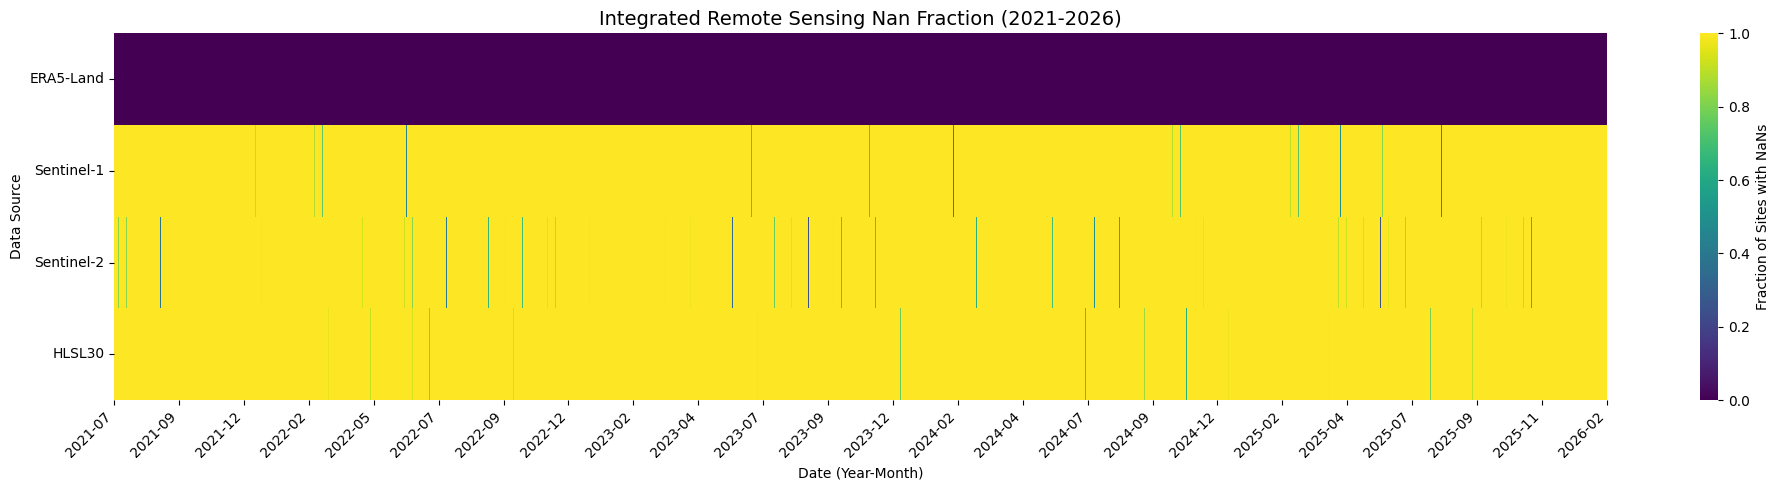

In [52]:
# @title plot satellite feature NaN fraction for each source over time for all sites
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mean across both features (axis 0) and locations (axis 2) to see temporal availability
era5_comp = (np.isnan(era5hour_arr)).any(axis=0).mean(axis=1)
s1_comp = (np.isnan(sentinel1_arr)).any(axis=0).mean(axis=1)
s2_comp = (np.isnan(Sentinel2_arr)).any(axis=0).mean(axis=1)
hls_comp = (np.isnan(HLSL30_arr)).any(axis=0).mean(axis=1)

# 2. Stack them for a combined heatmap (Source x Time)
combined_comp = np.vstack([era5_comp, s1_comp, s2_comp, hls_comp])
source_labels = ['ERA5-Land', 'Sentinel-1', 'Sentinel-2', 'HLSL30']

plt.figure(figsize=(20, 5))
sns.heatmap(
    combined_comp,
    cmap='viridis',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Fraction of Sites with NaNs'}
)

# Temporal Ticks
num_ticks = 24
tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(source_labels)) + 0.5, labels=source_labels, rotation=0)

plt.title('Integrated Remote Sensing Nan Fraction (2021-2026)', fontsize=14)
plt.xlabel('Date (Year-Month)')
plt.ylabel('Data Source')
plt.tight_layout()
plt.show()

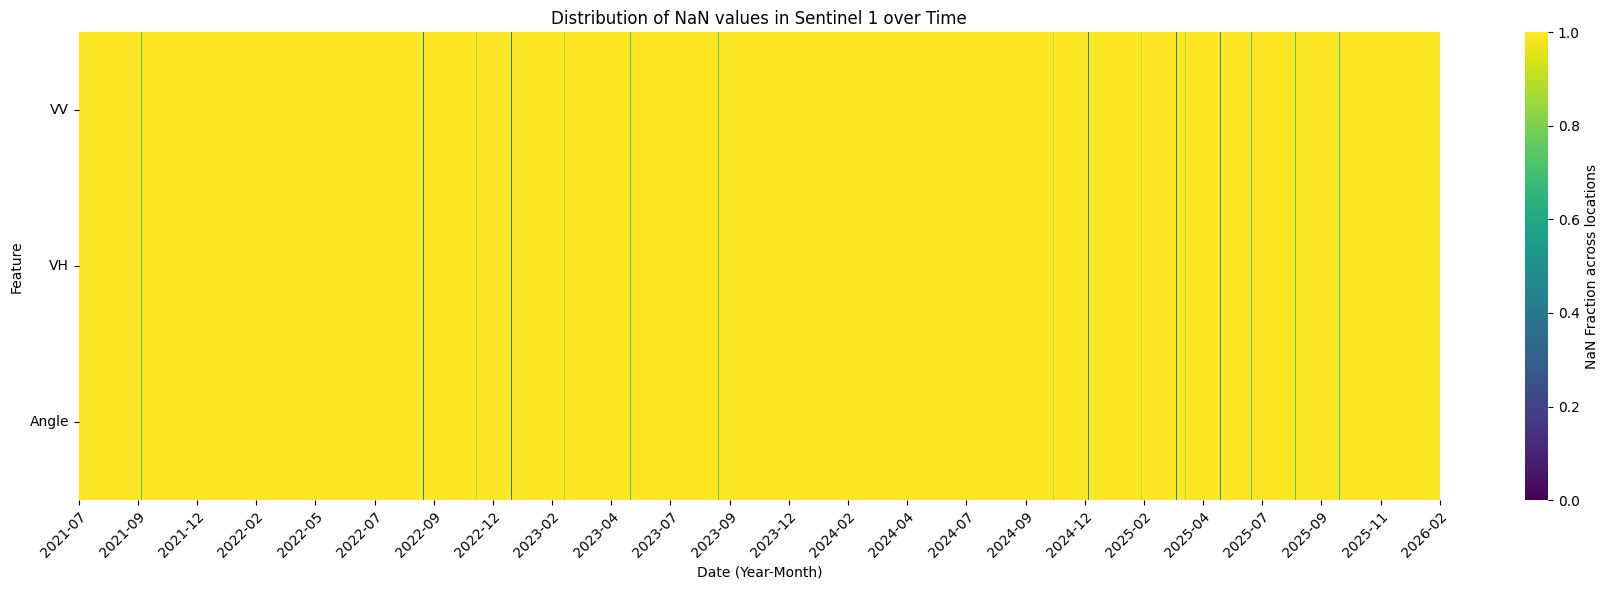

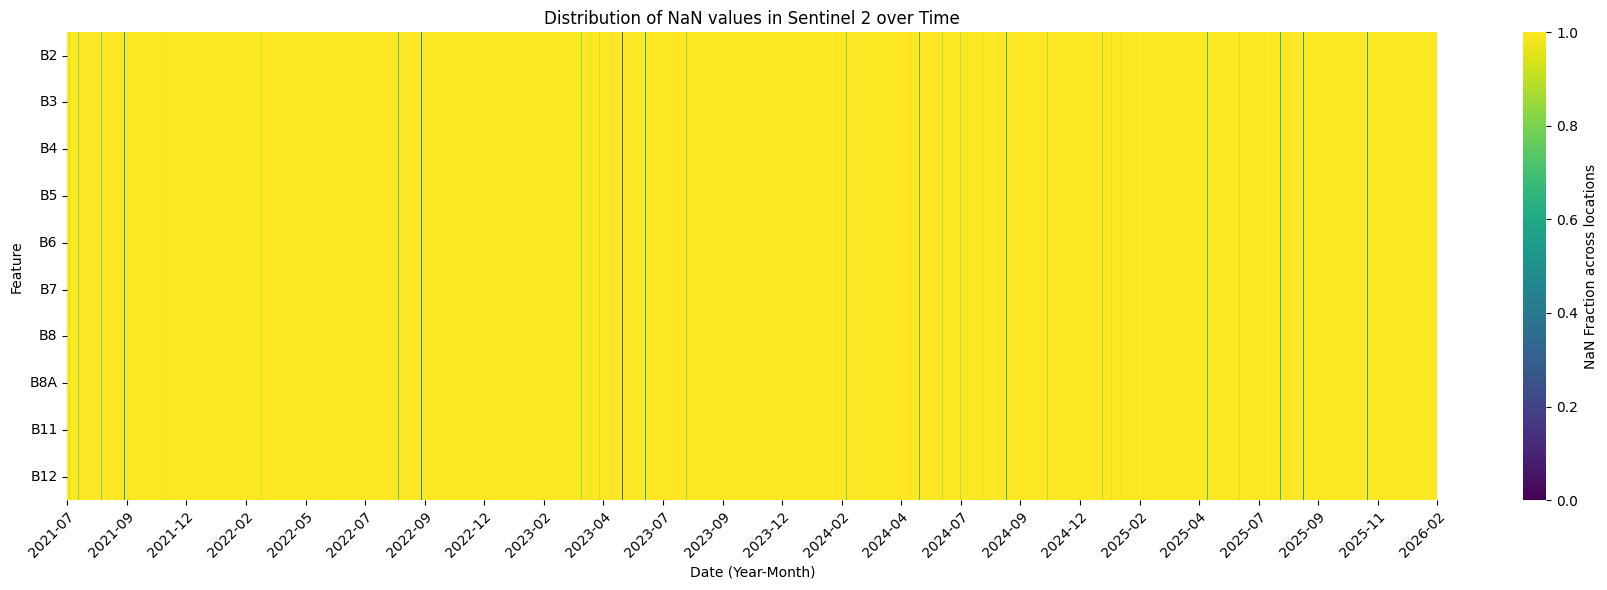

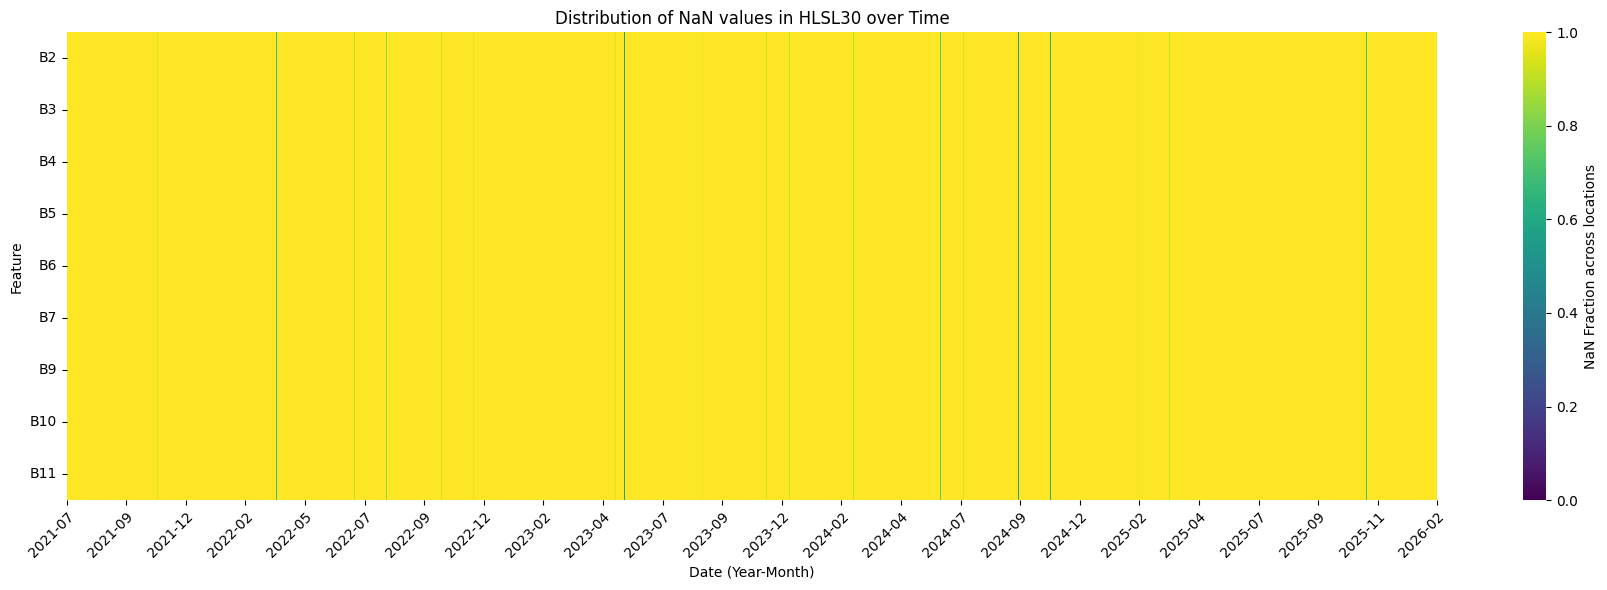

In [53]:
#@title plot remote sensing data NaN fraction per feature per source e.g. sentinel data
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize NaN distribution over time across features (averaged over all locations)
for arr, feature_names, title in zip(
    [sentinel1_arr, Sentinel2_arr, HLSL30_arr],
    [
        ["VV", "VH", "Angle"],
        ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"],
        ["B2", "B3", "B4", "B5", "B6", "B7", "B9", "B10", "B11"]
    ],
    ["Sentinel 1", "Sentinel 2", "HLSL30"],
):
  sat_nan_map = np.isnan(arr).mean(axis=2)  # Shape (8, 40080)

  plt.figure(figsize=(18, 6))
  ax = sns.heatmap(sat_nan_map, cmap='viridis', cbar_kws={'label': 'NaN Fraction across locations'}, vmax=1, vmin=0)

  # Calculate tick positions for dates (e.g., one tick per month or specific interval)
  # Using roughly 10 evenly spaced ticks for clarity across the 40,080 hours
  num_ticks = 24
  tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
  tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

  plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right', rotation_mode='anchor')
  plt.title(f'Distribution of NaN values in {title} over Time')
  plt.xlabel('Date (Year-Month)')
  plt.ylabel('Feature')
  plt.yticks(ticks=np.arange(len(feature_names))+0.5, labels=feature_names, rotation=0)
  plt.tight_layout()
  plt.show()

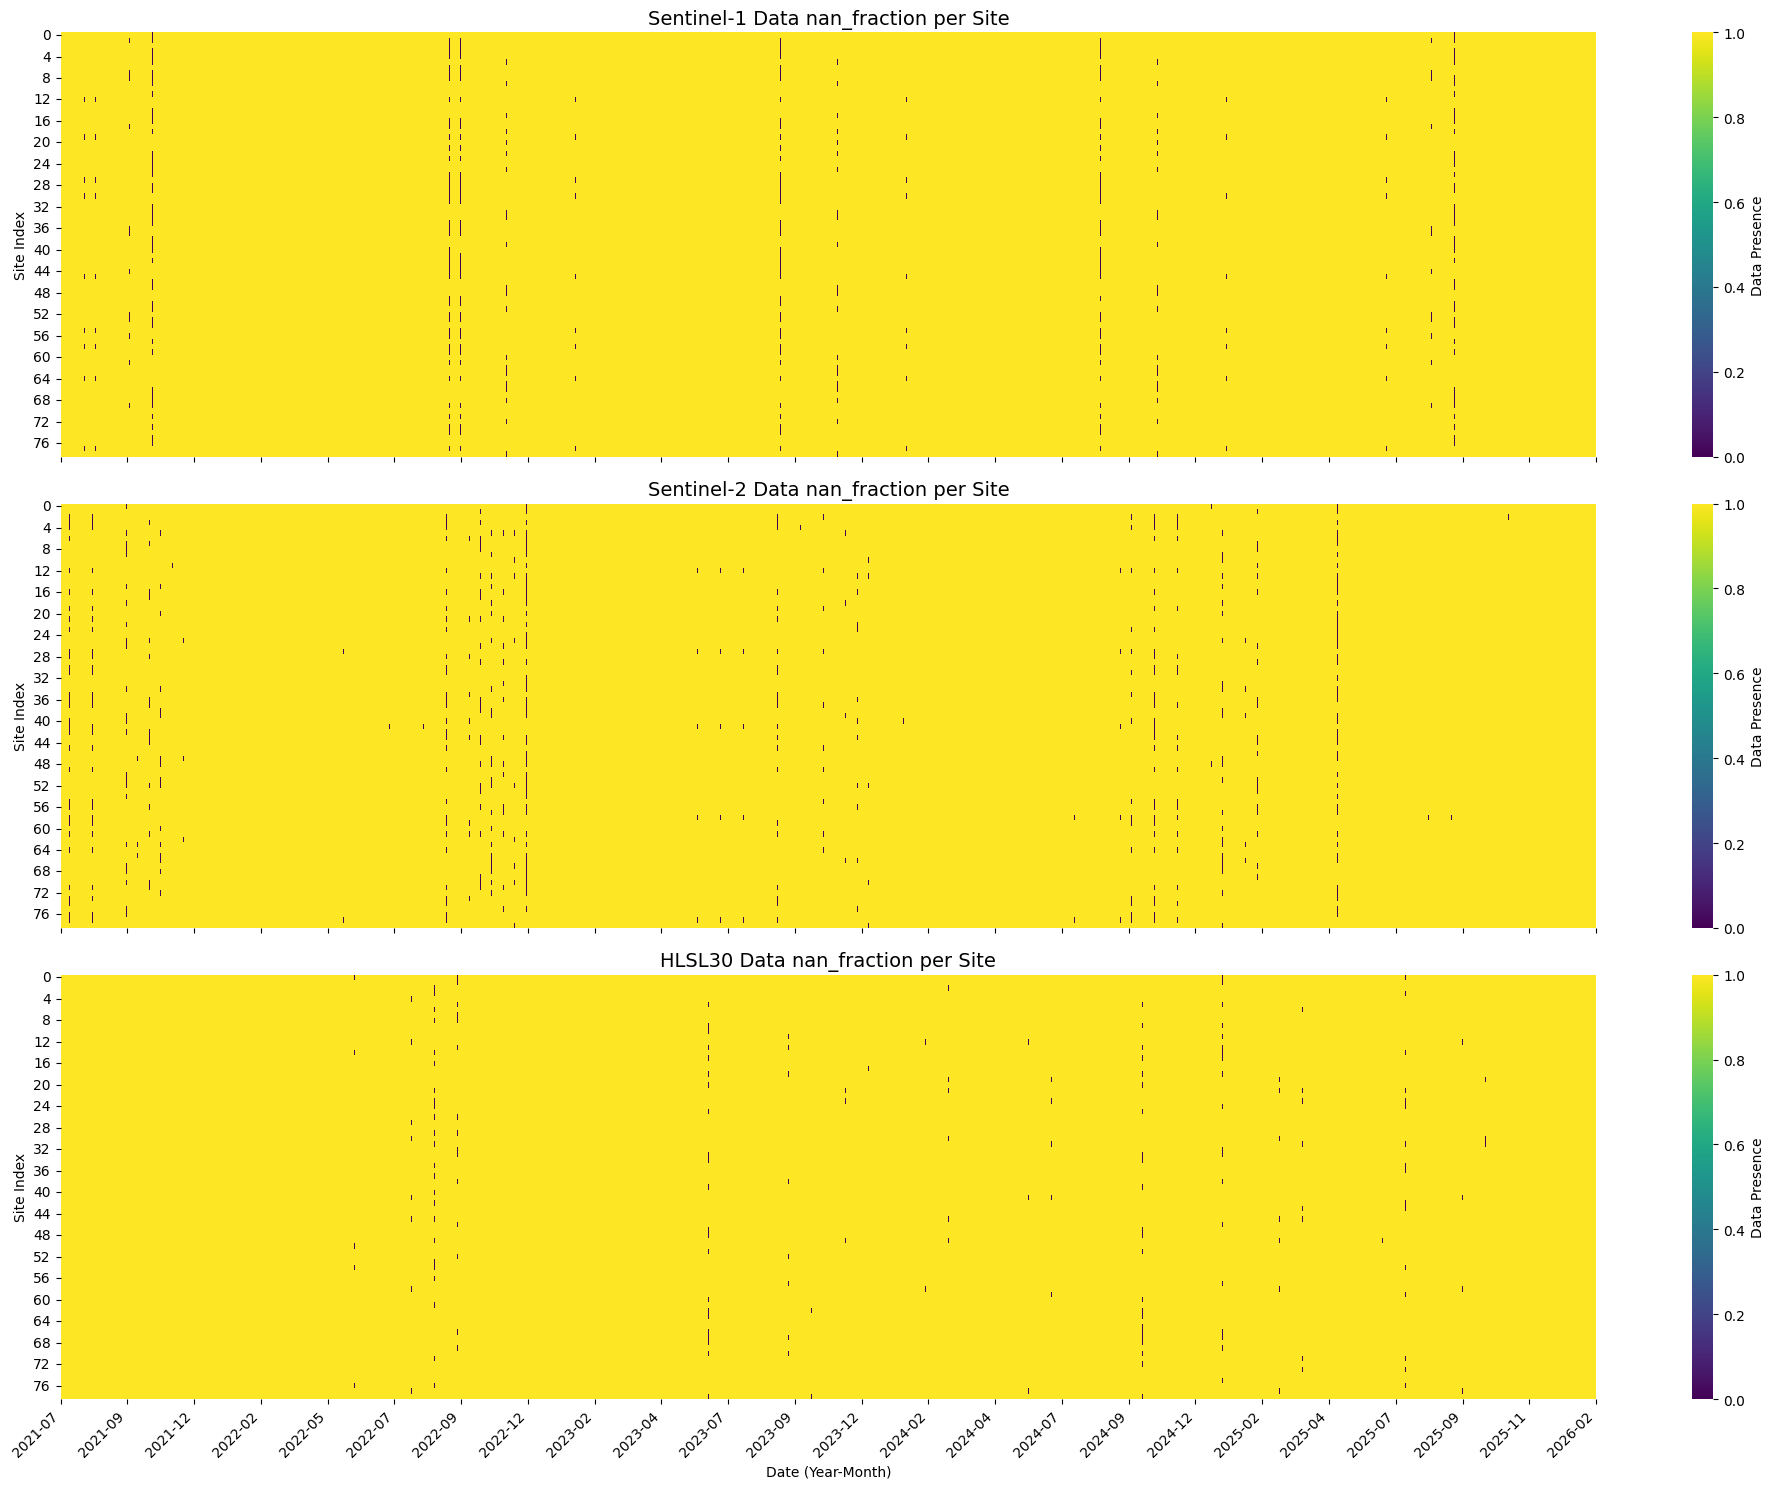

In [54]:
# @title Plot integrated remote sensing data Nan-Fraction per satellite per site
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare subplots for each satellite source
sat_sources = [
    ('Sentinel-1', sentinel1_arr),
    ('Sentinel-2', Sentinel2_arr),
    ('HLSL30', HLSL30_arr)
]

fig, axes = plt.subplots(len(sat_sources), 1, figsize=(20, 15), sharex=True)

# Temporal Ticks
num_ticks = 24
tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

for i, (name, arr) in enumerate(sat_sources):
    # Calculate completeness: Fraction of features present for each (timepoint, site)
    # arr shape is (features, timepoints, sites)
    # Resulting completeness shape: (sites, timepoints)
    nan_fraction = np.isnan(arr).any(axis=0).T

    sns.heatmap(
        nan_fraction,
        ax=axes[i],
        cmap='viridis',
        vmin=0, vmax=1,
        cbar_kws={'label': 'Data Presence'}
    )

    axes[i].set_title(f'{name} Data nan_fraction per Site', fontsize=14)
    axes[i].set_ylabel('Site Index')

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right')
plt.xlabel('Date (Year-Month)')
plt.tight_layout()
plt.show()

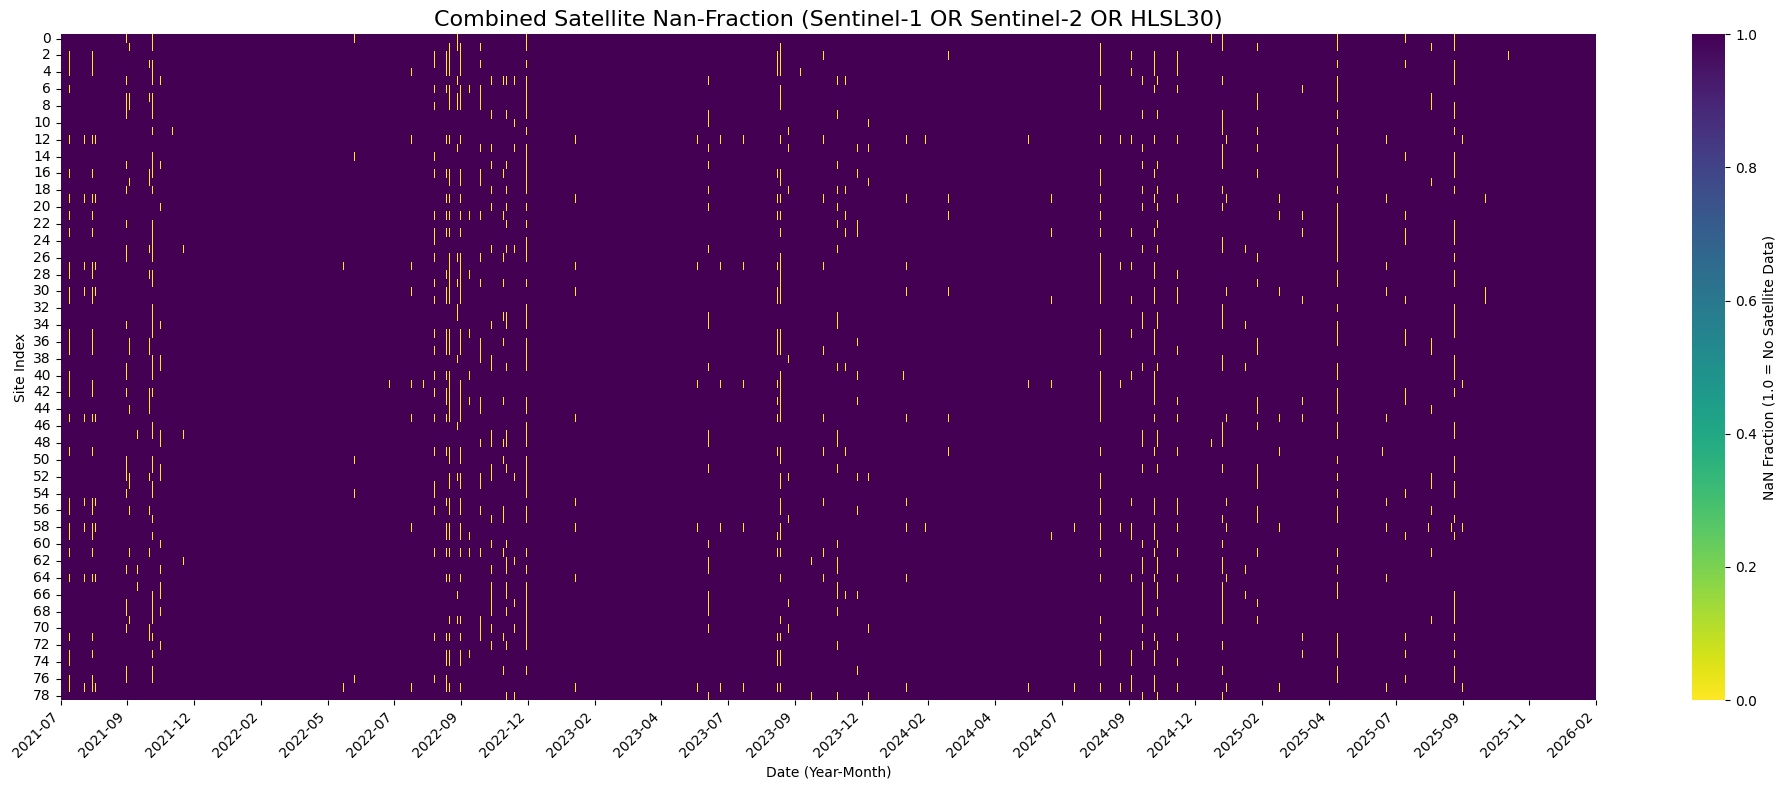

In [55]:
# @title Plot combined remote sensing data Nan-Fraction for all satellites
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate 'Any Satellite' Data Presence
# We check if a value exists (~np.isnan) in ANY of the three sources for each (site, time)
# We use .any(axis=0) to collapse the 'feature' dimension first
s1_present = (~np.isnan(sentinel1_arr)).any(axis=0)
s2_present = (~np.isnan(Sentinel2_arr)).any(axis=0)
hls_present = (~np.isnan(HLSL30_arr)).any(axis=0)

# Combine: True if any source has data at that (time, site)
any_sat_present = s1_present | s2_present | hls_present

# Convert to NaN Fraction (True -> 0 for 'no nan', False -> 1 for 'nan')
# But usually for 'Presence' maps, 1 = data, 0 = no data is more intuitive.
# The prompt asks for Nan-Fraction, so we'll invert it: 1 if all are NaN, 0 if any have data.
any_sat_nan_fraction = (~any_sat_present).astype(float).T

# 2. Plotting
plt.figure(figsize=(20, 8))

# Reuse existing tick logic
num_ticks = 24
tick_indices = np.linspace(0, len(datetime_list) - 1, num_ticks, dtype=int)
tick_labels = [datetime_list[i].strftime('%Y-%m') for i in tick_indices]

sns.heatmap(
    any_sat_nan_fraction,
    cmap='viridis_r', # Reversing viridis so purple = Presence (0 NaN), Yellow = Absence (1 NaN)
    vmin=0, vmax=1,
    cbar_kws={'label': 'NaN Fraction (1.0 = No Satellite Data)'}
)

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right')
plt.title('Combined Satellite Nan-Fraction (Sentinel-1 OR Sentinel-2 OR HLSL30)', fontsize=16)
plt.xlabel('Date (Year-Month)')
plt.ylabel('Site Index')
plt.tight_layout()
plt.show()

In [56]:
any_sat_nan_fraction.shape

(79, 40080)

plotting from 3643 to 8653
plotting from 2021-12-14 19:00:00 to 2022-07-11 13:00:00


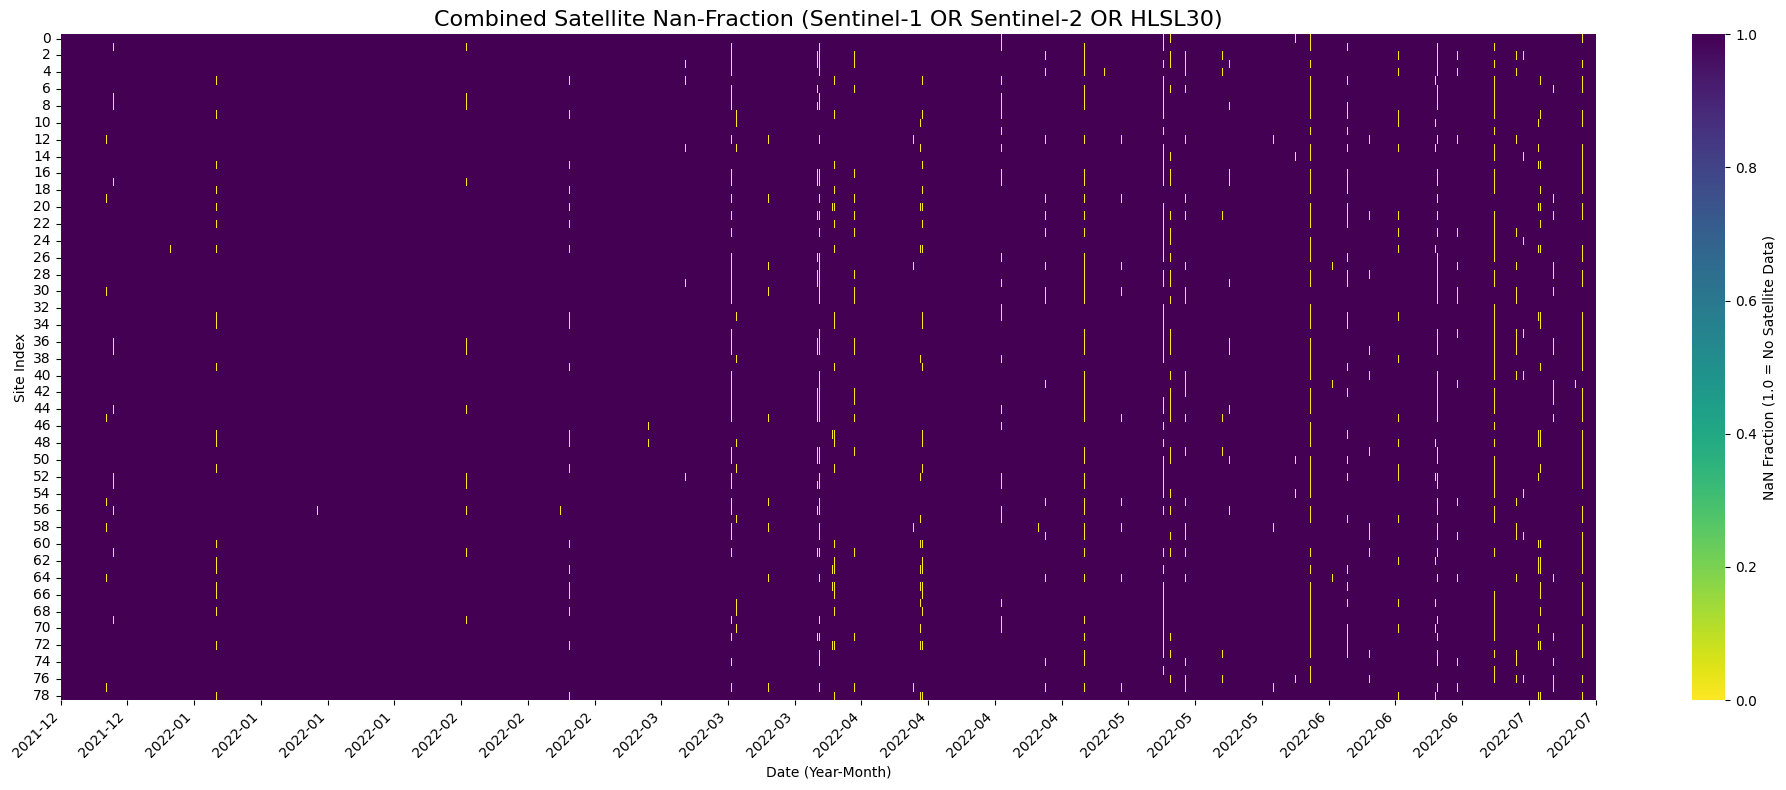

In [57]:
#@title plot zoomed in section of above that looks empty

max_idx = any_sat_nan_fraction.shape[1]
fraction_to_start = 11
fraction_to_plot = 8
start_n = int(max_idx / fraction_to_start)
finish_n = start_n + int(max_idx / fraction_to_plot)
if finish_n > max_idx:
  finish_n = max_idx
print(f'plotting from {start_n} to {finish_n}')
print(f"plotting from {datetime_list[start_n]} to {datetime_list[finish_n]}")

plt.figure(figsize=(20, 8))

# Reuse existing tick logic
num_ticks = 24
tick_indices = np.linspace(0, len(datetime_list[start_n:finish_n]) - 1, num_ticks, dtype=int)
tick_labels = [datetime_list[start_n:finish_n][i].strftime('%Y-%m') for i in tick_indices]

sns.heatmap(
    any_sat_nan_fraction[:, start_n:finish_n],
    cmap='viridis_r', # Reversing viridis so purple = Presence (0 NaN), Yellow = Absence (1 NaN)
    vmin=0, vmax=1,
    cbar_kws={'label': 'NaN Fraction (1.0 = No Satellite Data)'}
)

plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha='right')
plt.title('Combined Satellite Nan-Fraction (Sentinel-1 OR Sentinel-2 OR HLSL30)', fontsize=16)
plt.xlabel('Date (Year-Month)')
plt.ylabel('Site Index')
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import numpy as np

# 1. Calculate Revisit Time of any satelite for each site
site_revisit_stats = []

# any_sat_present shape is (timepoints, sites)
for site_idx in range(any_sat_present.shape[1]):
    # Get indices of timepoints where data is present
    present_indices = np.where(any_sat_present[:, site_idx])[0]

    if len(present_indices) > 1:
        # Calculate differences in hours
        gaps = np.diff(present_indices)
        site_revisit_stats.append({
            'site_index': site_idx,
            'mean_revisit_hours': np.mean(gaps),
            'median_revisit_hours': np.median(gaps),
            'max_gap_hours': np.max(gaps),
            'total_observations': len(present_indices)
        })
    else:
        site_revisit_stats.append({
            'site_index': site_idx,
            'mean_revisit_hours': np.nan,
            'median_revisit_hours': np.nan,
            'max_gap_hours': np.nan,
            'total_observations': len(present_indices)
        })

df_revisit = pd.DataFrame(site_revisit_stats)

# 2. Global statistics (Across all sites)
all_gaps = []
for site_idx in range(any_sat_present.shape[1]):
    present_indices = np.where(any_sat_present[:, site_idx])[0]
    if len(present_indices) > 1:
        all_gaps.extend(np.diff(present_indices).tolist())

print("--- Combined Satellite Revisit Statistics (Sentinel-1, 2, and HLS) ---")
print(f"Global Mean Revisit Time: {np.mean(all_gaps)/24:.2f} days")
print(f"Global Median Revisit Time: {np.median(all_gaps)/24:.2f} days")
print(f"Longest Data Gap: {np.max(all_gaps)/24:.2f} days")

display(df_revisit.sort_values("mean_revisit_hours"))


--- Combined Satellite Revisit Statistics (Sentinel-1, 2, and HLS) ---
Global Mean Revisit Time: 4.48 days
Global Median Revisit Time: 3.04 days
Longest Data Gap: 175.00 days


,site_index,mean_revisit_hours,median_revisit_hours,max_gap_hours,total_observations
12,12,73.193370,48.0,1463,544
77,77,73.873606,48.0,1463,539
58,58,75.558935,54.0,1463,527
27,27,77.776908,55.0,1752,512
33,33,82.912500,51.5,576,481
...,...,...,...,...,...
0,0,189.514286,120.0,3120,211
46,46,190.759615,120.0,2298,209
32,32,194.136585,120.0,2393,206
75,75,217.475410,120.0,3257,184


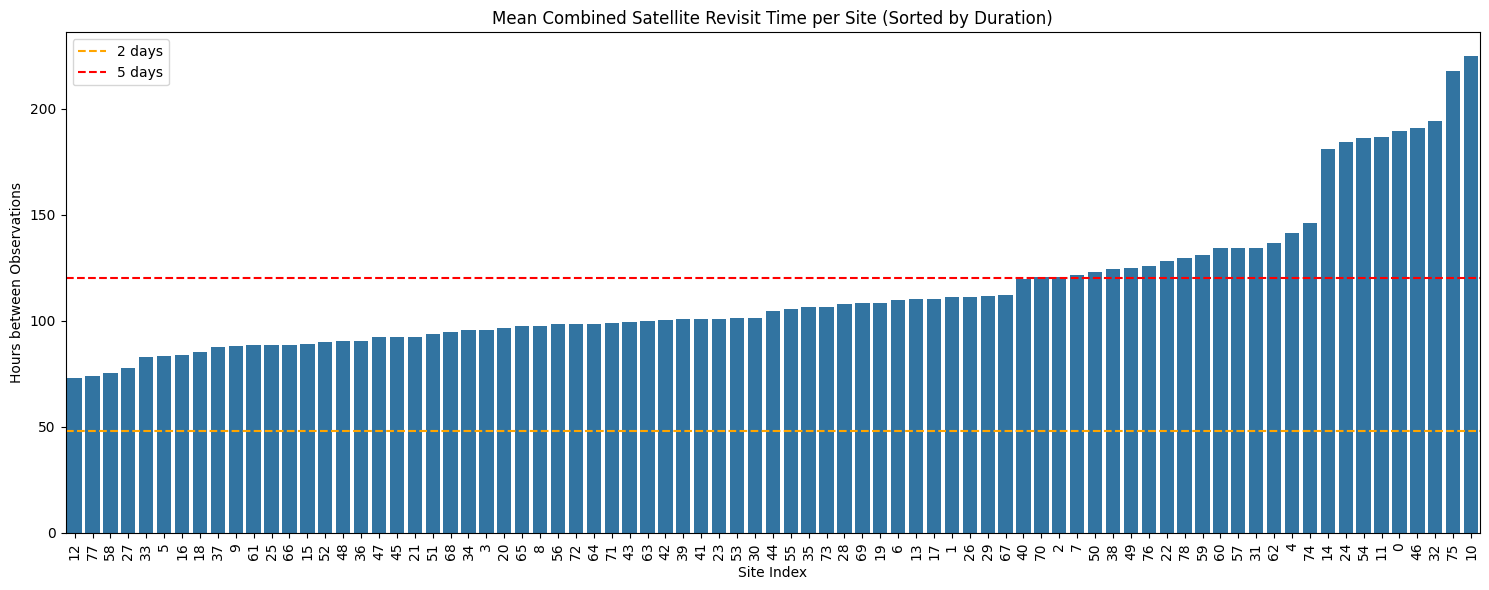

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Revisit Time distribution per site sorted by mean revisit hours
plt.figure(figsize=(15, 6))
sns.barplot(x='site_index', y='mean_revisit_hours', data=df_revisit.sort_values('mean_revisit_hours'), order=df_revisit.sort_values('mean_revisit_hours')['site_index'])
plt.title('Mean Combined Satellite Revisit Time per Site (Sorted by Duration)')
plt.xlabel('Site Index')
plt.ylabel('Hours between Observations')
plt.xticks(rotation=90)
plt.axhline(24 * 2 , color='orange', linestyle='--', label='2 days')
plt.axhline(24 * 5, color='red', linestyle='--', label='5 days')
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
day_limit = 5
site_count = len(df_revisit)
site_count_over = len(df_revisit[df_revisit["mean_revisit_hours"]>(day_limit*24)])

print(f"There are {site_count_over}/{site_count} ({site_count_over/site_count*100:.2f} %) sites with revisit times over {day_limit} days")

There are 25/79 (31.65 %) sites with revisit times over 5 days


# Summary of progress at this point

Specific sites defined.

Time range defined.

All data has been collected and stored for sites and time range

land surface lookup data collected and stored.

Remote sensing data has been collected and stored on GDrive across the specified time range:
1. era5 (for every site and every hour in time range)
2. sentinel-1 (for some sites and some points in time range)
3. sentinel-2 (for some sites and some points in time range)
4. HLSL30 (for some sites and some points in time range)

Remote sensing data for sentinel-1, sentinel-2, and HLSL30 revisit time is less frequent that 5 days for ~1/3 of sites.



# Get ready for ML model SM inference
Remote sensing data per data source is in a 3D array with shape (RS-feature, timepoint, site) e.g. Sentinel-1 (3, 40080, 79)

now we're going to get ready to infer results with the ML models for all sites and times with available data.

Each site at each time point for each model must have all features. i.e. ML-1 (S or R) must have all ERA5 data (no nans, OK), and all Sentinel-1 data. Drop every time point and site from sentinel1_arr where not all three features are present.

Can't represent discontinuous time axis as an array any more? list by site, (all_satellite_features), time?

## ML model

In [61]:
# era5hour_arr = np.load('era5hour_arr_irriClimate.npy')  # loaded already (from gdrive)
print('shape of era5hour_arr: ',era5hour_arr.shape)
print('non-nan numbers: ', np.count_nonzero(~np.isnan(era5hour_arr)))

shape of era5hour_arr:  (8, 40080, 79)
non-nan numbers:  25330560


In [62]:
# @title ERA5 processing

#========================short term====================

ear5_d2m_arr_new = era5hour_arr[1, :, :].copy()
print(ear5_d2m_arr_new.shape)
ear5_t2m_arr_new = era5hour_arr[0, :, :].copy()
ear5_wind_arr_new = era5hour_arr[2, :, :].copy()
ear5_sp_arr_new = era5hour_arr[3, :, :].copy()
for row_idx in range(24, ear5_d2m_arr_new.shape[0]):
    ear5_d2m_arr_new[row_idx, :] = np.sum(era5hour_arr[1, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)
    ear5_t2m_arr_new[row_idx, :] = np.sum(era5hour_arr[0, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)
    ear5_wind_arr_new[row_idx, :] = np.sum(era5hour_arr[2, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)
    ear5_sp_arr_new[row_idx, :] = np.sum(era5hour_arr[3, row_idx - 23: row_idx + 1, :] * short_term_weights[:, np.newaxis], axis=0)


# ========================middle term====================

ear5_ssr_arr_new = era5hour_arr[4, :, :].copy()
ear5_str_arr_new = era5hour_arr[5, :, :].copy()
for row_idx in range(72, ear5_str_arr_new.shape[0]):
    ear5_ssr_arr_new[row_idx, :] = np.sum(era5hour_arr[4, row_idx - 71: row_idx + 1, :] * mid_term_weights[:, np.newaxis], axis=0)
    ear5_str_arr_new[row_idx, :] = np.sum(era5hour_arr[5, row_idx - 71: row_idx + 1, :] * mid_term_weights[:, np.newaxis], axis=0)


# ========================long term====================
ear5_e_arr_new = era5hour_arr[6, :, :].copy()
ear5_tp_arr_new = era5hour_arr[7, :, :].copy()
for row_idx in range(120, ear5_e_arr_new.shape[0]):
    ear5_e_arr_new[row_idx, :] = np.sum(era5hour_arr[6, row_idx - 119: row_idx + 1, :] * long_term_weights[:, np.newaxis] , axis=0)
    ear5_tp_arr_new[row_idx, :] = np.sum(era5hour_arr[7, row_idx - 119: row_idx + 1, :] * long_term_weights[:, np.newaxis], axis=0)

(40080, 79)


In [63]:
print('shape of ear5_d2m_arr_new: ',ear5_d2m_arr_new.shape)
print('shape of ear5_t2m_arr_new: ',ear5_t2m_arr_new.shape)
print('shape of ear5_wind_arr_new: ',ear5_wind_arr_new.shape)
print('shape of ear5_sp_arr_new: ',ear5_sp_arr_new.shape)
print('shape of ear5_ssr_arr_new: ',ear5_ssr_arr_new.shape)
print('shape of ear5_str_arr_new: ',ear5_str_arr_new.shape)
print('shape of ear5_e_arr_new: ',ear5_e_arr_new.shape)
print('shape of ear5_tp_arr_new: ',ear5_tp_arr_new.shape)

shape of ear5_d2m_arr_new:  (40080, 79)
shape of ear5_t2m_arr_new:  (40080, 79)
shape of ear5_wind_arr_new:  (40080, 79)
shape of ear5_sp_arr_new:  (40080, 79)
shape of ear5_ssr_arr_new:  (40080, 79)
shape of ear5_str_arr_new:  (40080, 79)
shape of ear5_e_arr_new:  (40080, 79)
shape of ear5_tp_arr_new:  (40080, 79)


In [64]:
#@title Remove inf values of Sentinel 1 - there are some but I do not know why
sentinel1_arr[sentinel1_arr>1000] = np.nan

In [65]:
referIDArr = df_random_points['ID'].to_numpy()
refer_lat_arr = df_random_points['latitude'].to_numpy()
refer_lon_arr = df_random_points['longitude'].to_numpy()

In [66]:
# @title prepare Xy for ML and store them in npy file - sentinel1-rootzone
"""-------------------------------------sentinel1-rootzone--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,
# VV, VH, angle, CR,  DPSVIm, Pol  - 30
num_ids = len(refer_id_arr)  # 79
X = np.zeros((30, num_hours, num_ids))  # features (30), time/hours (40080), sites (79)
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 # smap4_root_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = sentinel1_arr[0, :, :]
X[25] = sentinel1_arr[1, :, :]
X[26] = sentinel1_arr[2, :, :]
X[27] = sentinel1_arr[0, :, :] / sentinel1_arr[1, :, :]
X[28] = (sentinel1_arr[0, :, :]**2 + sentinel1_arr[1, :, :]**2)/np.sqrt(2)
X[29] = (sentinel1_arr[0, :, :] + sentinel1_arr[1, :, :]) / (sentinel1_arr[0, :, :] - sentinel1_arr[1, :, :])



In [67]:
X.shape

(30, 40080, 79)

In [68]:
# def create_satellite_layer_X_info_test_valid(X) -> np.ndarray:
#     """(n, 4) Xid_all, Xyear_all, Xdoy_all, Xutc_all"""
#     Xid_all = X[0, :]
#     Xyear_all = X[1, :]
#     Xdoy_all = X[2, :]
#     Xutc_all = X[3, :]
#     return np.column_stack((Xid_all, Xyear_all, Xdoy_all, Xutc_all))

In [69]:
# @title squish all timepoints and sites into same axis
X = X.reshape((30, num_hours * num_ids))
X.shape  # (30, 3166320)



(30, 3166320)

In [70]:
X

array([[  47.,    7.,   45., ...,   16.,   44.,   46.],
       [2021., 2021., 2021., ..., 2026., 2026., 2026.],
       [ 197.,  197.,  197., ...,   40.,   40.,   40.],
       ...,
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan]])

In [71]:
# @title mask out all-nan timepoints
X_mask = ~np.any(np.isnan(X), axis=0) # where NOT any feature is nan
print(X_mask.shape)
X_mask

(3166320,)


array([False, False, False, ..., False, False, False])

In [72]:
print(X_mask.sum(), X_mask.shape[0])

print(f"{X_mask.sum() / X_mask.shape[0]*100:.4f} % X non_null")

9812 3166320
0.3099 % X non_null


In [73]:
X_all = X[:, X_mask].T
X_all.shape


(9812, 30)

In [74]:
np.isnan(X_all).sum()

np.int64(0)

In [75]:
print(f"sentinel1-rootzone {X_all.shape=}")
print(f"sentinel1-rootzone {np.isnan(X_all).sum()=}")

np.save('sentinel1_rootzone_X_all_CDL16_24.npy', X_all)

sentinel1-rootzone X_all.shape=(9812, 30)
sentinel1-rootzone np.isnan(X_all).sum()=np.int64(0)


In [76]:
# @title prepare Xy for ML and store them in npy file - sentinel1-surface
"""-------------------------------------sentinel1-surface--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,
# VV, VH, angle, CR,  DPSVIm, Pol  - 30
X = np.zeros((30, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = sentinel1_arr[0, :, :]
X[25] = sentinel1_arr[1, :, :]
X[26] = sentinel1_arr[2, :, :]
X[27] = sentinel1_arr[0, :, :] / sentinel1_arr[1, :, :]
X[28] = (sentinel1_arr[0, :, :] ** 2 + sentinel1_arr[1, :, :] ** 2) / np.sqrt(2)
X[29] = (sentinel1_arr[0, :, :] + sentinel1_arr[1, :, :]) / (sentinel1_arr[0, :, :] - sentinel1_arr[1, :, :])

X = X.reshape((30, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('sentinel1_surface_X_all_CDL16_24.npy', X_all)

(9812, 30)
0


In [77]:


# @title prepare Xy for ML and store them in npy file - sentinel2 etc.
"""-------------------------------------sentinel2-rootzone--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp, - 24
# B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12, NDVI, NDWI, greenness, brightness, wetness  - 39
X = np.zeros((39, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = Sentinel2_arr[0, :, :] * 0.0001 # B2
X[25] = Sentinel2_arr[1, :, :] * 0.0001 # B3
X[26] = Sentinel2_arr[2, :, :] * 0.0001 # B4
X[27] = Sentinel2_arr[3, :, :] * 0.0001 # B5
X[28] = Sentinel2_arr[4, :, :] * 0.0001 # B6
X[29] = Sentinel2_arr[5, :, :] * 0.0001 # B7
X[30] = Sentinel2_arr[6, :, :] * 0.0001 # B8
X[31] = Sentinel2_arr[7, :, :] * 0.0001 # B8A
X[32] = Sentinel2_arr[8, :, :] * 0.0001 # B11
X[33] = Sentinel2_arr[9, :, :] * 0.0001 # B12
X[34] = (X[30] - X[26])/(X[30] + X[26])  # NDVI
X[35] = (X[25] - X[30])/(X[25] + X[30])  # NDWI
X[36] = -0.3599 * X[24] - 0.3533 * X[25] - 0.4734 * X[26] + 0.6633 * X[30] - 0.0087 * X[32] - 0.2856 * X[33] # greenness
X[37] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[30] + 0.2396 * X[32] + 0.1949 * X[33]  # brightness
X[38] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[30] - 0.7611 * X[32] - 0.5308 * X[33]  # wetness

print('sentinel2-rootzone')
print('mean NDVI: ', np.nanmean(X[34]))
print('mean NDWI: ', np.nanmean(X[35]))
print('mean greenness: ', np.nanmean(X[36]))
print('mean brightness: ', np.nanmean(X[37]))
print('mean wetness: ', np.nanmean(X[38]))

X = X.reshape((39, num_hours * num_ids))

y = np.zeros((num_hours, num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)
y_mask = ~np.isnan(y[0])

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('sentinel2_rootzone_X_all_CDL16_24.npy', X_all)

"""-------------------------------------sentinel2-surface--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,- 24
#     # B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12, NDVI, NDWI, greenness, brightness, wetness  - 39
X = np.zeros((39, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = Sentinel2_arr[0, :, :] * 0.0001 # B2
X[25] = Sentinel2_arr[1, :, :] * 0.0001 # B3
X[26] = Sentinel2_arr[2, :, :] * 0.0001 # B4
X[27] = Sentinel2_arr[3, :, :] * 0.0001 # B5
X[28] = Sentinel2_arr[4, :, :] * 0.0001 # B6
X[29] = Sentinel2_arr[5, :, :] * 0.0001 # B7
X[30] = Sentinel2_arr[6, :, :] * 0.0001 # B8
X[31] = Sentinel2_arr[7, :, :] * 0.0001 # B8A
X[32] = Sentinel2_arr[8, :, :] * 0.0001 # B11
X[33] = Sentinel2_arr[9, :, :] * 0.0001 # B12
X[34] = (X[30] - X[26])/(X[30] + X[26])  # NDVI
X[35] = (X[25] - X[30])/(X[25] + X[30])  # NDWI
X[36] = -0.3599 * X[24] - 0.3533 * X[25] - 0.4734 * X[26] + 0.6633 * X[30] - 0.0087 * X[32] - 0.2856 * X[33] # greenness
X[37] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[30] + 0.2396 * X[32] + 0.1949 * X[33]  # brightness
X[38] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[30] - 0.7611 * X[32] - 0.5308 * X[33]  # wetness

print('sentinel2-surface')
print('mean NDVI: ', np.nanmean(X[34]))
print('mean NDWI: ', np.nanmean(X[35]))
print('mean greenness: ', np.nanmean(X[36]))
print('mean brightness: ', np.nanmean(X[37]))
print('mean wetness: ', np.nanmean(X[38]))

X = X.reshape((39, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('sentinel2_surface_X_all_CDL16_24.npy', X_all)


"""-------------------------------------HLSL30-rootzone--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp, - 24
# B2, B3, B4, B5, B6, B7, B10, B11, SZA, SAA, VZA, VAA, NDVI, NDWI, greenness, brightness, wetness  - 41
X = np.zeros((41, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = HLSL30_arr[0, :, :]  # B2
X[25] = HLSL30_arr[1, :, :]   # B3
X[26] = HLSL30_arr[2, :, :]   # B4
X[27] = HLSL30_arr[3, :, :]   # B5
X[28] = HLSL30_arr[4, :, :]  # B6
X[29] = HLSL30_arr[5, :, :]   # B7
X[30] = HLSL30_arr[7, :, :]   # B10
X[31] = HLSL30_arr[8, :, :]   # B11
X[32] = 90 #HLSL30_arr[9, :, :]   # SZA
X[33] = 90 #HLSL30_arr[10, :, :]  # SAA
X[34] = 90 #HLSL30_arr[11, :, :]  # VZA
X[35] = 90 #HLSL30_arr[12, :, :]  # VAA
X[36] = (X[27] - X[26]) / (X[27] + X[26])  # NDVI
X[37] = (X[25] - X[27]) / (X[25] + X[27])  # NDWI
X[38] = -0.2941 * X[24] - 0.243 * X[25] - 0.5424 * X[26] +0.7276 * X[27] +0.0713 * X[28] - 0.1608 * X[29]  # greenness
X[39] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[27] + 0.2396 * X[28] + 0.1949 * X[29]  # brightness
X[40] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[27] - 0.7611 * X[28] - 0.5308 * X[29]  # wetness

print('HLSL30-rootzone')
print('mean NDVI: ', np.nanmean(X[36]))
print('mean NDWI: ', np.nanmean(X[37]))
print('mean greenness: ', np.nanmean(X[38]))
print('mean brightness: ', np.nanmean(X[39]))
print('mean wetness: ', np.nanmean(X[40]))

X = X.reshape((41, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('HLSL30_rootzone_X_all_CDL16_24.npy', X_all)

"""-------------------------------------HLSL30-surface--------------------------------------"""
# X - ID, year, doy, hour, latitude, longitude, dem, slope, sinAspect, cosAspect, TWI,
# bd, sand, clay, ksat, SMAP, d2m, t2m, ssr,str, e, wind, sp, tp,- 24
#    B2, B3, B4, B5, B6, B7, B10, B11, SZA, SAA, VZA, VAA, NDVI, NDWI, greenness, brightness, wetness  - 41
X = np.zeros((41, num_hours, num_ids))
X[:] = np.nan
X[0] = np.tile(referIDArr, (num_hours, 1))
X[1] = np.repeat(year_list[:, np.newaxis], num_ids, axis=1)
X[2] = np.repeat(doy_list[:, np.newaxis], num_ids, axis=1)
X[3] = np.repeat(hour_list[:, np.newaxis], num_ids, axis=1)
X[4] = np.tile(refer_lat_arr, (num_hours, 1))
X[5] = np.tile(refer_lon_arr, (num_hours, 1))
X[6] = np.tile(elevation_arr, (num_hours, 1))
X[7] = np.tile(slopeDegree_arr, (num_hours, 1))
X[8] = np.tile(sinAsp_arr, (num_hours, 1))
X[9] = np.tile(cosAsp_arr, (num_hours, 1))
X[10] = np.tile(TWII_arr, (num_hours, 1))
X[11] = np.tile(ml_bd_0_100, (num_hours, 1))
X[12] = np.tile(ml_sand_0_100, (num_hours, 1))
X[13] = np.tile(ml_clay_0_100, (num_hours, 1))
X[14] = np.tile(ml_ksat_0_100, (num_hours, 1))
X[15] = 0.3 #smap4_surface_arr.T
X[16] = ear5_d2m_arr_new
X[17] = ear5_t2m_arr_new
X[18] = ear5_ssr_arr_new
X[19] = ear5_str_arr_new
X[20] = ear5_e_arr_new
X[21] = ear5_wind_arr_new
X[22] = ear5_sp_arr_new
X[23] = ear5_tp_arr_new
X[24] = HLSL30_arr[0, :, :]  # B2
X[25] = HLSL30_arr[1, :, :]  # B3
X[26] = HLSL30_arr[2, :, :]  # B4
X[27] = HLSL30_arr[3, :, :]  # B5
X[28] = HLSL30_arr[4, :, :]  # B6
X[29] = HLSL30_arr[5, :, :]  # B7
X[30] = HLSL30_arr[7, :, :] # B10
X[31] = HLSL30_arr[8, :, :]  # B11
X[32] = 90 #HLSL30_arr[9, :, :]  # SZA
X[33] = 90 #HLSL30_arr[10, :, :]  # SAA
X[34] = 90 #HLSL30_arr[11, :, :]  # VZA
X[35] = 90 #HLSL30_arr[12, :, :]  # VAA
X[36] = (X[27] - X[26]) / (X[27] + X[26])  # NDVI
X[37] = (X[25] - X[27]) / (X[25] + X[27])  # NDWI
X[38] = -0.2941 * X[24] - 0.243 * X[25] - 0.5424 * X[26] +0.7276 * X[27] +0.0713 * X[28] - 0.1608 * X[29]  # greenness
X[39] = 0.3510 * X[24] + 0.3813 * X[25] + 0.3437 * X[26] + 0.7196 * X[27] + 0.2396 * X[28] + 0.1949 * X[29]  # brightness
X[40] = 0.2578 * X[24] + 0.2305 * X[25] + 0.0883 * X[26] + 0.1071 * X[27] - 0.7611 * X[28] - 0.5308 * X[29]  # wetness

print('HLSL30-surface')
print('mean NDVI: ', np.nanmean(X[36]))
print('mean NDWI: ', np.nanmean(X[37]))
print('mean greenness: ', np.nanmean(X[38]))
print('mean brightness: ', np.nanmean(X[39]))
print('mean wetness: ', np.nanmean(X[40]))

X = X.reshape((41, num_hours * num_ids))

X_mask = ~np.any(np.isnan(X), axis=0)

X_all = X[:, X_mask].T

print(X_all.shape)
print(np.count_nonzero(np.isnan(X_all)))

np.save('HLSL30_surface_X_all_CDL16_24.npy', X_all)


print()

sentinel2-rootzone
mean NDVI:  0.535979398609933
mean NDWI:  -0.5404176398007555
mean greenness:  0.054754261824426095
mean brightness:  0.40142146127275646
mean wetness:  -0.19771196619332915
(13996, 39)
0
sentinel2-surface
mean NDVI:  0.535979398609933
mean NDWI:  -0.5404176398007555
mean greenness:  0.054754261824426095
mean brightness:  0.40142146127275646
mean wetness:  -0.19771196619332915
(13996, 39)
0
HLSL30-rootzone
mean NDVI:  0.5651097260780795
mean NDWI:  -0.5843809455005694
mean greenness:  0.13784867247396781
mean brightness:  0.3831803536336119
mean wetness:  -0.19923736516315532
(5506, 41)
0
HLSL30-surface
mean NDVI:  0.5651097260780795
mean NDWI:  -0.5843809455005694
mean greenness:  0.13784867247396781
mean brightness:  0.3831803536336119
mean wetness:  -0.19923736516315532
(5506, 41)
0



In [78]:
from google.colab import files
import os

# List all files in the current directory (root folder)
files_to_download = [f for f in os.listdir('.') if os.path.isfile(f) and f.endswith(('y_CDL16_24.npy', '_X_valid.npy', '_y_valid.npy'))]

for file_name in files_to_download:
  try:
    files.download(file_name)
  except Exception as e:
    print(f"Error downloading {file_name}: {e}")

In [79]:
np.set_printoptions(suppress=True, precision=6, floatmode='fixed')

HLSL30_surface_X_all = np.load('HLSL30_surface_X_all_CDL16_24.npy')
print(np.nanmean(HLSL30_surface_X_all, axis=0))
HLSL30_rootzone_X_all = np.load('HLSL30_rootzone_X_all_CDL16_24.npy')
print(np.nanmean(HLSL30_rootzone_X_all, axis=0))
sentinel2_rootzone_X_all = np.load('sentinel2_rootzone_X_all_CDL16_24.npy')
print(np.nanmean(sentinel2_rootzone_X_all, axis=0))
sentinel2_surface_X_all = np.load('sentinel2_surface_X_all_CDL16_24.npy')
print(np.nanmean(sentinel2_surface_X_all, axis=0))
sentinel1_rootzone_X_all = np.load('sentinel1_rootzone_X_all_CDL16_24.npy')
print(np.nanmean(sentinel1_rootzone_X_all, axis=0))
sentinel1_surface_X_all = np.load('sentinel1_surface_X_all_CDL16_24.npy')
print(np.nanmean(sentinel1_surface_X_all, axis=0))

[     43.575191    2023.325463     210.909372      16.000000
      44.394919     -89.769543     317.699952       1.333226
      -0.104264      -0.007841       4.806806       1.484622
      43.659524      16.623785       5.768552       0.300000
     279.534287     286.273832  958990.541006 1092833.924037
      -0.000114       2.914412   97994.384766       0.000052
       0.046514       0.077701       0.082764       0.305448
       0.247118       0.152749      18.365796      17.297150
      90.000000      90.000000      90.000000      90.000000
       0.565110      -0.584381       0.137849       0.383180
      -0.199237]
[     43.575191    2023.325463     210.909372      16.000000
      44.394919     -89.769543     317.699952       1.333226
      -0.104264      -0.007841       4.806806       1.484622
      43.659524      16.623785       5.768552       0.300000
     279.534287     286.273832  958990.541006 1092833.924037
      -0.000114       2.914412   97994.384766       0.000052
       

In [80]:
# sentinel1_surface_X_all[:10, :4]
# np.unique(sentinel1_surface_X_all[:, :1])
sentinel1_surface_X_all[:1, :]

array([[     38.000000,    2021.000000,     199.000000,       0.000000,
             45.285801,     -92.321297,     339.442413,       1.482144,
              0.967591,      -0.252522,       3.616568,       1.555268,
             47.129379,      11.031423,       2.904594,       0.300000,
            287.516363,     298.473268, 1175286.000000, 1320681.000000,
             -0.000229,       1.352502,   98009.170323,       0.000000,
            -13.569514,     -20.253853,      42.814919,       0.669972,
            420.269108,      -5.060092]])

In [81]:
# @title load y_test_valid for each site from Wisconet data

wisconet_data_file = gdrive_data_dir / "wisconet_soil_moisture_data" / "wisconet_sites_soil_moisture_with_rootzone.npy"
wisconet_sm_arr = np.load(wisconet_data_file, allow_pickle=True)
wisconet_sm_arr


sentinel1_surface_X_all

array([[  38.000000, 2021.000000,  199.000000, ...,    0.669972,
         420.269108,   -5.060092],
       [  53.000000, 2021.000000,  199.000000, ...,    0.667610,
         325.326863,   -5.017024],
       [  78.000000, 2021.000000,  199.000000, ...,    0.673103,
         347.158015,   -5.118129],
       ...,
       [  67.000000, 2026.000000,   30.000000, ...,    0.541321,
         411.439612,   -3.360345],
       [  58.000000, 2026.000000,   30.000000, ...,    0.581240,
         534.482740,   -3.776004],
       [  16.000000, 2026.000000,   30.000000, ...,    0.562732,
         287.504855,   -3.573855]])

In [82]:
# @ title create y_test_valid arrays of soil moisture for each satellite and layer
import pandas as pd
import numpy as np


def create_y_test_valid(
      inference_x_arr: np.ndarray,
      ground_truth_arr: np.ndarray,
      target_col_idx: int,
    ) -> np.ndarray:
    """
    add appropriate wisconet_sm_arr numpy array data ('soil_moisture_5cm_m3m-3_avg' or 'soil_moisture_rootzone_m3m-3_avg') from wisconet_sm_arr with columns:
    [
      'station_id_int',
      'station_id',
      'local_datetime',
      'soil_moisture_5cm_m3m-3_avg',
      'soil_moisture_10cm_m3m-3_avg',
      'soil_moisture_20cm_m3m-3_avg',
      'soil_moisture_50cm_m3m-3_avg',
      'soil_moisture_100cm_m3m-3_avg',
      'soil_moisture_rootzone_m3m-3_avg'
    ]
    to HRSM inference arrays e.g. sentinel1_surface_X_all numpy array
    on the basis of matching station_id and local_datetime to the inference array (e.g. sentinel1_surface_X_all) which has first four columns:
    [
      'station_id_int', 'local_datetime_year', 'local_datetime_day_of_year', 'local_datetime_hour',
    ]

    inference_x_arr: numpy array where first 4 columns are [station_id_int, year, doy, hour]
    ground_truth_arr: wisconet_sm_arr with columns specified in prompt
    target_col_idx: Index of the soil moisture column in ground_truth_arr to extract
    """
    # 1. Create a lookup dictionary from ground truth for O(1) matching
    # Keys: (station_id_int, year, doy, hour) -> Value: soil_moisture
    lookup = {}
    for row in ground_truth_arr:
        sid = int(row[0])
        dt = row[2] # local_datetime object
        val = row[target_col_idx]

        key = (sid, dt.year, dt.timetuple().tm_yday, dt.hour)
        lookup[key] = val

    # 2. Map inference array rows to ground truth values
    y_values = []
    for row in inference_x_arr:
        key = (int(row[0]), int(row[1]), int(row[2]), int(row[3]))
        y_values.append(lookup.get(key, np.nan))

    return np.array(y_values)

# Column indices for wisconet_sm_arr
# 0: station_id_int, 1: station_id, 2: local_datetime, 3: 5cm_avg, ..., 8: rootzone_avg
SURFACE_SM_IDX = 3
ROOTZONE_SM_IDX = 8

# Sentinel-1 Surface
sentinel1_surface_y_test_valid = create_y_test_valid(sentinel1_surface_X_all, wisconet_sm_arr, SURFACE_SM_IDX)
sentinel1_rootzone_y_test_valid = create_y_test_valid(sentinel1_rootzone_X_all, wisconet_sm_arr, ROOTZONE_SM_IDX)

# Sentinel-2
sentinel2_surface_y_test_valid = create_y_test_valid(sentinel2_surface_X_all, wisconet_sm_arr, SURFACE_SM_IDX)
sentinel2_rootzone_y_test_valid = create_y_test_valid(sentinel2_rootzone_X_all, wisconet_sm_arr, ROOTZONE_SM_IDX)

# HLSL30
hlsl30_surface_y_test_valid = create_y_test_valid(HLSL30_surface_X_all, wisconet_sm_arr, SURFACE_SM_IDX)
hlsl30_rootzone_y_test_valid = create_y_test_valid(HLSL30_rootzone_X_all, wisconet_sm_arr, ROOTZONE_SM_IDX)

print(f"Matched S1 Surface Ground Truth count: {np.count_nonzero(~np.isnan(sentinel1_surface_y_test_valid))}/{len(sentinel1_surface_y_test_valid)}")
print(f"Matched S1 RootZone Ground Truth count: {np.count_nonzero(~np.isnan(sentinel1_rootzone_y_test_valid))}/{len(sentinel1_rootzone_y_test_valid)}")
print(f"Matched S2 Surface Ground Truth count: {np.count_nonzero(~np.isnan(sentinel2_surface_y_test_valid))}/{len(sentinel2_surface_y_test_valid)}")
print(f"Matched S2 RootZone Ground Truth count: {np.count_nonzero(~np.isnan(sentinel2_rootzone_y_test_valid))}/{len(sentinel2_rootzone_y_test_valid)}")
print(f"Matched HLSL30 Surface Ground Truth count: {np.count_nonzero(~np.isnan(hlsl30_surface_y_test_valid))}/{len(hlsl30_surface_y_test_valid)}")
print(f"Matched HLSL30 RootZone Ground Truth count: {np.count_nonzero(~np.isnan(hlsl30_rootzone_y_test_valid))}/{len(hlsl30_rootzone_y_test_valid)}")

Matched S1 Surface Ground Truth count: 3629/9812
Matched S1 RootZone Ground Truth count: 2940/9812
Matched S2 Surface Ground Truth count: 4917/13996
Matched S2 RootZone Ground Truth count: 3963/13996
Matched HLSL30 Surface Ground Truth count: 1740/5506
Matched HLSL30 RootZone Ground Truth count: 1505/5506


In [83]:
# @title Capture site info and timing information before scaling

# Sentinel-1
sentinel1_surface_X_info_test_valid = sentinel1_surface_X_all[:, :4].copy()
sentinel1_rootzone_X_info_test_valid = sentinel1_rootzone_X_all[:, :4].copy()

# Sentinel-2
sentinel2_surface_X_info_test_valid = sentinel2_surface_X_all[:, :4].copy()
sentinel2_rootzone_X_info_test_valid = sentinel2_rootzone_X_all[:, :4].copy()

# HLSL30
hlsl30_surface_X_info_test_valid = HLSL30_surface_X_all[:, :4].copy()
hlsl30_rootzone_X_info_test_valid = HLSL30_rootzone_X_all[:, :4].copy()

In [84]:
# quite a lot of rows without truth values - strange.
nan_values_mask = np.isnan(sentinel1_surface_y_test_valid)
sentinel1_surface_X_all[nan_values_mask][:, :4]

array([[  38.000000, 2021.000000,  199.000000,    0.000000],
       [  53.000000, 2021.000000,  199.000000,    0.000000],
       [  78.000000, 2021.000000,  199.000000,    0.000000],
       ...,
       [  84.000000, 2026.000000,   17.000000,   23.000000],
       [  36.000000, 2026.000000,   30.000000,   23.000000],
       [  41.000000, 2026.000000,   30.000000,   23.000000]])

In [85]:
np.unique(sentinel1_surface_X_all[nan_values_mask][:, 0])  # every site

array([ 1.000000,  2.000000,  3.000000,  4.000000,  5.000000,  7.000000,
        8.000000,  9.000000, 10.000000, 11.000000, 12.000000, 13.000000,
       14.000000, 15.000000, 16.000000, 17.000000, 18.000000, 19.000000,
       20.000000, 24.000000, 26.000000, 27.000000, 28.000000, 29.000000,
       30.000000, 31.000000, 32.000000, 33.000000, 34.000000, 35.000000,
       36.000000, 37.000000, 38.000000, 39.000000, 40.000000, 41.000000,
       42.000000, 43.000000, 44.000000, 45.000000, 46.000000, 47.000000,
       48.000000, 49.000000, 50.000000, 51.000000, 52.000000, 53.000000,
       54.000000, 55.000000, 56.000000, 57.000000, 58.000000, 59.000000,
       60.000000, 62.000000, 64.000000, 65.000000, 67.000000, 68.000000,
       69.000000, 70.000000, 71.000000, 72.000000, 73.000000, 74.000000,
       75.000000, 76.000000, 77.000000, 78.000000, 79.000000, 80.000000,
       81.000000, 82.000000, 83.000000, 84.000000])

In [86]:
np.unique(sentinel1_surface_X_all[nan_values_mask][:, 1])  # every year

array([2021.000000, 2022.000000, 2023.000000, 2024.000000, 2025.000000,
       2026.000000])

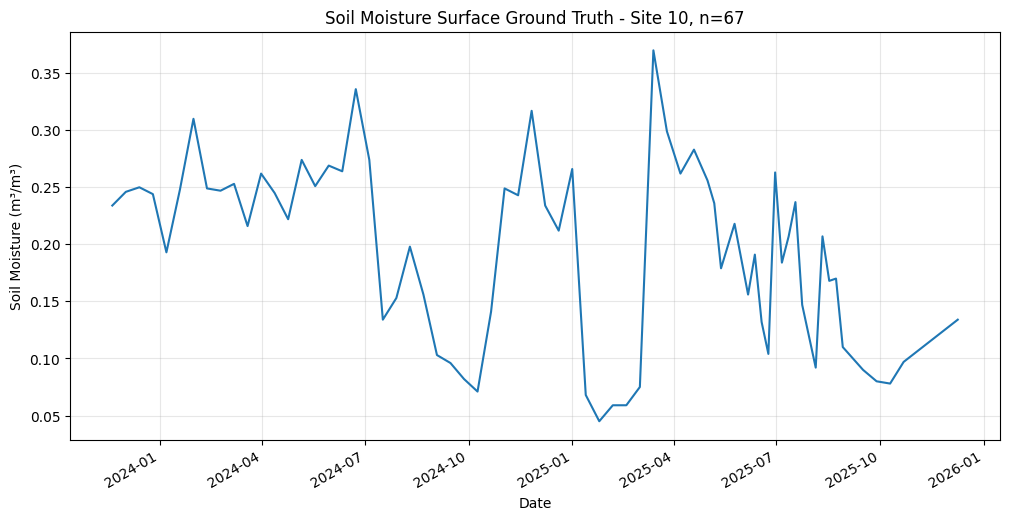

In [87]:
# @title plot one site's available wisconet truth for surface data
import pandas as pd
import matplotlib.pyplot as plt

site_int_id_column_index = 0
site_int_id = 10

site_mask = sentinel1_surface_X_all[:, site_int_id_column_index] == site_int_id
filtered_arr = sentinel1_surface_X_all[site_mask]

# filtered_arr columns are: [station_id, year, doy, hour, ...]
years = filtered_arr[:, 1].astype(int)
doys = filtered_arr[:, 2].astype(int)
hours = filtered_arr[:, 3].astype(int)

# Method: Create strings and parse with pandas (vectorised)
# Format '%Y%j%H' where %j is day of year (1-366)
date_strings = (
    pd.Series(years).astype(str)
    + pd.Series(doys).astype(str).str.zfill(3)
    + pd.Series(hours).astype(str).str.zfill(2)
)
filtered_datetimes = pd.to_datetime(date_strings, format='%Y%j%H').to_numpy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(filtered_datetimes, sentinel1_surface_y_test_valid[site_mask])

non_nan_site_obs_count = np.count_nonzero(
    ~np.isnan(
        sentinel1_surface_y_test_valid[site_mask]
    )
)

ax.set_title(f'Soil Moisture Surface Ground Truth - Site {site_int_id}, n={non_nan_site_obs_count}')
ax.set_xlabel('Date')
ax.set_ylabel('Soil Moisture (m³/m³)')

# Rotate x-axis labels
plt.xticks(rotation=45)
fig.autofmt_xdate() # Auto-format for date overlap

plt.grid(True, alpha=0.3)
plt.show()

## run ML models

In [88]:
# import joblib
# import mapie

!git clone https://github.com/ilmcconnell/HRSM.git
!cd HRSM && git checkout ilm-wisconet

Cloning into 'HRSM'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 299 (delta 73), reused 28 (delta 18), pack-reused 182 (from 3)
Receiving objects: 100% (299/299), 71.59 MiB | 17.75 MiB/s, done.
Resolving deltas: 100% (122/122), done.
Updating files: 100% (35/35), done.
Branch 'ilm-wisconet' set up to track remote branch 'ilm-wisconet' from 'origin'.
Switched to a new branch 'ilm-wisconet'


In [89]:
! ls -lsh ./HRSM/trainedML/

total 95M
9.5M -rw-r--r-- 1 root root 9.5M Sep  2 13:34 ML1_rly_lgb_mean.joblib
 31M -rw-r--r-- 1 root root  31M Sep  2 13:34 ML1_rly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.3K Sep  2 13:34 ML1_rly_scaler.joblib
5.8M -rw-r--r-- 1 root root 5.8M Sep  2 13:34 ML1_sly_lgb_mean.joblib
 19M -rw-r--r-- 1 root root  19M Sep  2 13:34 ML1_sly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.3K Sep  2 13:34 ML1_sly_scaler.joblib
416K -rw-r--r-- 1 root root 415K Sep  2 13:34 ML2_rly_lgb_mean.joblib
1.4M -rw-r--r-- 1 root root 1.4M Sep  2 13:34 ML2_rly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.4K Sep  2 13:34 ML2_rly_scaler.joblib
1.4M -rw-r--r-- 1 root root 1.4M Sep  2 13:34 ML2_sly_lgb_mean.joblib
4.4M -rw-r--r-- 1 root root 4.4M Sep  2 13:34 ML2_sly_mapie_cqr.joblib
4.0K -rw-r--r-- 1 root root 1.4K Sep  2 13:34 ML2_sly_scaler.joblib
3.1M -rw-r--r-- 1 root root 3.1M Sep  2 13:34 ML3_rly_lgb_mean.joblib
9.2M -rw-r--r-- 1 root root 9.2M Sep  2 13:34 ML3_rly_mapie_cqr.joblib
4.0K -rw-r--r

In [90]:
#@title Load ML models - this is the ML models from the HRSM repo
ML1_sly_scaler = joblib.load('./HRSM/trainedML/ML1_sly_scaler.joblib')
ML1_rly_scaler = joblib.load('./HRSM/trainedML/ML1_rly_scaler.joblib')
ML2_sly_scaler = joblib.load('./HRSM/trainedML/ML2_sly_scaler.joblib')
ML2_rly_scaler = joblib.load('./HRSM/trainedML/ML2_rly_scaler.joblib')
ML3_sly_scaler = joblib.load('./HRSM/trainedML/ML3_sly_scaler.joblib')
ML3_rly_scaler = joblib.load('./HRSM/trainedML/ML3_rly_scaler.joblib')
# ML1-sly
ML1_sly_lgb_mean = joblib.load('./HRSM/trainedML/ML1_sly_lgb_mean.joblib')
ML1_sly_mapie_cqr = joblib.load('./HRSM/trainedML/ML1_sly_mapie_cqr.joblib')
# ML1 - rly
ML1_rly_lgb_mean = joblib.load('./HRSM/trainedML/ML1_rly_lgb_mean.joblib')
ML1_rly_mapie_cqr = joblib.load('./HRSM/trainedML/ML1_rly_mapie_cqr.joblib')
# ML2-sly
ML2_sly_lgb_mean = joblib.load('./HRSM/trainedML/ML2_sly_lgb_mean.joblib')
ML2_sly_mapie_cqr = joblib.load('./HRSM/trainedML/ML2_sly_mapie_cqr.joblib')
# ML2-rly
ML2_rly_lgb_mean = joblib.load('./HRSM/trainedML/ML2_rly_lgb_mean.joblib')
ML2_rly_mapie_cqr = joblib.load('./HRSM/trainedML/ML2_rly_mapie_cqr.joblib')
# ML3-sly
ML3_sly_lgb_mean = joblib.load('./HRSM/trainedML/ML3_sly_lgb_mean.joblib')
ML3_sly_mapie_cqr = joblib.load('./HRSM/trainedML/ML3_sly_mapie_cqr.joblib')
# ML3-rly
ML3_rly_lgb_mean = joblib.load('./HRSM/trainedML/ML3_rly_lgb_mean.joblib')
ML3_rly_mapie_cqr = joblib.load('./HRSM/trainedML/ML3_rly_mapie_cqr.joblib')

In [91]:
# #@title Load ML models - this is the ML models we trained in HRSM_MAPPING_Sec1_ML_ParameterTune_Validation_Train.ipynb
# ML1_sly_scaler = joblib.load('./StartFolder/TrainedML/ML1_sly_scaler.joblib')
# ML1_rly_scaler = joblib.load('./StartFolder/TrainedML/ML1_rly_scaler.joblib')
# ML2_sly_scaler = joblib.load('./StartFolder/TrainedML/ML2_sly_scaler.joblib')
# ML2_rly_scaler = joblib.load('./StartFolder/TrainedML/ML2_rly_scaler.joblib')
# ML3_sly_scaler = joblib.load('./StartFolder/TrainedML/ML3_sly_scaler.joblib')
# ML3_rly_scaler = joblib.load('./StartFolder/TrainedML/ML3_rly_scaler.joblib')
# # ML1-sly
# ML1_sly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML1_sly_lgb_mean.joblib')
# ML1_sly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML1_sly_mapie_cqr.joblib')
# # ML1 - rly
# ML1_rly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML1_rly_lgb_mean.joblib')
# ML1_rly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML1_rly_mapie_cqr.joblib')
# # ML2-sly
# ML2_sly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML2_sly_lgb_mean.joblib')
# ML2_sly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML2_sly_mapie_cqr.joblib')
# # ML2-rly
# ML2_rly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML2_rly_lgb_mean.joblib')
# ML2_rly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML2_rly_mapie_cqr.joblib')
# # ML3-sly
# ML3_sly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML3_sly_lgb_mean.joblib')
# ML3_sly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML3_sly_mapie_cqr.joblib')
# # ML3-rly
# ML3_rly_lgb_mean = joblib.load('./StartFolder/TrainedML/ML3_rly_lgb_mean.joblib')
# ML3_rly_mapie_cqr = joblib.load('./StartFolder/TrainedML/ML3_rly_mapie_cqr.joblib')

In [92]:
removed_indices_ML1 = [0, 1, 3, 15]
removed_indices_ML2 = [0, 1, 3, 15, 24, 25, 26]  # remove B2, B3, B4
removed_indices_ML3 = [0, 1, 3, 15, 24, 25, 26, 32, 33, 34, 35]  # remove B2, B3, B4, SZA, SAA, VZA, VAA, 32, 33, 34, 35


sentinel1_surface_X_all = np.delete(sentinel1_surface_X_all, removed_indices_ML1, axis=1)  #, 15
sentinel2_surface_X_all = np.delete(sentinel2_surface_X_all, removed_indices_ML2, axis=1)
HLSL30_surface_X_all = np.delete(HLSL30_surface_X_all, removed_indices_ML3, axis=1)
sentinel1_rootzone_X_all = np.delete(sentinel1_rootzone_X_all, removed_indices_ML1, axis=1)
sentinel2_rootzone_X_all = np.delete(sentinel2_rootzone_X_all, removed_indices_ML2, axis=1)
HLSL30_rootzone_X_all = np.delete(HLSL30_rootzone_X_all, removed_indices_ML3, axis=1)


print(sentinel1_surface_X_all.shape)
print(sentinel2_surface_X_all.shape)
print(HLSL30_surface_X_all.shape)
print(sentinel1_rootzone_X_all.shape)
print(sentinel2_rootzone_X_all.shape)
print(HLSL30_rootzone_X_all.shape)
#

(9812, 26)
(13996, 32)
(5506, 30)
(9812, 26)
(13996, 32)
(5506, 30)


In [93]:
# @title acutally infer soil moisture value with pre-saved models
sentinel1_surface_X_all = ML1_sly_scaler.transform(sentinel1_surface_X_all)
sentinel1_rootzone_X_all = ML1_rly_scaler.transform(sentinel1_rootzone_X_all)
sentinel2_surface_X_all = ML2_sly_scaler.transform(sentinel2_surface_X_all)
sentinel2_rootzone_X_all = ML2_rly_scaler.transform(sentinel2_rootzone_X_all)
HLSL30_surface_X_all = ML3_sly_scaler.transform(HLSL30_surface_X_all)
HLSL30_rootzone_X_all = ML3_rly_scaler.transform(HLSL30_rootzone_X_all)

sentinel1_surface_y = ML1_sly_lgb_mean.predict(sentinel1_surface_X_all)
sentinel1_rootzone_y = ML1_rly_lgb_mean.predict(sentinel1_rootzone_X_all)
sentinel2_surface_y = ML2_sly_lgb_mean.predict(sentinel2_surface_X_all)
sentinel2_rootzone_y = ML2_rly_lgb_mean.predict(sentinel2_rootzone_X_all)
HLSL30_surface_y = ML3_sly_lgb_mean.predict(HLSL30_surface_X_all)
HLSL30_rootzone_y = ML3_rly_lgb_mean.predict(HLSL30_rootzone_X_all)

sentinel1_sly_y_median_hat, sentinel1_sly_y_pis_cqr = ML1_sly_mapie_cqr.predict_interval(sentinel1_surface_X_all)
sentinel1_rly_y_median_hat, sentinel1_rly_y_pis_cqr = ML1_rly_mapie_cqr.predict_interval(sentinel1_rootzone_X_all)
sentinel2_sly_y_median_hat, sentinel2_sly_y_pis_cqr = ML2_sly_mapie_cqr.predict_interval(sentinel2_surface_X_all)
sentinel2_rly_y_median_hat, sentinel2_rly_y_pis_cqr = ML2_rly_mapie_cqr.predict_interval(sentinel2_rootzone_X_all)
hlsl30_sly_y_median_hat, hlsl30_sly_y_pis_cqr = ML3_sly_mapie_cqr.predict_interval(HLSL30_surface_X_all)
hlsl30_rly_y_median_hat, hlsl30_rly_y_pis_cqr = ML3_rly_mapie_cqr.predict_interval(HLSL30_rootzone_X_all)

print(hlsl30_rly_y_median_hat.shape, hlsl30_rly_y_pis_cqr.shape)

(5506,) (5506, 2, 1)


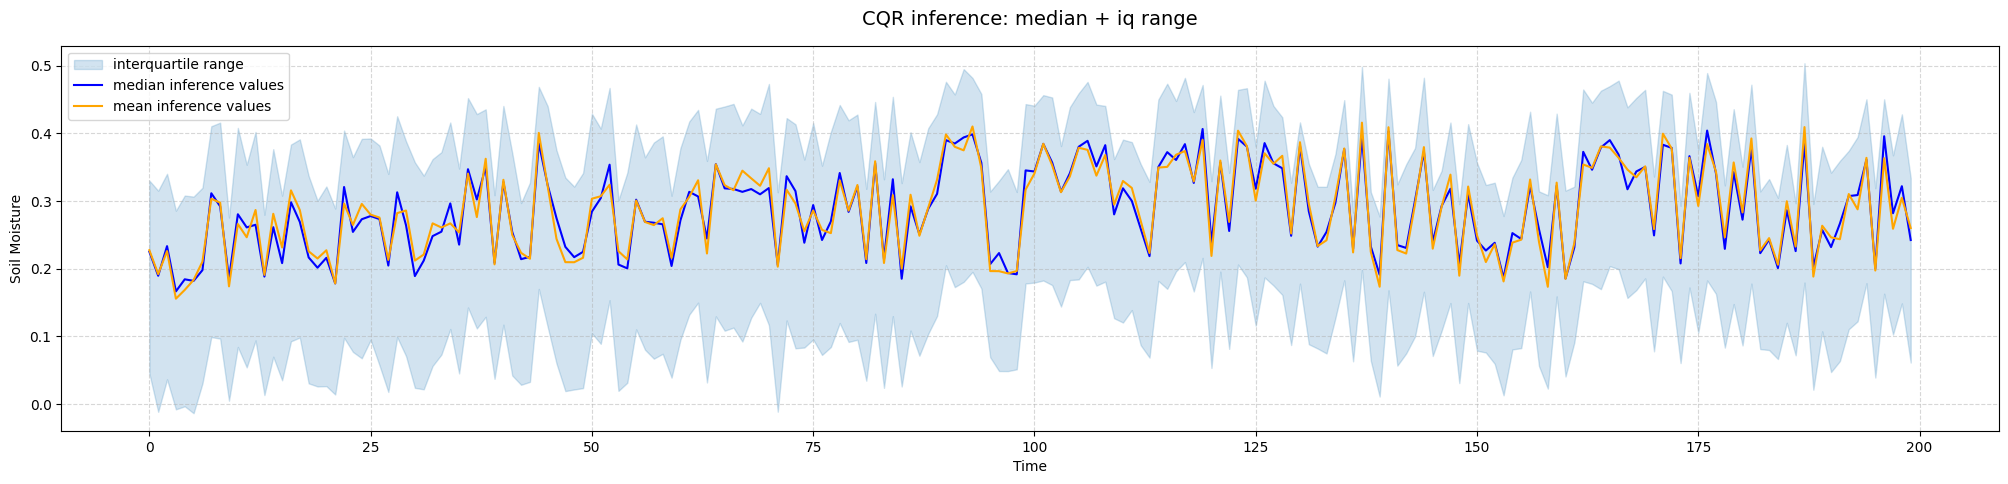

In [94]:
import matplotlib.pyplot as plt

def cqr_data_plot(means: np.ndarray, medians: np.ndarray, quartiles: np.ndarray, datetime_list: list[datetime]) -> plt.Axes:

  x = np.arange(len(medians))
  # x = datetime_list
  y_lower = quartiles[:, 0].squeeze()
  y_upper = quartiles[:, 1].squeeze()

  fig, ax = plt.subplots(1,1, figsize=(25, 5))

  shaded_error = ax.fill_between(
    x, y_lower, y_upper, color="tab:blue", alpha=0.2, label="interquartile range"
  )
  median_lineplot = ax.plot(x, medians, color="blue", alpha=1, label="median inference values")
  mean_lineplot = ax.plot(x, means, color="orange", alpha=1, label="mean inference values")
  ax.legend()
  ax.set_title("CQR inference: median + iq range", fontsize=14, pad=15)
  ax.set_xlabel("Time")
  ax.set_ylabel("Soil Moisture")
  ax.grid(True, linestyle="--", alpha=0.5)
  return ax


start_obs = 1600
end_obs = 1800
cqr_data_plot(
    means=HLSL30_rootzone_y[start_obs:end_obs],
    medians=hlsl30_rly_y_median_hat[start_obs:end_obs],
    quartiles=hlsl30_rly_y_pis_cqr[start_obs:end_obs],
    datetime_list=datetime_list
  )

plt.show()


In [95]:
# these are all pred_y !!
print(sentinel1_surface_y.shape)
print(sentinel1_rootzone_y.shape)
print(sentinel2_surface_y.shape)
print(sentinel2_rootzone_y.shape)
print(HLSL30_surface_y.shape)
print(HLSL30_rootzone_y.shape)


(9812,)
(9812,)
(13996,)
(13996,)
(5506,)
(5506,)


In [96]:
sentinel1_surface_y

array([0.116470, 0.170878, 0.077616, ..., 0.289811, 0.190448, 0.229933])

In [97]:
# @title write mean model inferences to disk
raw_model_inference_path = gdrive_data_dir / "raw_model_inference_arrs"
raw_model_inference_path.mkdir(parents=True, exist_ok=True)

np.save(str(raw_model_inference_path / 'sentinel1_surface_y_CDL16_24.npy'), sentinel1_surface_y)
np.save(str(raw_model_inference_path / 'sentinel1_rootzone_y_CDL16_24.npy'), sentinel1_rootzone_y)
np.save(str(raw_model_inference_path / 'sentinel2_surface_y_CDL16_24.npy'), sentinel2_surface_y)
np.save(str(raw_model_inference_path / 'sentinel2_rootzone_y_CDL16_24.npy'), sentinel2_rootzone_y)
np.save(str(raw_model_inference_path / 'HLSL30_surface_y_CDL16_24.npy'), HLSL30_surface_y)
np.save(str(raw_model_inference_path / 'HLSL30_rootzone_y_CDL16_24.npy'), HLSL30_rootzone_y)
print(f"saved to {raw_model_inference_path}")



saved to /content/gdrive/MyDrive/HRSM/raw_model_inference_arrs


In [98]:
# @title aggregate all model inference into stacked arrays per model per layer

from typing import Callable


def agg_inference_arrays(
    satellite_layer_X_info_test_valid: np.ndarray,
    satellite_layer_model_mean: Callable[[np.ndarray], np.ndarray],
    satellite_layer_mapie_cqr: Callable[[np.ndarray], np.ndarray],
    satellite_X_pred_all: np.ndarray,
    satellite_layer_y_test_valid: np.ndarray,
) -> np.ndarray:
  """
  agg all inference for satellite model/layer
  returns np: Xid_all, Xyear_all, Xdoy_all, Xutc_all | y_hat | y_up_hat, y_median_hat, y_low_hat | y_test_valid

  if satellite_layer_X_info_test_valid is None:
  use first four columns of satellite_X_pred_all as Xid_all, Xyear_all, Xdoy_all, Xutc_all
  satellite_layer_X_info_test_valid: np.ndarray: (n, 4) Xid_all, Xyear_all, Xdoy_all, Xutc_all
  satellite_layer_model_mean: lightgbm.sklearn.LGBMRegressor,
  satellite_layer_mapie_cqr: mapie.regression.quantile_regression.ConformalizedQuantileRegressor,
  satellite_X_pred_all: np.ndarray, (all 30 features? or remaining 26?)
  satellite_layer_y_test_valid: np.ndarray

  """
  if satellite_layer_X_info_test_valid.shape[1] != 4:
      raise ValueError("satellite_layer_X_info_test_valid must be exactly 4 columns: id, year, doy, hour of day")

  #y_hat = ML1_sly_lgb_mean.predict(ML1_sly_X_pred_all) # mean
  y_hat = satellite_layer_model_mean.predict(satellite_X_pred_all) # mean

  # y_pred_cqr, y_pis_cqr = ML1_sly_mapie_cqr.predict_interval(ML1_sly_X_pred_all) # quantile
  y_pred_cqr, y_pis_cqr = satellite_layer_mapie_cqr.predict_interval(satellite_X_pred_all) # quantile

  y_up_hat = y_pis_cqr[:, 1, 0]
  y_median_hat = y_pred_cqr
  y_low_hat = y_pis_cqr[:, 0, 0]

  # ML1_sly_y_pred_all = np.column_stack((X_info_test_valid, y_hat, y_up_hat, y_median_hat, y_low_hat, y_test_valid))
  return np.column_stack((satellite_layer_X_info_test_valid, y_hat, y_up_hat, y_median_hat, y_low_hat, satellite_layer_y_test_valid))


ML1_sly_y_pred_all = agg_inference_arrays(sentinel1_surface_X_info_test_valid, ML1_sly_lgb_mean, ML1_sly_mapie_cqr, sentinel1_surface_X_all, sentinel1_surface_y_test_valid)
ML1_rly_y_pred_all = agg_inference_arrays(sentinel1_rootzone_X_info_test_valid, ML1_rly_lgb_mean, ML1_rly_mapie_cqr, sentinel1_rootzone_X_all, sentinel1_rootzone_y_test_valid)
ML2_sly_y_pred_all = agg_inference_arrays(sentinel2_surface_X_info_test_valid, ML2_sly_lgb_mean, ML2_sly_mapie_cqr, sentinel2_surface_X_all, sentinel2_surface_y_test_valid)
ML2_rly_y_pred_all = agg_inference_arrays(sentinel2_rootzone_X_info_test_valid, ML2_rly_lgb_mean, ML2_rly_mapie_cqr, sentinel2_rootzone_X_all, sentinel2_rootzone_y_test_valid)
ML3_sly_y_pred_all = agg_inference_arrays(hlsl30_surface_X_info_test_valid, ML3_sly_lgb_mean, ML3_sly_mapie_cqr, HLSL30_surface_X_all, hlsl30_surface_y_test_valid)
ML3_rly_y_pred_all = agg_inference_arrays(hlsl30_rootzone_X_info_test_valid, ML3_rly_lgb_mean, ML3_rly_mapie_cqr, HLSL30_rootzone_X_all, hlsl30_rootzone_y_test_valid)

print(ML1_sly_y_pred_all.shape)
print(ML1_rly_y_pred_all.shape)
print(ML2_sly_y_pred_all.shape)
print(ML2_rly_y_pred_all.shape)
print(ML3_sly_y_pred_all.shape)
print(ML3_rly_y_pred_all.shape)

(9812, 9)
(9812, 9)
(13996, 9)
(13996, 9)
(5506, 9)
(5506, 9)


In [99]:
# @title Post-Process predictions using ShuoHao's script

# put all model inference into same climatology with CDF matching
# calculate sd, miu
#

from scipy.stats import rankdata
import numpy as np
from datetime import datetime,timedelta
import pandas as pd
import matplotlib.pyplot as plt


def empirical_cdf(data):
    ranks = rankdata(data, method='average')  # Rank the data
    return ranks / len(data)  # Normalize by the number of points


def cdf_matching(source, target):
    sorted_target = np.sort(target)  # Target distribution sorted
    sorted_target_ranks = rankdata(sorted_target, method='average')
    sorted_target_quantiles = sorted_target_ranks / len(sorted_target)
    ranks = rankdata(source, method='average')  # Source data ranks
    percentiles = ranks / len(source)  # Percentile positions of source data
    matched_values = np.interp(percentiles, sorted_target_quantiles, sorted_target)  # Interpolation
    return matched_values


def correct_2_ML3(Sentinel_sl_arr, sentinel2_sl_arr, hls_sl_arr, Sentinel_rly_arr, sentinel2_rly_arr, hls_rly_arr):
    """
    put all model inferences into same (ML3) climatology through CDF transform

    """
    Sentinel_sl_arr_ = Sentinel_sl_arr.copy()
    sentinel2_sl_arr_ = sentinel2_sl_arr.copy()
    hls_sl_arr_ = hls_sl_arr.copy()
    Sentinel_rly_arr_ = Sentinel_rly_arr.copy()
    sentinel2_rly_arr_ = sentinel2_rly_arr.copy()
    hls_rly_arr_ = hls_rly_arr.copy()
    # Xid_all, Xyear_all, Xdoy_all, Xutc_all, y_hat, y_up_hat, y_median_hat, y_low_hat
    # surface layer
    ids = list(set(sentinel2_sl_arr_[:, 0]))
    for idd in ids:
        hls_mask = hls_sl_arr_[:, 0] == idd
        Sentinel_mask = Sentinel_sl_arr_[:, 0] == idd
        sentinel2_mask = sentinel2_sl_arr_[:, 0] == idd
        print(f'sly, {idd} numbers: {np.count_nonzero(Sentinel_mask)}, {np.count_nonzero(sentinel2_mask)}, {np.count_nonzero(hls_mask)}')

        Sentinel_sl_arr_[Sentinel_mask, 4] = cdf_matching(Sentinel_sl_arr_[Sentinel_mask, 4], sentinel2_sl_arr_[sentinel2_mask, 4])
        hls_sl_arr_[hls_mask, 4] = cdf_matching(hls_sl_arr_[hls_mask, 4], sentinel2_sl_arr_[sentinel2_mask, 4])


    # rootzone
    ids = list(set(sentinel2_rly_arr_[:, 0]))
    for idd in ids:
        hls_mask = hls_rly_arr_[:, 0] == idd
        Sentinel_mask = Sentinel_rly_arr_[:, 0] == idd
        sentinel2_mask = sentinel2_rly_arr_[:, 0] == idd
        print(f'rly, {idd} numbers: {np.count_nonzero(Sentinel_mask)}, {np.count_nonzero(sentinel2_mask)}, {np.count_nonzero(hls_mask)}')

        Sentinel_rly_arr_[Sentinel_mask, 4] = cdf_matching(Sentinel_rly_arr_[Sentinel_mask, 4],
                                                          sentinel2_rly_arr_[sentinel2_mask, 4])
        hls_rly_arr_[hls_mask, 4] = cdf_matching(hls_rly_arr_[hls_mask, 4], sentinel2_rly_arr_[sentinel2_mask, 4])

    return Sentinel_sl_arr_, sentinel2_sl_arr_, hls_sl_arr_, Sentinel_rly_arr_, sentinel2_rly_arr_, hls_rly_arr_


def calculate_sd_and_miu(ML1_sl_arr, ML2_sl_arr, ML3_sl_arr, ML1_rly_arr, ML2_rly_arr, ML3_rly_arr):
    # Xid_all, Xyear_all, Xdoy_all, Xutc_all, y_hat

    # soil moisture
    Sentinel_sl_arr = ML1_sl_arr.copy()
    temp_arr = np.zeros((Sentinel_sl_arr.shape[0], 6)) + 1
    temp_arr[:, 0:5] = Sentinel_sl_arr[:, 0:5]
    Sentinel_sl_arr = temp_arr.copy()

    sentinel2_sl_arr = ML2_sl_arr.copy()
    temp_arr = np.zeros((sentinel2_sl_arr.shape[0], 6)) + 2
    temp_arr[:, 0:5] = sentinel2_sl_arr[:, 0:5]
    sentinel2_sl_arr = temp_arr.copy()

    hls_sl_arr = ML3_sl_arr.copy()
    temp_arr = np.zeros((hls_sl_arr.shape[0], 6)) + 3
    temp_arr[:, 0:5] = hls_sl_arr[:, 0:5]
    hls_sl_arr = temp_arr.copy()

    ssm_sl_arr = np.vstack((hls_sl_arr, Sentinel_sl_arr, sentinel2_sl_arr))
    ssm_sl_arr_0 = ssm_sl_arr.copy()
    ssm_sl_arr_0[:, 3] += -1
    ssm_sl_arr_1 = ssm_sl_arr.copy()
    ssm_sl_arr_1[:, 3] += 1
    ssm_sl_arr = np.vstack((ssm_sl_arr_0, ssm_sl_arr, ssm_sl_arr_1)).copy()

    # soil moisture standard deviation
    # The ubRMSE is also referred to as the standard deviation of the error
    hls_sl_arr = ML3_sl_arr.copy()
    temp_arr = np.zeros((hls_sl_arr.shape[0], 6)) + 3
    temp_arr[:, 0:4] = hls_sl_arr[:, 0:4]
    temp_arr[:, 4] = (hls_sl_arr[:, 5] - hls_sl_arr[:, 7])/3.29
    temp_arr[temp_arr[:, 4] <= 0, 4] = 0.02  # a small value
    hls_sl_arr = temp_arr.copy()

    Sentinel_sl_arr = ML1_sl_arr.copy()
    temp_arr = np.zeros((Sentinel_sl_arr.shape[0], 6)) + 1
    temp_arr[:, 0:4] = Sentinel_sl_arr[:, 0:4]
    temp_arr[:, 4] = (Sentinel_sl_arr[:, 5] - Sentinel_sl_arr[:, 7]) / 3.29
    temp_arr[temp_arr[:, 4] <= 0, 4] = 0.02  # a small value
    Sentinel_sl_arr = temp_arr.copy()

    sentinel2_sl_arr = ML2_sl_arr.copy()
    temp_arr = np.zeros((sentinel2_sl_arr.shape[0], 6)) + 2
    temp_arr[:, 0:4] = sentinel2_sl_arr[:, 0:4]
    temp_arr[:, 4] = (sentinel2_sl_arr[:, 5] - sentinel2_sl_arr[:, 7]) / 3.29
    temp_arr[temp_arr[:, 4] <= 0, 4] = 0.02  # a small value
    sentinel2_sl_arr = temp_arr.copy()

    sd_sl_arr = np.vstack((hls_sl_arr, Sentinel_sl_arr, sentinel2_sl_arr))
    sd_sl_arr_0 = sd_sl_arr.copy()
    sd_sl_arr_0[:, 3] += -1
    sd_sl_arr_1 = sd_sl_arr.copy()
    sd_sl_arr_1[:, 3] += 1
    sd_sl_arr = np.vstack((sd_sl_arr_0, sd_sl_arr, sd_sl_arr_1)).copy()

    ids = list(set(ssm_sl_arr[:, 0]))
    temp_arr = np.zeros((len(ids), 2))
    for i in range(len(ids)):
        temp_arr[i, 0] = ids[i]
        mask = ssm_sl_arr[:, 0] == ids[i]
        temp_arr[i, 1] = np.mean(ssm_sl_arr[mask, 4])
    miu_sl_arr = temp_arr.copy()

    # rootzone
    hls_rly_arr = ML3_rly_arr.copy()
    temp_arr = np.zeros((hls_rly_arr.shape[0], 6)) + 3
    temp_arr[:, 0:5] = hls_rly_arr[:, 0:5]
    hls_rly_arr = temp_arr.copy()

    Sentinel_rly_arr = ML1_rly_arr.copy()
    temp_arr = np.zeros((Sentinel_rly_arr.shape[0], 6)) + 1
    temp_arr[:, 0:5] = Sentinel_rly_arr[:, 0:5]
    Sentinel_rly_arr = temp_arr.copy()

    sentinel2_rly_arr = ML2_rly_arr.copy()
    temp_arr = np.zeros((sentinel2_rly_arr.shape[0], 6)) + 2
    temp_arr[:, 0:5] = sentinel2_rly_arr[:, 0:5]
    sentinel2_rly_arr = temp_arr.copy()


    ssm_rly_arr = np.vstack((hls_rly_arr, Sentinel_rly_arr, sentinel2_rly_arr))
    ssm_rly_arr_0 = ssm_rly_arr.copy()
    ssm_rly_arr_0[:, 3] += -1
    ssm_rly_arr_1 = ssm_rly_arr.copy()
    ssm_rly_arr_1[:, 3] += 1
    ssm_rly_arr = np.vstack((ssm_rly_arr_0, ssm_rly_arr, ssm_rly_arr_1)).copy()

    # The ubRMSE is also referred to as the standard deviation of the error
    hls_rly_arr = ML3_rly_arr.copy()
    temp_arr = np.zeros((hls_rly_arr.shape[0], 6)) + 3
    temp_arr[:, 0:4] = hls_rly_arr[:, 0:4]
    temp_arr[:, 4] = (hls_rly_arr[:, 5] - hls_rly_arr[:, 7]) / 3.29
    temp_arr[temp_arr[:, 4] <= 0, 4] = 0.02  # a small value
    hls_rly_arr = temp_arr.copy()

    Sentinel_rly_arr = ML1_rly_arr.copy()
    temp_arr = np.zeros((Sentinel_rly_arr.shape[0], 6)) + 1
    temp_arr[:, 0:4] = Sentinel_rly_arr[:, 0:4]
    temp_arr[:, 4] = (Sentinel_rly_arr[:, 5] - Sentinel_rly_arr[:, 7]) / 3.29
    temp_arr[temp_arr[:, 4] <= 0, 4] = 0.02  # a small value
    Sentinel_rly_arr = temp_arr.copy()

    sentinel2_rly_arr = ML2_rly_arr.copy()
    temp_arr = np.zeros((sentinel2_rly_arr.shape[0], 6)) + 2
    temp_arr[:, 0:4] = sentinel2_rly_arr[:, 0:4]
    temp_arr[:, 4] = (sentinel2_rly_arr[:, 5] - sentinel2_rly_arr[:, 7]) / 3.29
    temp_arr[temp_arr[:, 4] <= 0, 4] = 0.02  # a small value
    sentinel2_rly_arr = temp_arr.copy()

    sd_rly_arr = np.vstack((hls_rly_arr, Sentinel_rly_arr, sentinel2_rly_arr))
    sd_rly_arr_0 = sd_rly_arr.copy()
    sd_rly_arr_0[:, 3] += -1
    sd_rly_arr_1 = sd_rly_arr.copy()
    sd_rly_arr_1[:, 3] += 1
    sd_rly_arr = np.vstack((sd_rly_arr_0, sd_rly_arr, sd_rly_arr_1)).copy()


    ids = list(set(ssm_rly_arr[:, 0]))
    temp_arr = np.zeros((len(ids), 2))
    for i in range(len(ids)):
        temp_arr[i, 0] = ids[i]
        mask = ssm_rly_arr[:, 0] == ids[i]
        temp_arr[i, 1] = np.mean(ssm_rly_arr[mask, 4])
    miu_rly_arr = temp_arr.copy()

    return ssm_sl_arr, ssm_rly_arr, sd_sl_arr, sd_rly_arr, miu_sl_arr, miu_rly_arr



def create_date_list(start_date_str, num, deltat, unit='d'):
    start_date = datetime.strptime(start_date_str, '%Y-%m-%d')

    date_list = []
    for i in range(num):
        date_list.append(start_date)
        if unit == 'd':
            start_date += timedelta(days=deltat)
        elif unit == 'h':
            start_date += timedelta(hours=deltat)

    return date_list


def DoY2Date(year, doy, hh=10):
    base_date = datetime(year, 1, 1, hour=hh)
    target_date = base_date + timedelta(days=(doy - 1))
    return target_date


def reorgnize_2_2d(ssm_sl_arr, ssm_rly_arr, sd_sl_arr, sd_rly_arr, miu_sl_arr, miu_rly_arr, refer_id_arr):
    ids = refer_id_arr
    len_id = len(ids)

    # ----------------------------
    start_time = datetime(2016, 1, 1, 0)
    end_time = datetime(2024, 12, 31, 23)
    num_hours = int(((end_time - start_time).total_seconds() / 3600) + 1)
    len_seq = num_hours
    time_array = [start_time + timedelta(hours=i) for i in range(num_hours)]
    df_date = pd.DataFrame({'time': time_array})
    df_date.set_index('time', inplace=True)

    # surface layer - sm
    df_ssm_sly = pd.DataFrame(ssm_sl_arr, columns=['id', 'year', 'doy', 'hour', 'sm', 'sensor'])
    df_ssm_sly = df_ssm_sly[(df_ssm_sly['hour'] >= 0) & (df_ssm_sly['hour'] <= 23)]
    df_ssm_sly['time'] = df_ssm_sly.apply(lambda row: DoY2Date(int(row['year']), int(row['doy']), int(row['hour'])), axis=1)

    ssm_sl_arr3D = np.zeros((3, len_seq, len_id))
    ssm_sl_arr3D[:] = np.nan
    sors = [1, 2, 3]
    for i in range(len(sors)):
        for j in range(len(ids)):
            sor = sors[i]
            iid = ids[j]
            df_ssm_sly_sor_id = df_ssm_sly[(df_ssm_sly['sensor']==sor)&(df_ssm_sly['id']==iid)]
            df_ssm_sly_sor_id.set_index('time', inplace=True)
            df_new = df_date.join(df_ssm_sly_sor_id, how='left')
            df_new = df_new.loc[~df_new.index.duplicated(keep='first')]
            ssm_sl_arr3D[i, :, j] = df_new['sm'].to_numpy()[:]



    # rootzone - sm
    df_ssm_rly = pd.DataFrame(ssm_rly_arr, columns=['id', 'year', 'doy', 'hour', 'sm', 'sensor'])
    df_ssm_rly = df_ssm_rly[(df_ssm_rly['hour'] >= 0) & (df_ssm_rly['hour'] <= 23)]
    df_ssm_rly['time'] = df_ssm_rly.apply(lambda row: DoY2Date(int(row['year']), int(row['doy']), int(row['hour'])),
                                          axis=1)

    ssm_rly_arr3D = np.zeros((3, len_seq, len_id))
    ssm_rly_arr3D[:] = np.nan
    sors = [1, 2, 3]
    for i in range(len(sors)):
        for j in range(len(ids)):
            sor = sors[i]
            iid = ids[j]

            df_ssm_rly_sor_id = df_ssm_rly[(df_ssm_rly['sensor']==sor)&(df_ssm_rly['id']==iid)]
            df_ssm_rly_sor_id.set_index('time', inplace=True)
            df_new = df_date.join(df_ssm_rly_sor_id, how='left')
            df_new = df_new.loc[~df_new.index.duplicated(keep='first')]
            ssm_rly_arr3D[i, :, j] = df_new['sm'].to_numpy()[:]



    # surface layer - SD
    df_sd_sly = pd.DataFrame(sd_sl_arr, columns=['id', 'year', 'doy', 'hour', 'sm', 'sensor'])
    df_sd_sly = df_sd_sly[(df_sd_sly['hour'] >= 0) & (df_sd_sly['hour'] <= 23)]
    df_sd_sly['time'] = df_sd_sly.apply(lambda row: DoY2Date(int(row['year']), int(row['doy']), int(row['hour'])),
                                          axis=1)

    sd_sl_arr3D = np.zeros((3, len_seq, len_id))
    sd_sl_arr3D[:] = np.nan

    fsors = [1, 2, 3]
    for i in range(len(sors)):
        for j in range(len(ids)):
            sor = sors[i]
            iid = ids[j]
            df_sd_sly_sor_id = df_sd_sly[(df_sd_sly['sensor'] == sor) & (df_sd_sly['id'] == iid)]
            df_sd_sly_sor_id.set_index('time', inplace=True)
            df_new = df_date.join(df_sd_sly_sor_id, how='left')
            df_new = df_new.loc[~df_new.index.duplicated(keep='first')]
            sd_sl_arr3D[i, :, j] = df_new['sm'].to_numpy()[:]



    # rootzone - sd
    df_sd_rly = pd.DataFrame(sd_rly_arr, columns=['id', 'year', 'doy', 'hour', 'sm', 'sensor'])
    df_sd_rly = df_sd_rly[(df_sd_rly['hour'] >= 0) & (df_sd_rly['hour'] <= 23)]
    df_sd_rly['time'] = df_sd_rly.apply(lambda row: DoY2Date(int(row['year']), int(row['doy']), int(row['hour'])),
                                          axis=1)

    sd_rly_arr3D = np.zeros((3, len_seq, len_id))
    sd_rly_arr3D[:] = np.nan
    for i in range(len(sors)):
        for j in range(len(ids)):
            sor = sors[i]
            iid = ids[j]
            df_sd_rly_sor_id = df_sd_rly[(df_sd_rly['sensor'] == sor) & (df_sd_rly['id'] == iid)]
            df_sd_rly_sor_id.set_index('time', inplace=True)
            df_new = df_date.join(df_sd_rly_sor_id, how='left')
            df_new = df_new.loc[~df_new.index.duplicated(keep='first')]
            sd_rly_arr3D[i, :, j] = df_new['sm'].to_numpy()[:]

    # ======================================

    miu_sl_arr1D = np.zeros((len(ids)))
    miu_sl_arr1D[:] = np.nan
    for j in range(len(ids)):
        iid = ids[j]
        if len(miu_sl_arr[miu_sl_arr[:, 0]==iid, 1]) == 0:
            miu_sl_arr1D[j] = np.nan
            continue
        meanvalue = miu_sl_arr[miu_sl_arr[:, 0]==iid, 1][0]
        miu_sl_arr1D[j] = meanvalue

    miu_rly_arr1D = np.zeros((len(ids)))
    miu_rly_arr1D[:] = np.nan
    for j in range(len(ids)):
        iid = ids[j]
        if len(miu_rly_arr[miu_rly_arr[:, 0] == iid, 1]) == 0:
            miu_rly_arr1D[j] = np.nan
            continue
        meanvalue = miu_rly_arr[miu_rly_arr[:, 0] == iid, 1][0]
        miu_rly_arr1D[j] = meanvalue


    ssm_sl_arr2D = np.nanmean(ssm_sl_arr3D, axis=0)
    ssm_rly_arr2D = np.nanmean(ssm_rly_arr3D, axis=0)
    sd_sl_arr2D = np.nanmean(sd_sl_arr3D, axis=0)
    sd_rly_arr2D = np.nanmean(sd_rly_arr3D, axis=0)

    return ssm_sl_arr2D, ssm_rly_arr2D, sd_sl_arr2D, sd_rly_arr2D, miu_sl_arr1D, miu_rly_arr1D



#if __name__=='__main__':



# def post_process_model_inference(
#     raw_model_inference_path: Path | str,
#     lgar_output_dir: Path | str,
#     post_processed_model_output_path: Path | str,
# ) -> None:
"""
In other script, I reorganized the ML results as follows (example):

y_hat = ML1_sly_lgb_mean.predict(ML1_sly_X_pred_all) # mean

y_pred_cqr, y_pis_cqr = ML1_sly_mapie_cqr.predict_interval(ML1_sly_X_pred_all) # quantile

y_up_hat = y_pis_cqr[:, 1, 0]
y_median_hat = y_pred_cqr
y_low_hat = y_pis_cqr[:, 0, 0]

ML1_sly_y_pred_all = np.column_stack((X_info_test_valid, y_hat, y_up_hat, y_median_hat, y_low_hat, y_test_valid))
"""
# raw_model_inference_path = Path(raw_model_inference_path)
# lgar_output_dir = Path(lgar_output_dir)

# ML1_sly_y_pred_all_arr = np.load(str(raw_model_inference_path / 'sentinel1_surface_y_CDL16_24.npy'))
# ML1_rly_y_pred_all_arr = np.load(str(raw_model_inference_path / 'sentinel1_rootzone_y_CDL16_24.npy'))
# ML2_sly_y_pred_all_arr = np.load(str(raw_model_inference_path / 'sentinel2_surface_y_CDL16_24.npy'))
# ML2_rly_y_pred_all_arr = np.load(str(raw_model_inference_path / 'sentinel2_rootzone_y_CDL16_24.npy'))
# ML3_sly_y_pred_all_arr = np.load(str(raw_model_inference_path / 'HLSL30_surface_y_CDL16_24.npy'))
# ML3_rly_y_pred_all_arr = np.load(str(raw_model_inference_path / 'HLSL30_rootzone_y_CDL16_24.npy'))

referIDArr = np.load(str(lgar_output_dir / 'referIDArr.npy'))

post_processed_model_output_path = gdrive_data_dir / "post_processed_model_output"
post_processed_model_output_path.mkdir(parents=True, exist_ok=True)


    # # @title run functions
ML1_sl_arr_corrected, ML2_sl_arr_corrected, ML3_sl_arr_corrected, \
    ML1_rly_arr_corrected, ML2_rly_arr_corrected, ML3_rly_arr_corrected = correct_2_ML3(ML1_sly_y_pred_all,
                                                                                        ML2_sly_y_pred_all,
                                                                                        ML3_sly_y_pred_all,
                                                                                        ML1_rly_y_pred_all,
                                                                                        ML2_rly_y_pred_all,
                                                                                        ML3_rly_y_pred_all)

ssm_sl_arr, ssm_rly_arr, sd_sl_arr, \
    sd_rly_arr, miu_sl_arr, miu_rly_arr = calculate_sd_and_miu(ML1_sl_arr_corrected,
                                                                ML2_sl_arr_corrected,
                                                                ML3_sl_arr_corrected,
                                                                ML1_rly_arr_corrected,
                                                                ML2_rly_arr_corrected,
                                                                ML3_rly_arr_corrected)

ssm_sl_arr2D, ssm_rly_arr2D, sd_sl_arr2D, \
    sd_rly_arr2D, miu_sl_arr1D, miu_rly_arr1D = reorgnize_2_2d(ssm_sl_arr,
                                                                ssm_rly_arr,
                                                                sd_sl_arr,
                                                                sd_rly_arr,
                                                                miu_sl_arr,
                                                                miu_rly_arr,
                                                                referIDArr)

# outPath = '../'
# np.save(f'{outPath}/ssm_sl_arr2D.npy', ssm_sl_arr2D)
# np.save(f'{outPath}/ssm_rly_arr2D.npy', ssm_rly_arr2D)
# np.save(f'{outPath}/sd_sl_arr2D.npy', sd_sl_arr2D)
# np.save(f'{outPath}/sd_rly_arr2D.npy', sd_rly_arr2D)
# np.save(f'{outPath}/miu_sl_arr1D.npy', miu_sl_arr1D)
# np.save(f'{outPath}/miu_rly_arr1D.npy', miu_rly_arr1D)
# np.save(f'{outPath}/referIDArr.npy', referIDArr)

np.save(post_processed_model_output_path / "ssm_sl_arr2D.npy", ssm_sl_arr2D)
np.save(post_processed_model_output_path / "ssm_rly_arr2D.npy", ssm_rly_arr2D)
np.save(post_processed_model_output_path / "sd_sl_arr2D.npy", sd_sl_arr2D)
np.save(post_processed_model_output_path / "sd_rly_arr2D.npy", sd_rly_arr2D)
np.save(post_processed_model_output_path / "miu_sl_arr1D.npy", miu_sl_arr1D)
np.save(post_processed_model_output_path / "miu_rly_arr1D.npy", miu_rly_arr1D)
np.save(post_processed_model_output_path / "referIDArr.npy", referIDArr)

del ssm_sl_arr, ssm_rly_arr, sd_sl_arr, sd_rly_arr, miu_sl_arr, miu_rly_arr

print('post processing complete, data saved to google drive.')


# post_processed_model_output_path = gdrive_data_dir / "post_processed_model_output"
# post_processed_model_output_path.mkdir(parents=True, exist_ok=True)
# post_process_model_inference(
#     raw_model_inference_path=raw_model_inference_path,
#     lgar_output_dir=lgar_output_dir,
#     post_processed_model_output_path=post_processed_model_output_path
# )

sly, 1.0 numbers: 143, 123, 92
sly, 2.0 numbers: 34, 104, 77
sly, 3.0 numbers: 146, 254, 51
sly, 4.0 numbers: 196, 121, 87
sly, 5.0 numbers: 125, 215, 57
sly, 7.0 numbers: 177, 117, 65
sly, 8.0 numbers: 169, 202, 28
sly, 9.0 numbers: 136, 222, 51
sly, 10.0 numbers: 134, 210, 49
sly, 11.0 numbers: 136, 105, 53
sly, 12.0 numbers: 136, 219, 42
sly, 13.0 numbers: 136, 215, 52
sly, 14.0 numbers: 169, 222, 48
sly, 15.0 numbers: 167, 218, 38
sly, 16.0 numbers: 34, 213, 70
sly, 17.0 numbers: 179, 122, 68
sly, 18.0 numbers: 180, 127, 87
sly, 19.0 numbers: 89, 216, 44
sly, 20.0 numbers: 126, 206, 38
sly, 21.0 numbers: 0, 261, 118
sly, 23.0 numbers: 0, 127, 54
sly, 24.0 numbers: 147, 245, 46
sly, 25.0 numbers: 0, 248, 96
sly, 26.0 numbers: 133, 243, 75
sly, 27.0 numbers: 135, 165, 102
sly, 28.0 numbers: 34, 218, 54
sly, 29.0 numbers: 169, 221, 92
sly, 30.0 numbers: 169, 203, 91
sly, 31.0 numbers: 169, 227, 93
sly, 32.0 numbers: 148, 250, 58
sly, 33.0 numbers: 169, 226, 102
sly, 34.0 numbers: 119,

In [114]:
# @title enable LGAR execution
import subprocess

commands = [
    [
      "chmod",
      "u+x",
      "./HRSM/LGAR/LGAR",
    ],
    [
      "chmod",
      "u+x",
      "./HRSM/LGAR/EnKF_LGAR_20_003002",
    ]
]
for command in commands:
    result = subprocess.run(command, check=True)
    print(f"Command: {' '.join(command)}")
    print(f"Return code: {result.returncode}")

Command: chmod u+x ./HRSM/LGAR/LGAR
Return code: 0
Command: chmod u+x ./HRSM/LGAR/EnKF_LGAR_20_003002
Return code: 0


In [115]:
# @title run LGAR on the post-processed data

from scipy.stats import rankdata
import numpy as np
import concurrent.futures
from tqdm.contrib.concurrent import process_map
import os
import subprocess

import pandas as pd


max_workers = os.cpu_count()
def write_settings_to_txt(settings, filename="settings.txt"):
    with open(filename, "w") as f:
        for key, value in settings.items():
            # Convert lists to string format with brackets
            if isinstance(value, list):
                value_str = "[" + ", ".join(map(str, value)) + "]"
            else:
                value_str = str(value).lower() if isinstance(value, bool) else str(value)
            f.write(f"{key}: {value_str}\n")

settings = {
        "verbosity": "none",
        "site_ID": 11,
        "num_hours": 78912,
        "layer_thickness_cm": [5, 10, 15, 30, 40],
        "giuh_ordinates": [0.06, 0.51, 0.28, 0.12, 0.03],
        "layer_soil_type":[1,2,3,4,5],
        "timestep_h": 1,
        "endtime_s": 3600 * 78912,
        "field_capacity_psi": 340.9,
        "wilting_point_psi": 15495.0,
        "initial_psi": 2000.0,
        "initial_sm_perturb": 0,
        "TO_enabled": False,
        "adaptive_timestep": False,
        "free_drainage_enabled": False,
        "use_closed_form_G": False,
        "root_zone_depth_cm": 60,
        "mbal_tol": 80.0,
        "ponded_depth_max_cm": 0,
        "forcing_resolution_h": 1,
        "max_valid_soil_types": 12
    }


# referIDArr = np.load(str(lgar_output_dir / 'referIDArr.npy'))
# post_processed_model_output_path = gdrive_data_dir / "post_processed_model_output"
# post_processed_model_output_path.mkdir(parents=True, exist_ok=True)

ssm_sl_arr2D = np.load(post_processed_model_output_path / 'ssm_sl_arr2D.npy')
print(f"{ssm_sl_arr2D.shape=}")
ssm_rly_arr2D = np.load(post_processed_model_output_path / 'ssm_rly_arr2D.npy')
print(f"{ssm_rly_arr2D.shape=}")
sd_sl_arr2D = np.load(post_processed_model_output_path / 'sd_sl_arr2D.npy')
print(f"{sd_sl_arr2D.shape=}")
sd_rly_arr2D = np.load(post_processed_model_output_path / 'sd_rly_arr2D.npy')
print(f"{sd_rly_arr2D.shape=}")
soilid_arr = np.load(post_processed_model_output_path / 'soilid_arr.npy')
print(f"{soilid_arr.shape=}")
referIDArr = np.load(post_processed_model_output_path / 'referIDArr.npy')
print(f"{referIDArr.shape=}")


PET_arr = np.load(lgar_output_dir / 'PET_arr.npy')
print(PET_arr.shape)
Prec_arr = np.load(lgar_output_dir / 'Prec_arr.npy')
print(Prec_arr.shape)


lgar_processing_dir = Path("./lgar_local_processing")
lgar_processing_dir.mkdir(parents=True, exist_ok=True)


def parallel_processing(siteIndex):
    siteId = referIDArr[siteIndex]
    print(f'is running site {siteId}')

    site_sm_sly = ssm_sl_arr2D[:, siteIndex].astype(np.float64)
    site_sd_sly = sd_sl_arr2D[:, siteIndex].astype(np.float64)
    site_sm_rly = ssm_rly_arr2D[:, siteIndex].astype(np.float64)
    site_sd_rly = sd_rly_arr2D[:, siteIndex].astype(np.float64)
    site_prec_sly = Prec_arr[:, siteIndex].astype(np.float64)
    site_PET_sly = PET_arr[:, siteIndex].astype(np.float64)

    site_prec_sly.tofile(lgar_processing_dir / f'site{siteId}_prec.bin')
    site_PET_sly.tofile(lgar_processing_dir / f'site{siteId}_PET.bin')

    settings["layer_soil_type"] = list(soilid_arr[:, siteIndex])
    settings["site_ID"] = siteId

    # Example usage
    write_settings_to_txt(
        settings,
        filename=lgar_processing_dir / f'site{siteId}_settingInfo.txt'
      )

    try:
        command = [
            "./HRSM/LGAR/LGAR",
            "--filename_prec", lgar_processing_dir / f'site{siteId}_prec.bin',
            "--filename_pet", lgar_processing_dir / f'site{siteId}_PET.bin',
            "--settings_path", lgar_processing_dir / f'site{siteId}_settingInfo.txt'
        ]
        subprocess.run(command, check=True)

        # cdf matching
        df = pd.read_csv(f'Original_LGAR_{siteId}.csv', header=None)
        lgar_sm_sly = df.iloc[:, 1].to_numpy()
        print(np.mean(lgar_sm_sly))
        lgar_sm_rly = df.iloc[:, 2].to_numpy()
        print(np.mean(lgar_sm_rly))

        masksly = ~np.isnan(site_sm_sly)
        site_sm_sly[masksly] = cdf_matching(site_sm_sly[masksly], lgar_sm_sly)
        maskrly = ~np.isnan(site_sm_rly)
        site_sm_rly[maskrly] = cdf_matching(site_sm_rly[maskrly], lgar_sm_rly)

        site_sm_sly.tofile(lgar_processing_dir / f'site{siteId}_sm_sly.bin')
        site_sd_sly.tofile(lgar_processing_dir / f'site{siteId}_sd_sly.bin')
        site_sm_rly.tofile(lgar_processing_dir / f'site{siteId}_sm_rly.bin')
        site_sd_rly.tofile(lgar_processing_dir / f'site{siteId}_sd_rly.bin')

        command = [
            # "./LGAR_EnKF003002",
            "./HRSM/LGAR/EnKF_LGAR_20_003002",
            "--filename_prec", lgar_processing_dir / f'site{siteId}_prec.bin',
            "--filename_pet", lgar_processing_dir / f'site{siteId}_PET.bin',
            "--filename_sm_sly", lgar_processing_dir / f'site{siteId}_sm_sly.bin',
            "--filename_sm_rly", lgar_processing_dir / f'site{siteId}_sm_rly.bin',
            "--filename_sd_sly", lgar_processing_dir / f'site{siteId}_sd_sly.bin',
            "--filename_sd_rly", lgar_processing_dir / f'site{siteId}_sd_rly.bin',
            "--settings_path", lgar_processing_dir / f'site{siteId}_settingInfo.txt'

        ]
        subprocess.run(command, check=True)
        print(f"site {siteId} finished")

    except Exception as e:
        print(f"Error processing {siteId}: {e}")


    # delete files
    files_to_delete = [
        lgar_processing_dir / f'site{siteId}_prec.bin',
        lgar_processing_dir / f'site{siteId}_PET.bin',
        lgar_processing_dir / f'site{siteId}_sm_sly.bin',
        lgar_processing_dir / f'site{siteId}_sm_rly.bin',
        lgar_processing_dir / f'site{siteId}_sd_sly.bin',
        lgar_processing_dir / f'site{siteId}_sd_rly.bin',
        lgar_processing_dir / f'site{siteId}_settingInfo.txt',
        # f'Original_LGAR_{siteId}.csv'
    ]

    for file in files_to_delete:
        try:
            os.remove(file)
            print(f"Deleted: {file}")
        except FileNotFoundError:
            print(f"File not found, skipped: {file}")
        except Exception as e:
            print(f"Error deleting {file}: {e}")



# with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
#     executor.map(parallel_processing, range(ssm_sl_arr2D.shape[1]))

results = process_map(parallel_processing, range(ssm_sl_arr2D.shape[1]))

print("All processing finished!")

ssm_sl_arr2D.shape=(78912, 79)
ssm_rly_arr2D.shape=(78912, 79)
sd_sl_arr2D.shape=(78912, 79)
sd_rly_arr2D.shape=(78912, 79)
soilid_arr.shape=(5, 79)
referIDArr.shape=(79,)
(79, 40080)
(79, 40080)
is running site 47
is running site 7
0.15001578908150845
0.15000058245894154
0.14732735733475266
0.11582717552463502
site 7 finished
File not found, skipped: site7_prec.bin
File not found, skipped: site7_PET.bin
File not found, skipped: site7_sm_sly.bin
File not found, skipped: site7_sm_rly.bin
File not found, skipped: site7_sd_sly.bin
File not found, skipped: site7_sd_rly.bin
File not found, skipped: site7_settingInfo.txt
Deleted: Original_LGAR_7.csv
is running site 45
0.15109131717609486
0.1346490624112936
site 47 finished
File not found, skipped: site47_prec.bin
File not found, skipped: site47_PET.bin
File not found, skipped: site47_sm_sly.bin
File not found, skipped: site47_sm_rly.bin
File not found, skipped: site47_sd_sly.bin
File not found, skipped: site47_sd_rly.bin
File not found, skip

In [116]:
import os

os.cpu_count()

2

In [117]:
ssm_sl_arr2D.shape

(78912, 79)

In [118]:
gdrive_data_dir

PosixPath('/content/gdrive/MyDrive/HRSM')

In [119]:
import shutil

enkf_lgar_output_dir = gdrive_data_dir / "lgar_output" / "EnKF"
enkf_lgar_output_dir.mkdir(parents=True, exist_ok=True)
original_lgar_output_dir = gdrive_data_dir / "lgar_output" / "original"
original_lgar_output_dir.mkdir(parents=True, exist_ok=True)

for enkf_csv in Path("./").glob("EnKF_LGAR*.csv"):
  shutil.copy(enkf_csv, enkf_lgar_output_dir)

for enkf_csv in Path("./").glob("Original_LGAR*.csv"):
  shutil.copy(enkf_csv, original_lgar_output_dir)

,time,forcast_sd_sly,forcast_sd_rly,analysis_sd_sly,analysis_sd_rly,forcast_sm_sly,forcast_sm_rly,analysis_sm_sly,analysis_sm_rly,ml_sd_sly,ml_sd_rly,ml_sm_sly,ml_sm_rly
0,0,0.030695,0.020870,0.030695,0.020870,0.152101,0.154153,0.152101,0.154153,NaN,NaN,NaN,NaN
1,1,0.037005,0.025284,0.037005,0.025284,0.148853,0.153385,0.148853,0.153385,NaN,NaN,NaN,NaN
2,2,0.042877,0.032724,0.042877,0.032724,0.153248,0.155601,0.153248,0.155601,NaN,NaN,NaN,NaN
3,3,0.051627,0.041440,0.051627,0.041440,0.153689,0.156877,0.153689,0.156877,NaN,NaN,NaN,NaN
4,4,0.051490,0.045614,0.051490,0.045614,0.156618,0.154529,0.156618,0.154529,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78907,78907,0.114559,0.087578,0.114559,0.087578,0.252214,0.147321,0.252214,0.147321,NaN,NaN,NaN,NaN
78908,78908,0.116362,0.086618,0.116362,0.086618,0.249994,0.149322,0.249994,0.149322,NaN,NaN,NaN,NaN
78909,78909,0.106112,0.085374,0.106112,0.085374,0.250700,0.151939,0.250700,0.151939,NaN,NaN,NaN,NaN
78910,78910,0.105727,0.085521,0.105727,0.085521,0.256203,0.156607,0.256203,0.156607,NaN,NaN,NaN,NaN


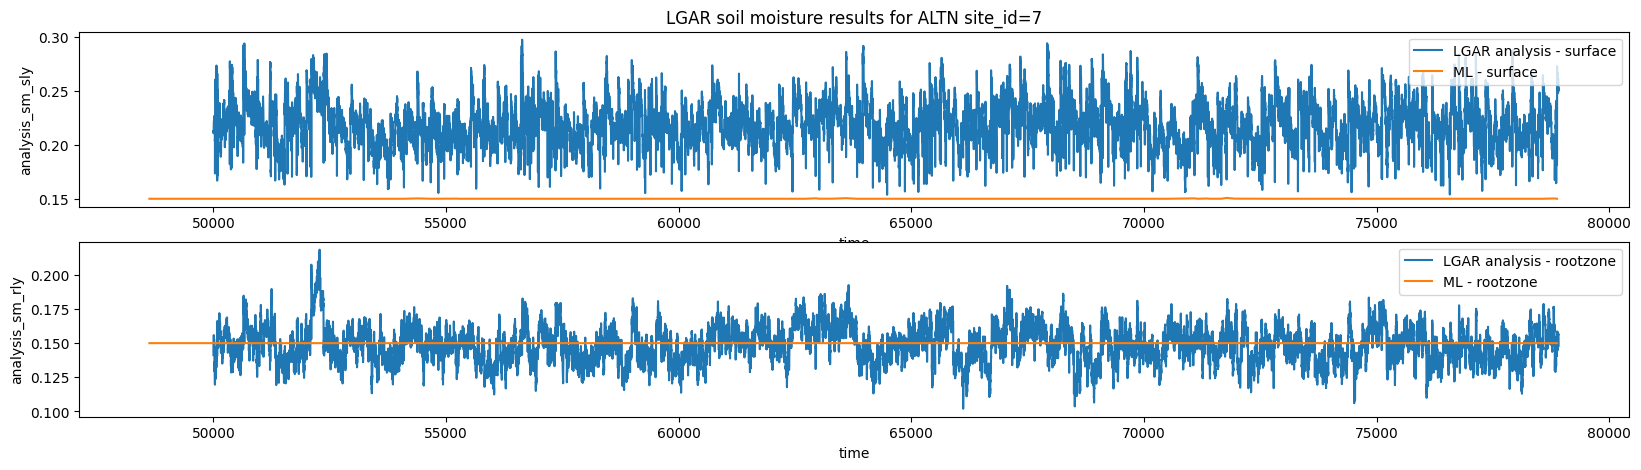

In [140]:
site_id = 7
enkf_lgar_df = pd.read_csv(enkf_lgar_output_dir / f"EnKF_LGAR_{site_id}.csv")
fig, axes = plt.subplots(2,1,figsize=(20, 5))
ax = axes[0]
ax = sns.lineplot(ax=ax, data=enkf_lgar_df[50000:], x="time", y="analysis_sm_sly", label="LGAR analysis - surface") #, "ml_sm_sly"])
ax = sns.lineplot(ax=ax, data=enkf_lgar_df, x="time", y="ml_sm_sly", label="ML - surface") #, "ml_sm_sly"])
ax = axes[1]
ax = sns.lineplot(ax=ax, data=enkf_lgar_df[50000:], x="time", y="analysis_sm_rly", label="LGAR analysis - rootzone") #, "ml_sm_sly"])
ax = sns.lineplot(ax=ax, data=enkf_lgar_df, x="time", y="ml_sm_rly", label="ML - rootzone") #, "ml_sm_sly"])
site_name = wisconet_id_to_station_code[site_id]
axes[0].set_title(f"LGAR soil moisture results for {site_name} {site_id=}")
plt.show()

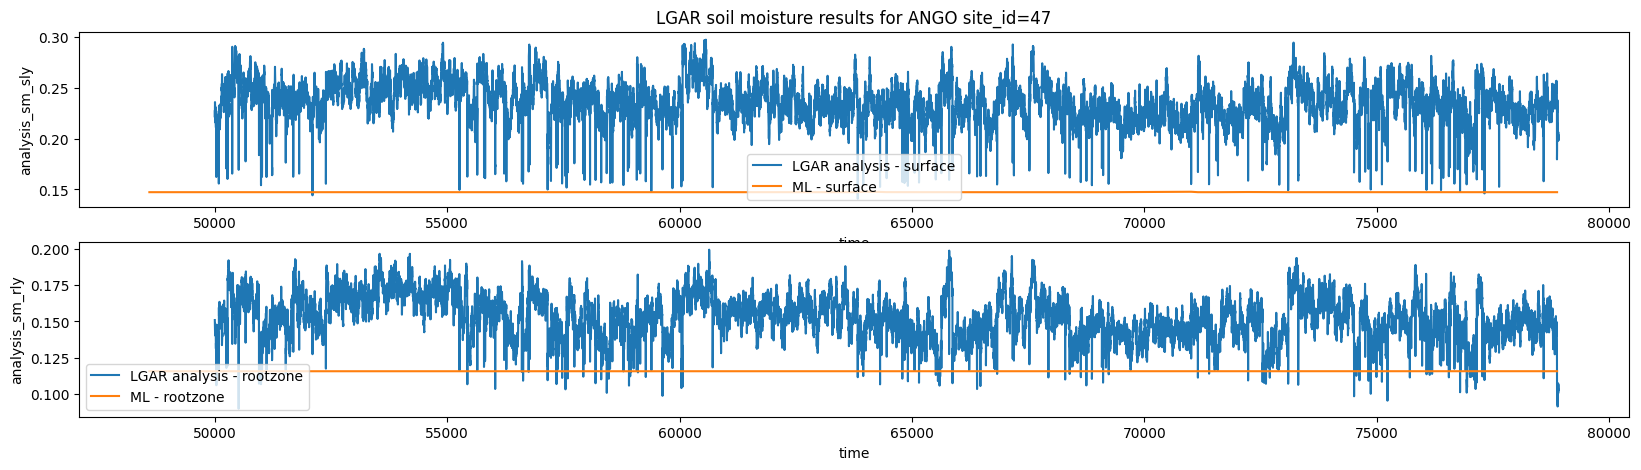

In [141]:
site_id = 47
enkf_lgar_df = pd.read_csv(enkf_lgar_output_dir / f"EnKF_LGAR_{site_id}.csv")
fig, axes = plt.subplots(2,1,figsize=(20, 5))
ax = axes[0]
ax = sns.lineplot(ax=ax, data=enkf_lgar_df[50000:], x="time", y="analysis_sm_sly", label="LGAR analysis - surface") #, "ml_sm_sly"])
ax = sns.lineplot(ax=ax, data=enkf_lgar_df, x="time", y="ml_sm_sly", label="ML - surface") #, "ml_sm_sly"])
ax = axes[1]
ax = sns.lineplot(ax=ax, data=enkf_lgar_df[50000:], x="time", y="analysis_sm_rly", label="LGAR analysis - rootzone") #, "ml_sm_sly"])
ax = sns.lineplot(ax=ax, data=enkf_lgar_df, x="time", y="ml_sm_rly", label="ML - rootzone") #, "ml_sm_sly"])
site_name = wisconet_id_to_station_code[site_id]
axes[0].set_title(f"LGAR soil moisture results for {site_name} {site_id=}")
plt.show()

## post-process predictions - Iain's



In [ ]:
import numpy as np

# Load the saved arrays
sentinel1_surface_y_CDL16_24 = np.load('sentinel1_surface_y_CDL16_24.npy')
sentinel1_rootzone_y_CDL16_24 = np.load('sentinel1_rootzone_y_CDL16_24.npy')
sentinel2_surface_y_CDL16_24 = np.load('sentinel2_surface_y_CDL16_24.npy')
sentinel2_rootzone_y_CDL16_24 = np.load('sentinel2_rootzone_y_CDL16_24.npy')
HLSL30_surface_y_CDL16_24 = np.load('HLSL30_surface_y_CDL16_24.npy')
HLSL30_rootzone_y_CDL16_24 = np.load('HLSL30_rootzone_y_CDL16_24.npy')
#
sentinel1_surface_X_all_CDL16_24 = np.load('sentinel1_surface_X_all_CDL16_24.npy')
sentinel1_rootzone_X_all_CDL16_24 = np.load('sentinel1_rootzone_X_all_CDL16_24.npy')
sentinel2_surface_X_all_CDL16_24 = np.load('sentinel2_surface_X_all_CDL16_24.npy')
sentinel2_rootzone_X_all_CDL16_24 = np.load('sentinel2_rootzone_X_all_CDL16_24.npy')
HLSL30_surface_X_all_CDL16_24 = np.load('HLSL30_surface_X_all_CDL16_24.npy')
HLSL30_rootzone_X_all_CDL16_24 = np.load('HLSL30_rootzone_X_all_CDL16_24.npy')
#
print('sentinel1_surface_y_CDL16_24.shape: ', sentinel1_surface_y_CDL16_24.shape)
print('sentinel1_rootzone_y_CDL16_24.shape: ', sentinel1_rootzone_y_CDL16_24.shape)
print('sentinel2_surface_y_CDL16_24.shape: ', sentinel2_surface_y_CDL16_24.shape)
print('sentinel2_rootzone_y_CDL16_24.shape: ', sentinel2_rootzone_y_CDL16_24.shape)
print('HLSL30_surface_y_CDL16_24.shape: ', HLSL30_surface_y_CDL16_24.shape)
print('HLSL30_rootzone_y_CDL16_24.shape: ', HLSL30_rootzone_y_CDL16_24.shape)
#
print('sentinel1_surface_X_all_CDL16_24.shape: ', sentinel1_surface_X_all_CDL16_24.shape)
print('sentinel1_rootzone_X_all_CDL16_24.shape: ', sentinel1_rootzone_X_all_CDL16_24.shape)
print('sentinel2_surface_X_all_CDL16_24.shape: ', sentinel2_surface_X_all_CDL16_24.shape)
print('sentinel2_rootzone_X_all_CDL16_24.shape: ', sentinel2_rootzone_X_all_CDL16_24.shape)
print('HLSL30_surface_X_all_CDL16_24.shape: ', HLSL30_surface_X_all_CDL16_24.shape)
print('HLSL30_rootzone_X_all_CDL16_24.shape: ', HLSL30_rootzone_X_all_CDL16_24.shape)
#

FileNotFoundError: [Errno 2] No such file or directory: 'sentinel1_surface_y_CDL16_24.npy'

In [ ]:
#@title Plot Inference Histogram
import numpy as np
import matplotlib.pyplot as plt


def plot_inference_histogram(satellite_name: str, rootzone_inference_arr: np.array, surface_inference_arr: np.array) -> plt.Axes:
  """plot histogram of two inference arrs"""
  fig, ax = plt.subplots(1, 1, figsize=(8, 5))
  rootzone_total_n = rootzone_inference_arr.shape[0]
  surface_total_n = surface_inference_arr.shape[0]
  _, bins, _ = ax.hist(surface_inference_arr, bins=30, color='skyblue', edgecolor='black', label="surface", alpha=0.6)
  ax.hist(rootzone_inference_arr, bins=bins, color='orange', edgecolor='black', label='rootzone', alpha=0.6)
  ax.set_xlabel('Soil moisture m$^{3}$/m$^{3}$', fontsize=12)
  ax.set_ylabel('Count (n)', fontsize=12)
  ax.set_title(f'Histogram of {satellite_name} inference\nsurface n={surface_total_n}, rootzone_n={rootzone_total_n}', fontsize=14)
  ax.legend()
  ax.grid(alpha=0.4)
  return ax

plot_inference_histogram(
    satellite_name = 'HLSL30',
    rootzone_inference_arr=HLSL30_rootzone_y_CDL16_24,
    surface_inference_arr=HLSL30_surface_y_CDL16_24
)
plt.show()

In [ ]:
plot_inference_histogram(
    satellite_name = 'Sentinel-1',
    rootzone_inference_arr=sentinel1_rootzone_y_CDL16_24,
    surface_inference_arr=sentinel1_surface_y_CDL16_24
)
plt.show()


In [ ]:
plot_inference_histogram(
    satellite_name = 'Sentinel-2',
    rootzone_inference_arr=sentinel2_rootzone_y_CDL16_24,
    surface_inference_arr=sentinel2_surface_y_CDL16_24
)
plt.show()


In [ ]:
#@title Re-organize to dataframe

# reorganize to 2-d array:
def get_time_index(initial_date, target_date):
    return int((target_date - initial_date).total_seconds() / 3600)

def DoY2Date(year, doy, hh=10):
    base_date = datetime(year, 1, 1, hour=hh)
    target_date = base_date + timedelta(days=(doy - 1))
    return target_date



def cdf_matching(source, target):
    sorted_target = np.sort(target)  # Target distribution sorted
    sorted_target_ranks = rankdata(sorted_target, method='average')
    sorted_target_quantiles = sorted_target_ranks / len(sorted_target)
    ranks = rankdata(source, method='average')  # Source data ranks
    percentiles = ranks / len(source)  # Percentile positions of source data
    matched_values = np.interp(percentiles, sorted_target_quantiles, sorted_target)  # Interpolation
    return matched_values



def CDF_maptching_and_reorganize_arr(ML1_sly_y_pred_all_arr, ML2_sly_y_pred_all_arr, ML3_sly_y_pred_all_arr, ML1_sly_info_arr, ML2_sly_info_arr, ML3_sly_info_arr, refer_id_arr):


    refer_id_idx_dict = {}
    for i in range(len(refer_id_arr)):
      refer_id_idx_dict[refer_id_arr[i]] = i


    ids = refer_id_arr
    len_id = len(ids)

    # num_hours = 78192
    num_hours = 40080

    ML_sly_y_pred_arr = np.zeros((4, num_hours, len_id))
    ML_sly_y_pred_arr[:] = np.nan

    # start_time = datetime(2016, 1, 1, 0)
    start_time = datetime(2021,7,6,0)  # start_date = '2021-07-16' # mine

    for i in range(len(ML1_sly_y_pred_all_arr)):
      t_idx = get_time_index(start_time, DoY2Date(int(ML1_sly_info_arr[i,  1]), int(ML1_sly_info_arr[i, 2]), int(ML1_sly_info_arr[i, 3])))
      id_idx = refer_id_idx_dict[int(ML1_sly_info_arr[i, 0])]
      ML_sly_y_pred_arr[0, t_idx, id_idx] = ML1_sly_y_pred_all_arr[i]


    for i in range(len(ML2_sly_y_pred_all_arr)):
      t_idx = get_time_index(start_time, DoY2Date(int(ML2_sly_info_arr[i,  1]), int(ML2_sly_info_arr[i, 2]), int(ML2_sly_info_arr[i, 3])))
      id_idx = refer_id_idx_dict[int(ML2_sly_info_arr[i, 0])]
      ML_sly_y_pred_arr[1, t_idx, id_idx] = ML2_sly_y_pred_all_arr[i]


    for i in range(len(ML3_sly_y_pred_all_arr)):
      t_idx = get_time_index(start_time, DoY2Date(int(ML3_sly_info_arr[i,  1]), int(ML3_sly_info_arr[i, 2]), int(ML3_sly_info_arr[i, 3])))
      id_idx = refer_id_idx_dict[int(ML3_sly_info_arr[i, 0])]
      ML_sly_y_pred_arr[2, t_idx, id_idx] = ML3_sly_y_pred_all_arr[i]


    for j in range(len_id):
      sentinel1_arr = ML_sly_y_pred_arr[0, :, j]
      sentinel2_arr = ML_sly_y_pred_arr[1, :, j]
      HLSL30_arr = ML_sly_y_pred_arr[2, :, j]

      sentinel1_nan_mask = np.isnan(sentinel1_arr)
      sentinel2_nan_mask = np.isnan(sentinel2_arr)
      HLSL30_nan_mask = np.isnan(HLSL30_arr)

      ML_sly_y_pred_arr[3, ~sentinel1_nan_mask, j] = cdf_matching(sentinel1_arr[~sentinel1_nan_mask], HLSL30_arr[~HLSL30_nan_mask])
      ML_sly_y_pred_arr[3, ~sentinel2_nan_mask, j] = cdf_matching(sentinel2_arr[~sentinel2_nan_mask], HLSL30_arr[~HLSL30_nan_mask])
      ML_sly_y_pred_arr[3, ~HLSL30_nan_mask, j] = HLSL30_arr[~HLSL30_nan_mask]


    return ML_sly_y_pred_arr





ML_sly_y_pred_arr = CDF_maptching_and_reorganize_arr(sentinel1_surface_y_CDL16_24, sentinel2_surface_y_CDL16_24, HLSL30_surface_y_CDL16_24,
                                                     sentinel1_surface_X_all_CDL16_24[:, :4], sentinel2_surface_X_all_CDL16_24[:, :4], HLSL30_surface_X_all_CDL16_24[:, :4],
                                                     referIDArr)
np.save('ML_sly_y_pred_arr_CDL16_24.npy', ML_sly_y_pred_arr)

ML_rly_y_pred_arr = CDF_maptching_and_reorganize_arr(sentinel1_rootzone_y_CDL16_24, sentinel2_rootzone_y_CDL16_24, HLSL30_rootzone_y_CDL16_24,
                                                     sentinel1_rootzone_X_all_CDL16_24[:, :4], sentinel2_rootzone_X_all_CDL16_24[:, :4], HLSL30_rootzone_X_all_CDL16_24[:, :4],
                                                     referIDArr)
np.save('ML_rly_y_pred_arr_CDL16_24.npy', ML_rly_y_pred_arr)



In [ ]:
# write final output to GDrive
np.save(gdrive_data_dir / "ML_sly_y_pred_arr_CDL16_24.npy", ML_sly_y_pred_arr)
np.save(gdrive_data_dir / "ML_rly_y_pred_arr_CDL16_24.npy", ML_rly_y_pred_arr)
print(f"Wrote 'ML_sly_y_pred_arr_CDL16_24.npy' and 'ML_rly_y_pred_arr_CDL16_24.npy' to google drive.")


In [ ]:
# first dim is satellite/model: 0: ML1, 1: ML2, 2: ML3, 3: valid mask
ML_sly_y_pred_arr.shape  # (4, 40080, 79)


# plot final CDF adjusted ML predictions

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ML_sly_y_pred_arr shape: (model/mask, time, site)
# Dim 0 index 3 is the combined valid prediction (CDF matched)

def plot_final_inferred_soil_moisture_values(
    predictions: np.ndarray,
    datetime_list: list[datetime],
    sample_sites: list[int],
    wisconet_site_id_to_site_arr_idx: dict[int, int] = wisconet_site_id_to_site_arr_idx,
    wisconet_id_to_station_code: dict[int, str] = wisconet_id_to_station_code,
    title="",
) -> plt.Axes:
  """plot final inferred soil moisture values"""
  fig, ax = plt.subplots(1, 1, figsize=(20, 8))

  for wisconet_site_id in sample_sites:
      site_idx = wisconet_site_id_to_site_arr_idx[wisconet_site_id]
      # Get valid indices for this site
      valid_mask = ~np.isnan(predictions[:, site_idx])

      if np.any(valid_mask):
          ax.plot(
              np.array(datetime_list)[valid_mask],
              predictions[valid_mask, site_idx],
              label=f'Site {wisconet_site_id}:{wisconet_id_to_station_code[wisconet_site_id]}',
              # s=10,
              # alpha=0.6
          )

  ax.set_title(title, fontsize=16)
  ax.set_xlabel('Date')
  ax.set_ylabel('Soil Moisture ($m^3/m^3$)')
  ax.legend()
  ax.grid(True, alpha=0.3)
  return ax


predictions = ML_sly_y_pred_arr[3, :, :]
sample_sites=[47, 7, 45]
plot_final_inferred_soil_moisture_values(
    predictions=predictions,
    datetime_list=datetime_list,
    sample_sites=sample_sites,
    title='ML Predicted Soil Moisture (Surface) Time Series (Valid Observations Only)',
)
plt.tight_layout()
plt.show()

In [ ]:
predictions = ML_rly_y_pred_arr[3, :, :]
# sample_sites=[47, 7, 45]
plot_final_inferred_soil_moisture_values(
    predictions=predictions,
    datetime_list=datetime_list,
    sample_sites=sample_sites,
    title='ML Predicted Soil Moisture (Rootzone) Time Series (Valid Observations Only)',
)
plt.tight_layout()
plt.show()